In [383]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [384]:
# Global parameters
total_years = 20 # this will be calculated based on study start and end dates
# Adoption model differential eq Parameters
dt = 1#/12  # time step in years (monthly)
time = np.arange(0, total_years, dt)
n = len(time)

In [385]:
#Competition group and building type specific Inputs
# New Construction

#######################
### feature request ###
#######################

# this code reads 30_Construction_Inputs.xlsx
new_construction_inputs_df = pd.read_excel('./030_input/30_Construction_Inputs.xlsx', sheet_name='New_Construction')
demolition_inputs_df = pd.read_excel('./030_input/30_Construction_Inputs.xlsx', sheet_name='Demolition')
renovation_inputs_df = pd.read_excel('./030_input/30_Construction_Inputs.xlsx', sheet_name='Renovation')

#the dataframes renovation_inputs_df demolition_inputs_df new_construction_inputs_df are structured the same with the column competition group and subgroup and the other columns being the building type
# this code will need to be modified to loop through competition groups and building types to get the correct values for each simulation

# Helper function to get the construction/demo/reno value from input dataframes
def get_construction_value(input_df, competition_group, building_type):
    """
    Get the construction/demolition/renovation value for a specific competition group and building type.
    
    Parameters:
    -----------
    input_df : pd.DataFrame
        The input dataframe (new_construction_inputs_df, demolition_inputs_df, or renovation_inputs_df)
    competition_group : str
        The competition group (e.g., 'refrigeration', 'whole_home')
    building_type : str
        The building type (e.g., 'multi_family', 'single_family', etc.)
    
    Returns:
    --------
    float
        The value per year for the specified competition group and building type
    """
    try:
        # Filter by competition group
        row = input_df[input_df['competition_group'] == competition_group]
        if row.empty:
            return 0.0
        # Get the value from the building_type column
        if building_type in row.columns:
            value = row[building_type].values[0]
            return float(value) if pd.notna(value) else 0.0
        else:
            return 0.0
    except Exception as e:
        print(f"Warning: Could not retrieve value for {competition_group}/{building_type}: {e}")
        return 0.0

In [386]:
df = pd.read_pickle("./030_input/df_yrs_all.pkl")

#######################
### feature request ###
#######################
# Create competition allocation based on PCT test for efficient measures


# Define a function to extract the size
def extract_eff_level(description):
    if 'baseline' in description:
        return 'baseline'
    elif 'existing' in description:
        return 'existing'
    elif 'efficient' in description:
        return 'efficient'
    elif 'top10' in description:
        return 'top10' #this change is made because top10 is considered efficient in refrigeration for now just holding to get number right
    else:
        return 'Unknown'

# Apply the function to the 'Description' column to create the new 'Size' column
df['efficiency_level'] = df['condition'].apply(extract_eff_level)
df

,condition,competition_group,subgroup,electric_utility,gas_utility,building_type,count,measure_life_(yrs),measure_name,sector,...,SCT_cost,SCT_benefit,SCT_BCR,RIM_cost,RIM_benefit,RIM_BCR,PCT_cost,PCT_benefit,PCT_BCR,efficiency_level
0,furnace_oil_efficient_residential,heating_cooling,oil_furnace,test_utility_1,test_utility_1,single_family,5000.0,10,furnace_oil_existing_residential_to_furnace_oi...,residential,...,1680.0,3636.660007,2.164679,1172.716654,4138.658036,3.529120,700.0,4682.630596,6.689472,efficient
1,furnace_oil_efficient_residential,heating_cooling,oil_furnace,test_utility_1,test_utility_1,single_family,5000.0,10,furnace_oil_baseline_residential_to_furnace_oi...,residential,...,1680.0,3636.660007,2.164679,1172.716654,4138.658036,3.529120,700.0,4682.630596,6.689472,efficient
2,furnace_oil_efficient_residential,heating_cooling,oil_furnace,test_utility_1,test_utility_1,single_family,5000.0,10,furnace_oil_baseline_residential_to_furnace_oi...,residential,...,1680.0,3636.660007,2.164679,1172.716654,4138.658036,3.529120,700.0,4682.630596,6.689472,efficient
3,furnace_oil_efficient_residential,heating_cooling,oil_furnace,test_utility_1,test_utility_1,single_family,5000.0,10,furnace_oil_baseline_residential_to_furnace_oi...,residential,...,1680.0,3636.660007,2.164679,1172.716654,4138.658036,3.529120,700.0,4682.630596,6.689472,efficient
4,furnace_oil_efficient_residential,heating_cooling,oil_furnace,test_utility_1,test_utility_2,single_family,10000.0,10,furnace_oil_existing_residential_to_furnace_oi...,residential,...,1680.0,3645.190210,2.169756,1172.716654,4138.658036,3.529120,700.0,4691.160799,6.701658,efficient
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,refrigerator_electricity_top10_residential,refrigeration,full_size,test_utility_1,none,multifamily_li,2100.0,10,refrigerator_electricity_top10_residential_ref...,residential,...,1800.0,4919.156168,2.732865,3250.092082,3841.311067,1.181908,750.0,6417.659055,8.556879,top10
260,refrigerator_electricity_top10_residential,refrigeration,full_size,test_utility_1,none,multifamily_li,2100.0,10,refrigerator_electricity_top10_residential_ref...,residential,...,1800.0,4919.156168,2.732865,3250.092082,3841.311067,1.181908,750.0,6417.659055,8.556879,top10
261,refrigerator_electricity_existing_residential,refrigeration,full_size,test_utility_1,test_utility_1,multifamily_li,600.0,10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,existing
262,refrigerator_electricity_existing_residential,refrigeration,full_size,test_utility_1,test_utility_2,multifamily_li,2400.0,10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,existing


In [387]:
# drop all conditions with furnace in them
df = df[~df['condition'].str.contains('furnace', na=False)]
# change name of column condition to condition_name
df.rename(columns={'condition': 'condition_name'}, inplace=True)

C:\Users\AndrewJ.Johnson\AppData\Local\Temp\ipykernel_34400\1254462694.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'condition': 'condition_name'}, inplace=True)


In [388]:
df

,condition_name,competition_group,subgroup,electric_utility,gas_utility,building_type,count,measure_life_(yrs),measure_name,sector,...,SCT_cost,SCT_benefit,SCT_BCR,RIM_cost,RIM_benefit,RIM_BCR,PCT_cost,PCT_benefit,PCT_BCR,efficiency_level
36,refrigerator_electricity_efficient_residential,refrigeration,full_size,test_utility_1,test_utility_1,single_family,15000.0,10,refrigerator_electricity_efficient_residential...,residential,...,3120.0,2969.004063,0.951604,3310.055249,2984.786640,0.901733,1300.0,5126.097795,3.943152,efficient
37,refrigerator_electricity_efficient_residential,refrigeration,full_size,test_utility_1,test_utility_1,single_family,15000.0,10,refrigerator_electricity_efficient_residential...,residential,...,1080.0,1901.386864,1.760543,1510.749803,1610.219983,1.065842,450.0,2717.225692,6.038279,efficient
38,refrigerator_electricity_efficient_residential,refrigeration,full_size,test_utility_1,test_utility_1,single_family,15000.0,10,refrigerator_electricity_efficient_residential...,residential,...,1080.0,1901.386864,1.760543,1510.749803,1610.219983,1.065842,450.0,2717.225692,6.038279,efficient
39,refrigerator_electricity_efficient_residential,refrigeration,full_size,test_utility_1,test_utility_1,single_family,15000.0,10,refrigerator_electricity_efficient_residential...,residential,...,1080.0,1901.386864,1.760543,1510.749803,1610.219983,1.065842,450.0,2717.225692,6.038279,efficient
40,refrigerator_electricity_efficient_residential,refrigeration,full_size,test_utility_1,test_utility_2,single_family,30000.0,10,refrigerator_electricity_efficient_residential...,residential,...,3120.0,2977.534266,0.954338,3310.055249,2984.786640,0.901733,1300.0,5134.627998,3.949714,efficient
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,refrigerator_electricity_top10_residential,refrigeration,full_size,test_utility_1,none,multifamily_li,2100.0,10,refrigerator_electricity_top10_residential_ref...,residential,...,1800.0,4919.156168,2.732865,3250.092082,3841.311067,1.181908,750.0,6417.659055,8.556879,top10
260,refrigerator_electricity_top10_residential,refrigeration,full_size,test_utility_1,none,multifamily_li,2100.0,10,refrigerator_electricity_top10_residential_ref...,residential,...,1800.0,4919.156168,2.732865,3250.092082,3841.311067,1.181908,750.0,6417.659055,8.556879,top10
261,refrigerator_electricity_existing_residential,refrigeration,full_size,test_utility_1,test_utility_1,multifamily_li,600.0,10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,existing
262,refrigerator_electricity_existing_residential,refrigeration,full_size,test_utility_1,test_utility_2,multifamily_li,2400.0,10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,existing


In [389]:
# we now need to update the run_adoption_model function to bring in the RET_ER Retirement rate
# This process is for the portion of the population that is total_stock minus (total_stock/EUL ) times 1/3 
# this is our ret_er portion
#   ret_er_adopted = (total_stock - (total_stock/EUL)) * (1/3) * 0.02        [2% of RET_ER population upgraded]
# that portion gets multipled by 0.02 which is the retirement rate (user defined)

# 
# #these retirement rates will come from the condition input sheet for each condition (can they be unique to each condition?)
ret_er_retirement_rate = 0.00
ret_add_on_retirement_rate = 0.00

In [390]:
#######################
### feature request ### 
#######################

def baseline_eq(Below_Baseline, Baseline, Efficient, Top10, m, retirement_rate, df_filtered=None):
    Tech_Value = 0 # this is 0 percent as that is the definition of baseline potential
    Retirement_Flow = m * retirement_rate * dt #(m is the size of the stock)
    Top10_Flow  = Retirement_Flow * Tech_Value
    Efficient_Adoption_Flow = Retirement_Flow * (Tech_Value)
    Remaining_Flow = Retirement_Flow - Efficient_Adoption_Flow - Top10_Flow
    Baseline_Adoption_Flow = Remaining_Flow # should be zero as this is technical but left in for future
    Below_Baseline_Adoption_Flow = 0.0
    
    dEfficient_dt = Efficient_Adoption_Flow - (Efficient * retirement_rate* dt)
    dBaseline_dt = Baseline_Adoption_Flow - (Baseline * retirement_rate* dt)
    dBelow_Baseline_dt = Below_Baseline_Adoption_Flow - (Below_Baseline * retirement_rate* dt)
    dTop10_dt = Top10_Flow - (Top10 * retirement_rate* dt)
    
    return dBelow_Baseline_dt, dBaseline_dt, dEfficient_dt, dTop10_dt
    # the alternative for tech is code 
    # we care about savings that are generated so when moving to measure we already have the baseline built in
    

In [391]:
def tech_eq(Below_Baseline, Baseline, Efficient, Top10, m, retirement_rate, df_filtered=None):
    Tech_Value = 1 # this is 100 percent as that is the definition of technical potential
    Retirement_Flow = m * retirement_rate * dt #(m is the size of the stock)
    Top10_Flow  = Retirement_Flow * Tech_Value
    Efficient_Adoption_Flow = Retirement_Flow * (1 - Tech_Value)
    Remaining_Flow = Retirement_Flow - Efficient_Adoption_Flow - Top10_Flow
    Baseline_Adoption_Flow = Remaining_Flow # should be zero as this is technical but left in for future
    Below_Baseline_Adoption_Flow = 0.0
    
    # section 2 here is the adopted calculated values from above minus the retirements from the data
    dEfficient_dt = Efficient_Adoption_Flow - (Efficient * retirement_rate* dt)
    dBaseline_dt = Baseline_Adoption_Flow - (Baseline * retirement_rate* dt)
    dBelow_Baseline_dt = Below_Baseline_Adoption_Flow - (Below_Baseline * retirement_rate* dt)
    dTop10_dt = Top10_Flow - (Top10 * retirement_rate* dt)
    
    return dBelow_Baseline_dt, dBaseline_dt, dEfficient_dt, dTop10_dt
    # the alternative for tech is code 
    # we care about savings that are generated so when moving to measure we already have the baseline built in

In [392]:
#######################
### feature request ###
#######################
# Have the pct dictate where things go after death
#also include the economic screening

# easiest way is to have the system be an if statement and have code for each of the different count of substocks as needed 

def competition_eq(Below_Baseline, Baseline, Efficient, Top10, m, retirement_rate, df_filtered=None):
    # Calculate Tech_Value based on PCT_BCR from top10 and efficient rows
    if df_filtered is not None and len(df_filtered) > 0:
        top10_bcr = df_filtered.loc[df_filtered['efficiency_level'] == 'top10', 'PCT_BCR'].sum()
        efficient_bcr = df_filtered.loc[df_filtered['efficiency_level'] == 'efficient', 'PCT_BCR'].sum()
        
        # Calculate Tech_Value: proportion of top10 BCR relative to total (top10 + efficient)
        total_bcr = top10_bcr + efficient_bcr
        if total_bcr > 0:
            Tech_Value = top10_bcr / total_bcr
        else:
            Tech_Value = 0.0
    else:
        Tech_Value = 0.0
    
    Retirement_Flow = m * retirement_rate * dt #(m is the size of the stock)
    Top10_Flow  = Retirement_Flow * Tech_Value
    Efficient_Adoption_Flow = Retirement_Flow * (1 - Tech_Value)
    Remaining_Flow = Retirement_Flow - Efficient_Adoption_Flow - Top10_Flow
    Baseline_Adoption_Flow = Remaining_Flow # should be zero as this is technical but left in for future
    Below_Baseline_Adoption_Flow = 0.0
    
    dEfficient_dt = Efficient_Adoption_Flow - (Efficient * retirement_rate* dt)
    dBaseline_dt = Baseline_Adoption_Flow - (Baseline * retirement_rate* dt)
    dBelow_Baseline_dt = Below_Baseline_Adoption_Flow - (Below_Baseline * retirement_rate* dt)
    dTop10_dt = Top10_Flow - (Top10 * retirement_rate* dt)
    
    return dBelow_Baseline_dt, dBaseline_dt, dEfficient_dt, dTop10_dt
    # the alternative for tech is code 
    # we care about savings that are generated so when moving to measure we already have the baseline built in

In [393]:
def run_adoption_model(adoption_function, scenario_name='baseline', store_age_distributions=False):
    """
    Run the adoption model with age-based tracking.
    
    Each equipment type is tracked by its actual age. When it reaches its EUL (measure_life_yrs),
    it goes through the adoption function to determine what replaces it.
    
    Parameters:
    -----------
    adoption_function : callable
        The function to use for adoption calculations (e.g., baseline_eq, tech_eq, competition_eq)
    scenario_name : str
        Name of the scenario for labeling results (default: 'baseline')
    store_age_distributions : bool
        If True, stores age cohort snapshots for visualization (default: False)
    
    Returns:
    --------
    pd.DataFrame
        Results dataframe with all stock calculations over time
    """

    ############## these need to be parameterized based on what is in the Provided Excel file
    competition_groups = df['competition_group'].unique().tolist()
    electric_utility = df['electric_utility'].unique().tolist()
    gas_utility = df['gas_utility'].unique().tolist()
    building_type = df['building_type'].unique().tolist()
    #subgroup = df['subgroup'].unique().tolist()  # Uncomment if subgroup is needed

    results = []
    
    # Global storage for age distributions (for visualization)
    if store_age_distributions:
        global age_distributions_storage
        age_distributions_storage = {}

    for cg in competition_groups:
        #for sg in subgroup:
            for eu in electric_utility:
                for gu in gas_utility:
                    for bt in building_type:
                        # Get dynamic nc, demo, and reno values based on competition group and building type
                        nc_per_year = get_construction_value(new_construction_inputs_df, cg, bt)
                        demo_per_year = get_construction_value(demolition_inputs_df, cg, bt)
                        reno_per_year = get_construction_value(renovation_inputs_df, cg, bt)
                        

                        
                        df_filtered = df[
                            (df['competition_group'] == cg) &
                            #df['subgroup'] == sg) &
                            (df['electric_utility'] == eu) &
                            (df['gas_utility'] == gu) &
                            (df['building_type'] == bt)
                        ]
                        # Calculate initial total stock for this filter group
                        initial_total_stock = df_filtered['count'].sum()

                        # Calculate per-timestep values as percentage of total stock
                        nc = nc_per_year * dt * initial_total_stock
                        demo = demo_per_year * dt * initial_total_stock
                        reno = reno_per_year * dt * initial_total_stock

                        if df_filtered.empty:
                            continue
                        
                        # --- AGE-BASED TRACKING INITIALIZATION ---
                        # Create age cohorts for each condition (measure)
                        # Each row in df_filtered represents a unique measure/condition
                        # We split the initial count evenly across all years of its EUL
                        
                        age_cohorts = []
                        
                        for idx, row in df_filtered.iterrows():
                            measure_eul = int(row['measure_life_(yrs)'])
                            initial_count = row['count']
                            efficiency_level = row['efficiency_level']
                            condition_name = row['condition_name']
                            
                            ######## Change here if want different split ############
                            # Split initial count evenly across all age years (0 to EUL-1)
                            count_per_age_year = initial_count / measure_eul
                            
                            # Create a cohort for each age
                            for age in range(measure_eul):
                                age_cohorts.append({
                                    'condition_name': condition_name,
                                    'efficiency_level': efficiency_level,
                                    'eul': measure_eul,
                                    'current_age': age,
                                    'count': count_per_age_year,
                                    'idx_in_df': idx  # Track original row for BCR lookup
                                })
                        
                        # Convert to DataFrame for easier manipulation
                        age_df = pd.DataFrame(age_cohorts)
                        
                        # Initialize tracking arrays for aggregated results
                        total_stock = np.zeros(n)
                        total_below_baseline_stock = np.zeros(n)
                        total_baseline_stock = np.zeros(n)
                        total_efficient_stock = np.zeros(n)
                        total_top10_stock = np.zeros(n)
                        
                        # Track flows (adoptions at EUL)
                        adoption_flow_below_baseline = np.zeros(n)
                        adoption_flow_baseline = np.zeros(n)
                        adoption_flow_efficient = np.zeros(n)
                        adoption_flow_top10 = np.zeros(n)
                        
                        # Set initial conditions for t=0
                        total_below_baseline_stock[0] = age_df[age_df['efficiency_level'] == 'existing']['count'].sum()
                        total_baseline_stock[0] = age_df[age_df['efficiency_level'] == 'baseline']['count'].sum()
                        total_efficient_stock[0] = age_df[age_df['efficiency_level'] == 'efficient']['count'].sum()
                        total_top10_stock[0] = age_df[age_df['efficiency_level'] == 'top10']['count'].sum()
                        total_stock[0] = total_below_baseline_stock[0] + total_baseline_stock[0] + total_efficient_stock[0] + total_top10_stock[0]
                        
                        # Store age distributions if requested
                        if store_age_distributions:
                            group_key = (cg, eu, gu, bt)
                            if group_key not in age_distributions_storage:
                                age_distributions_storage[group_key] = {}
                            age_distributions_storage[group_key][0] = age_df.copy()
                        
                        # --- TIME LOOP: AGE-BASED EVOLUTION ---
                        # rules for Ret_er - Only Below_baseline and Baseline will get replaced
                        # the percentage in ret_er_retirement_rate will be applied to this part of the population and only equipment that is in the oldest 1/3 of its useful life minus those that would turn over that year
                        # example if eul is 10 than equipment at age 9, 8, 7 would be eligible for early replacement (RET_ER) equipment at age 10 are 100% put in the adoption_function as shown below
                        # equipment that is baseline or below_baseline at age 9, 8, 7 are to be put in the adoption_function at the rate of ret_er_retirement_rate every dt 
                        # the count will be pulled evenly from this group of years and below_baseline baseline Split
                        # as they get replaced they are also pulled out of each of these years population counts
                        for t in range(1, n):
                            # Step 1: Age all existing cohorts by dt (1 year)
                            age_df['current_age'] = age_df['current_age'] + dt
                            
                            # Step 2: Identify cohorts that have reached or exceeded their EUL 
                            retired_cohorts = age_df[age_df['current_age'] >= age_df['eul']].copy() # for this model it is really just equal to as we dont want the last year involved
                            active_cohorts = age_df[age_df['current_age'] < age_df['eul']].copy()
                            
                            # Step 2b: Handle Early Retirement (RET_ER) - applies ret_er_retirement_rate to RET_ER eligible stock
                            # RET_ER eligible: equipment in the oldest 1/3 of useful life, excluding equipment at EUL
                            # Example: if EUL=10, eligible ages are 9, 8, 7 (equipment at age 10 goes through normal retirement)
                            # Only baseline and below_baseline (existing) equipment are eligible for RET_ER
                            ret_er_early_retirement_cohorts = pd.DataFrame()
                            
                            if ret_er_retirement_rate > 0 and not active_cohorts.empty:
                                # For each unique EUL, identify the RET_ER eligible cohorts
                                for eul in active_cohorts['eul'].unique():
                                    # Calculate the age threshold for oldest 1/3 (excluding equipment that will retire at EUL)
                                    # For EUL=10: ages 9, 8, 7 (3 years, which is the oldest 1/3 before reaching EUL)
                                    oldest_third_threshold = eul - int(np.ceil(eul / 3))
                                    
                                    # Get cohorts in the oldest 1/3 range (but not at EUL yet)
                                    # Only baseline and existing (below_baseline) are eligible
                                    eligible_cohorts = active_cohorts[
                                        (active_cohorts['eul'] == eul) &
                                        (active_cohorts['current_age'] >= oldest_third_threshold) &
                                        (active_cohorts['current_age'] < eul) &
                                        ((active_cohorts['efficiency_level'] == 'existing') | 
                                        (active_cohorts['efficiency_level'] == 'baseline'))
                                    ].copy()
                                    
                                    if not eligible_cohorts.empty:
                                        # Calculate total eligible stock
                                        total_eligible = eligible_cohorts['count'].sum()
                                        
                                        if total_eligible > 0:
                                            # Apply retirement rate to get actual early retirements
                                            ret_er_retirement_count = total_eligible * ret_er_retirement_rate * dt
                                            
                                            if ret_er_retirement_count > 0:
                                                # Calculate fraction to remove evenly from each eligible cohort # this might need to actually be proportional to the size of each cohort
                                                removal_fraction = min(ret_er_retirement_count / total_eligible, 1.0)
                                                
                                                # Track what's being removed for replacement
                                                ret_er_removed = eligible_cohorts.copy()
                                                ret_er_removed['count'] = ret_er_removed['count'] * removal_fraction
                                                ret_er_early_retirement_cohorts = pd.concat([ret_er_early_retirement_cohorts, ret_er_removed], ignore_index=True)
                                                
                                                # Remove from active cohorts
                                                for idx in eligible_cohorts.index:
                                                    active_cohorts.loc[idx, 'count'] *= (1 - removal_fraction)
                            
                            # Step 3: Combine EUL retirements and early retirements for adoption function
                            # this line is commented out but if you want to isolate the ret_ER by not having the ROB upgrades included you can uncomment it
                            #retired_cohorts['count'] = 0

                            all_retiring_cohorts = pd.concat([retired_cohorts, ret_er_early_retirement_cohorts], ignore_index=True)
                            
                            # Group all retired cohorts by efficiency level to calculate total retiring stock
                            retiring_below_baseline = all_retiring_cohorts[all_retiring_cohorts['efficiency_level'] == 'existing']['count'].sum()
                            retiring_baseline = all_retiring_cohorts[all_retiring_cohorts['efficiency_level'] == 'baseline']['count'].sum()
                            retiring_efficient = all_retiring_cohorts[all_retiring_cohorts['efficiency_level'] == 'efficient']['count'].sum()
                            retiring_top10 = all_retiring_cohorts[all_retiring_cohorts['efficiency_level'] == 'top10']['count'].sum()
                            total_retiring = retiring_below_baseline + retiring_baseline + retiring_efficient + retiring_top10
                            
                            # Apply adoption function to determine replacement distribution
                            if total_retiring > 0:
                                # Note: Using retirement_rate = 1.0 since equipment at EUL fully retires
                                dBB, dB, dE, dT = adoption_function(
                                    retiring_below_baseline,
                                    retiring_baseline,
                                    retiring_efficient,
                                    retiring_top10,
                                    total_retiring,
                                    1.0,  # Full retirement at EUL
                                    df_filtered
                                )
                                
                                # Calculate new equipment distribution after adoption
                                # The adoption function returns rates of change, so we integrate over dt
                                new_below_baseline = max(retiring_below_baseline + dBB * dt, 0.0)
                                new_baseline = max(retiring_baseline + dB * dt, 0.0)
                                new_efficient = max(retiring_efficient + dE * dt, 0.0)
                                new_top10 = max(retiring_top10 + dT * dt, 0.0)
                                
                                # Track adoption flows
                                adoption_flow_below_baseline[t] = new_below_baseline
                                adoption_flow_baseline[t] = new_baseline
                                adoption_flow_efficient[t] = new_efficient
                                adoption_flow_top10[t] = new_top10
                                
                                # Create new cohorts for each efficiency level with age = 0
                                new_cohorts = []
                                
                                # For each efficiency level, create new cohorts based on df_filtered measures
                                for eff_level, new_count in [('existing', new_below_baseline), 
                                                               ('baseline', new_baseline), 
                                                               ('efficient', new_efficient), 
                                                               ('top10', new_top10)]:
                                    if new_count > 0:
                                        # Get measures of this efficiency level from df_filtered
                                        eff_measures = df_filtered[df_filtered['efficiency_level'] == eff_level]
                                        if not eff_measures.empty:
                                            # Distribute new count proportionally to existing measures
                                            # (or evenly if no proportional data available)
                                            num_measures = len(eff_measures)
                                            count_per_measure = new_count / num_measures
                                            
                                            for idx, row in eff_measures.iterrows():
                                                new_cohorts.append({
                                                    'condition_name': row['condition_name'],
                                                    'efficiency_level': eff_level,
                                                    'eul': int(row['measure_life_(yrs)']),
                                                    'current_age': 0,
                                                    'count': count_per_measure,
                                                    'idx_in_df': idx
                                                })
                                
                                # Add new cohorts to active cohorts
                                if new_cohorts:
                                    new_cohorts_df = pd.DataFrame(new_cohorts)
                                    active_cohorts = pd.concat([active_cohorts, new_cohorts_df], ignore_index=True)
                            
                                # Step 4: Handle new construction, demolition, and renovation
                                if nc > 0:
                                    # Distribute new construction across efficiency levels based on scenario
                                    # Baseline scenario: 100% goes to baseline
                                    # Tech scenario: 100% goes to top10
                                    # Competition scenario: PCT_BCR dictates split between efficient and top10
                                    nc_cohorts = []
                                    
                                    if scenario_name == 'baseline':
                                        # 100% to baseline
                                        nc_allocation = [('baseline', 1.0)]
                                    elif scenario_name == 'tech':
                                        # 100% to top10
                                        nc_allocation = [('top10', 1.0)]
                                    elif scenario_name == 'competition':
                                        # Calculate split based on PCT_BCR
                                        top10_bcr = df_filtered.loc[df_filtered['efficiency_level'] == 'top10', 'PCT_BCR'].sum()
                                        efficient_bcr = df_filtered.loc[df_filtered['efficiency_level'] == 'efficient', 'PCT_BCR'].sum()
                                        total_bcr = top10_bcr + efficient_bcr
                                        
                                        if total_bcr > 0:
                                            top10_proportion = top10_bcr / total_bcr
                                            efficient_proportion = efficient_bcr / total_bcr
                                            nc_allocation = [('top10', top10_proportion), ('efficient', efficient_proportion)]
                                        else:
                                            # Fallback: split evenly if no BCR data
                                            nc_allocation = [('top10', 0.5), ('efficient', 0.5)]
                                    else:
                                        # Default fallback: split evenly across all levels
                                        nc_allocation = [('baseline', 1/3), ('efficient', 1/3), ('top10', 1/3)]
                                    
                                    for eff_level, proportion in nc_allocation:
                                        if proportion > 0:
                                            eff_measures = df_filtered[df_filtered['efficiency_level'] == eff_level]
                                            if not eff_measures.empty:
                                                num_measures = len(eff_measures)
                                                count_per_measure = (nc * proportion) / num_measures
                                                for idx, row in eff_measures.iterrows():
                                                    nc_cohorts.append({
                                                        'condition_name': row['condition_name'],
                                                        'efficiency_level': eff_level,
                                                        'eul': int(row['measure_life_(yrs)']),
                                                        'current_age': 0,
                                                        'count': count_per_measure,
                                                        'idx_in_df': idx
                                                    })
                                    
                                    if nc_cohorts:
                                        nc_df = pd.DataFrame(nc_cohorts)
                                        active_cohorts = pd.concat([active_cohorts, nc_df], ignore_index=True)
                            
                            # Handle demolition (remove proportionally from all cohorts)
                            # percentage of the initial counts so this value currently does not change over time
                            if demo > 0 and not active_cohorts.empty:
                                total_active = active_cohorts['count'].sum()
                                if total_active > 0:
                                    demo_fraction = min(demo / total_active, 1.0)
                                    active_cohorts['count'] = active_cohorts['count'] * (1 - demo_fraction)
                            
                            # Handle renovation (upgrade equipment based on scenario, reset age)
                            # Renovation removes a portion of existing stock and replaces it with efficient or top10 equipment depending on the scenario
                            if reno > 0 and not active_cohorts.empty:
                                total_active = active_cohorts['count'].sum()
                                if total_active > 0:
                                    reno_fraction = min(reno / total_active, 1.0)
                                    reno_count = active_cohorts['count'].sum() * reno_fraction
                                    active_cohorts['count'] = active_cohorts['count'] * (1 - reno_fraction)
                                    
                                    # Determine allocation based on scenario
                                    reno_cohorts = []
                                    
                                    if scenario_name == 'baseline':
                                        # 100% to baseline
                                        reno_allocation = [('baseline', 1.0)]
                                    elif scenario_name == 'tech':
                                        # 100% to top10
                                        reno_allocation = [('top10', 1.0)]
                                    elif scenario_name == 'competition':
                                        # Calculate split based on PCT_BCR
                                        top10_bcr = df_filtered.loc[df_filtered['efficiency_level'] == 'top10', 'PCT_BCR'].sum()
                                        efficient_bcr = df_filtered.loc[df_filtered['efficiency_level'] == 'efficient', 'PCT_BCR'].sum()
                                        total_bcr = top10_bcr + efficient_bcr
                                        
                                        if total_bcr > 0:
                                            top10_proportion = top10_bcr / total_bcr
                                            efficient_proportion = efficient_bcr / total_bcr
                                            reno_allocation = [('top10', top10_proportion), ('efficient', efficient_proportion)]
                                        else:
                                            # Fallback: split evenly if no BCR data
                                            reno_allocation = [('top10', 0.5), ('efficient', 0.5)]
                                    else:
                                        # Default fallback: all to top10
                                        reno_allocation = [('top10', 1.0)]
                                    
                                    for eff_level, proportion in reno_allocation:
                                        if proportion > 0:
                                            eff_measures = df_filtered[df_filtered['efficiency_level'] == eff_level]
                                            if not eff_measures.empty:
                                                num_measures = len(eff_measures)
                                                count_per_measure = (reno_count * proportion) / num_measures
                                                for idx, row in eff_measures.iterrows():
                                                    reno_cohorts.append({
                                                        'condition_name': row['condition_name'],
                                                        'efficiency_level': eff_level,
                                                        'eul': int(row['measure_life_(yrs)']),
                                                        'current_age': 0,
                                                        'count': count_per_measure,
                                                        'idx_in_df': idx
                                                    })
                                    
                                    if reno_cohorts:
                                        reno_df = pd.DataFrame(reno_cohorts)
                                        active_cohorts = pd.concat([active_cohorts, reno_df], ignore_index=True)
                                                        
                            # Step 5: Update age_df for next iteration
                            age_df = active_cohorts.copy()
                            
                            # Store age distribution snapshot if requested
                            if store_age_distributions:
                                group_key = (cg, eu, gu, bt)
                                age_distributions_storage[group_key][t] = age_df.copy()
                            
                            # Step 6: Calculate aggregate stocks for this timestep
                            total_below_baseline_stock[t] = age_df[age_df['efficiency_level'] == 'existing']['count'].sum()
                            total_baseline_stock[t] = age_df[age_df['efficiency_level'] == 'baseline']['count'].sum()
                            total_efficient_stock[t] = age_df[age_df['efficiency_level'] == 'efficient']['count'].sum()
                            total_top10_stock[t] = age_df[age_df['efficiency_level'] == 'top10']['count'].sum()
                            total_stock[t] = total_below_baseline_stock[t] + total_baseline_stock[t] + total_efficient_stock[t] + total_top10_stock[t]
                        
                        # Append results for each time step
                        for t in range(n):
                            results.append({
                                'competition_group': cg,
                                #'subgroup': sg,
                                'electric_utility': eu,
                                'gas_utility': gu,
                                'building_type': bt,
                                'time': t * dt,
                                'total_stock': total_stock[t],
                                'total_below_baseline_stock': total_below_baseline_stock[t],
                                'total_baseline_stock': total_baseline_stock[t],
                                'total_efficient_stock': total_efficient_stock[t],
                                'total_top10_stock': total_top10_stock[t],
                                'adoption_flow_below_baseline': adoption_flow_below_baseline[t],
                                'adoption_flow_baseline': adoption_flow_baseline[t],
                                'adoption_flow_efficient': adoption_flow_efficient[t],
                                'adoption_flow_top10': adoption_flow_top10[t]
                            })

    return pd.DataFrame(results)

In [394]:
# Run both scenarios
baseline_results_df = run_adoption_model(baseline_eq, 'baseline', store_age_distributions=False)
tech_results_df = run_adoption_model(tech_eq, 'tech', store_age_distributions=True)  # Store for plotting
competition_results_df = run_adoption_model(competition_eq, 'competition', store_age_distributions=False)



In [395]:
# Save results
tech_results_df.to_pickle("030_output/tech_adoption_results.pkl")
baseline_results_df.to_pickle("030_output/baseline_adoption_results.pkl")
competition_results_df.to_pickle("030_output/competition_adoption_results.pkl")
tech_results_df.to_pickle("040_input/tech_adoption_results.pkl")
baseline_results_df.to_pickle("040_input/baseline_adoption_results.pkl")
competition_results_df.to_pickle("040_input/competition_adoption_results.pkl")
tech_results_df.to_csv("030_output/tech_adoption_results.csv")
baseline_results_df.to_csv("030_output/baseline_adoption_results.csv")
competition_results_df.to_csv("030_output/competition_adoption_results.csv")
# Display baseline results
competition_results_df

,competition_group,electric_utility,gas_utility,building_type,time,total_stock,total_below_baseline_stock,total_baseline_stock,total_efficient_stock,total_top10_stock,adoption_flow_below_baseline,adoption_flow_baseline,adoption_flow_efficient,adoption_flow_top10
0,refrigeration,test_utility_1,test_utility_1,single_family,0,132500.0,10000.0,12500.0,60000.000000,50000.000000,0.0,0.0,0.000000,0.000000
1,refrigeration,test_utility_1,test_utility_1,single_family,1,132500.0,9000.0,11250.0,60725.598591,51524.401409,0.0,0.0,6725.598591,6524.401409
2,refrigeration,test_utility_1,test_utility_1,single_family,2,132500.0,8000.0,10000.0,61451.197183,53048.802817,0.0,0.0,6725.598591,6524.401409
3,refrigeration,test_utility_1,test_utility_1,single_family,3,132500.0,7000.0,8750.0,62176.795774,54573.204226,0.0,0.0,6725.598591,6524.401409
4,refrigeration,test_utility_1,test_utility_1,single_family,4,132500.0,6000.0,7500.0,62902.394366,56097.605634,0.0,0.0,6725.598591,6524.401409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,refrigeration,test_utility_1,none,multifamily_li,15,22260.0,0.0,0.0,11319.614518,10940.385482,0.0,0.0,1131.961452,1094.038548
236,refrigeration,test_utility_1,none,multifamily_li,16,22260.0,0.0,0.0,11319.614518,10940.385482,0.0,0.0,1131.961452,1094.038548
237,refrigeration,test_utility_1,none,multifamily_li,17,22260.0,0.0,0.0,11319.614518,10940.385482,0.0,0.0,1131.961452,1094.038548
238,refrigeration,test_utility_1,none,multifamily_li,18,22260.0,0.0,0.0,11319.614518,10940.385482,0.0,0.0,1131.961452,1094.038548


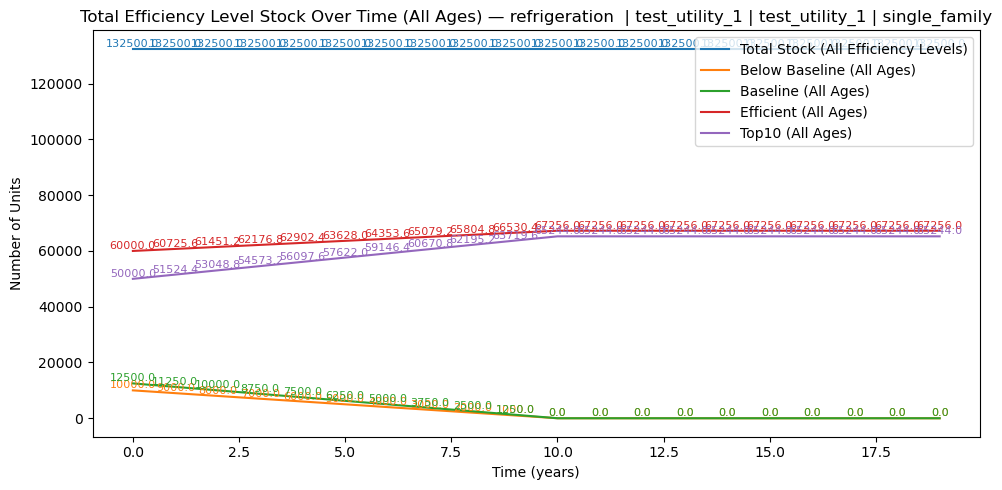

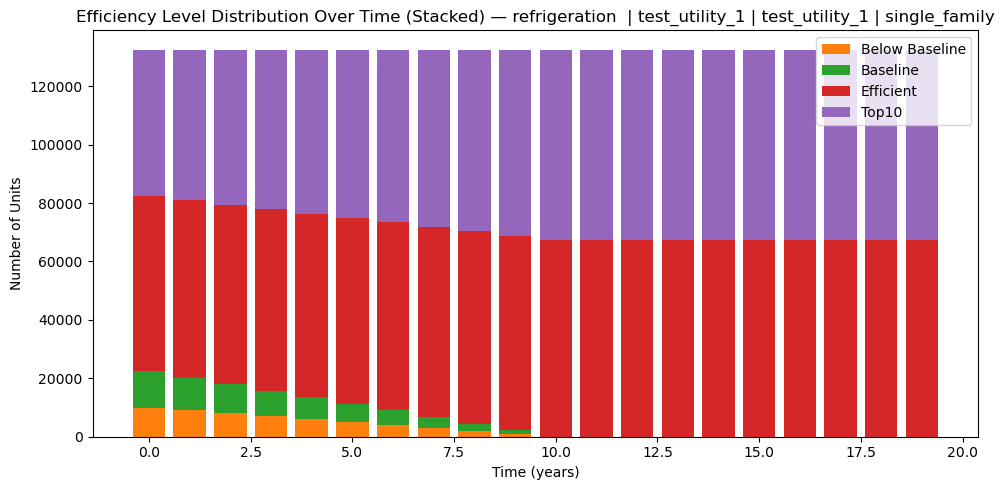

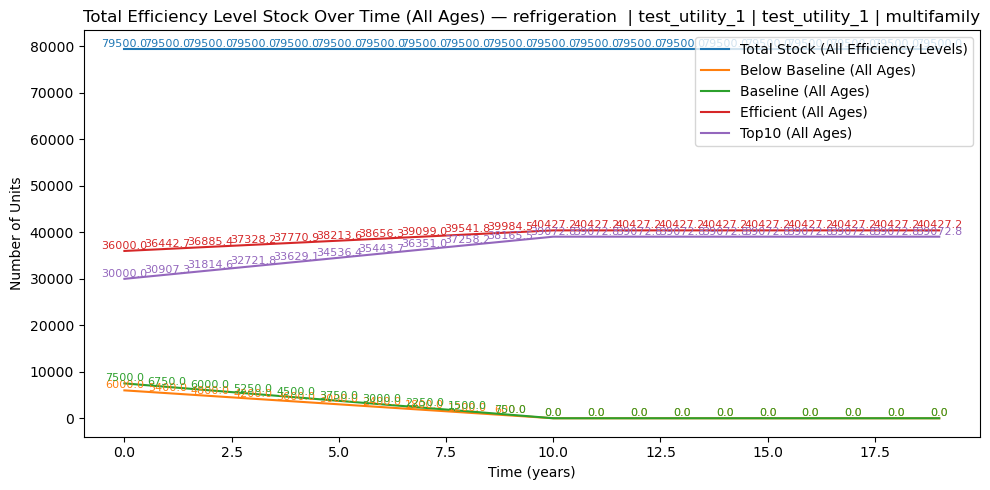

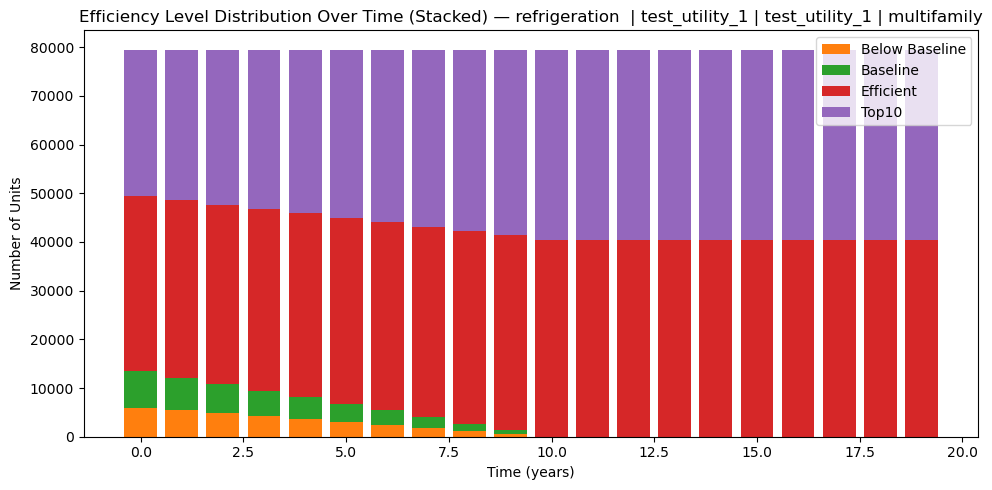

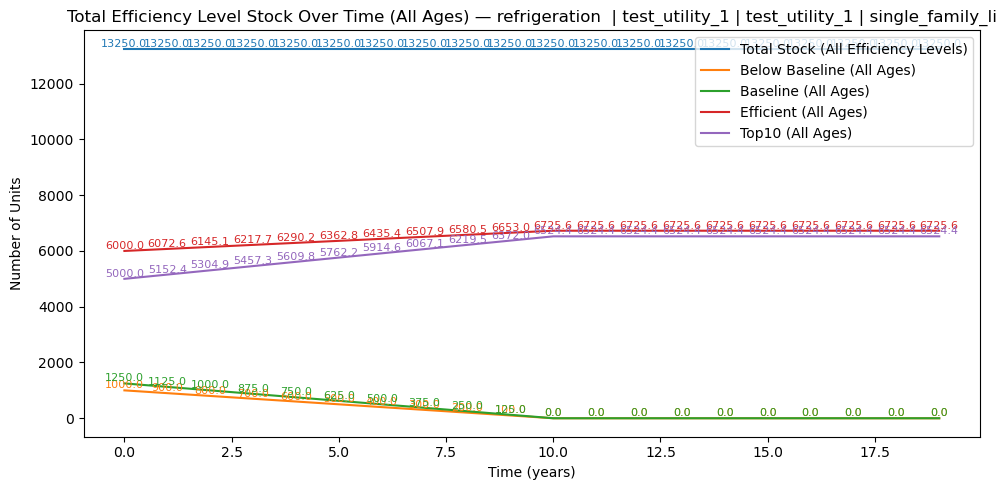

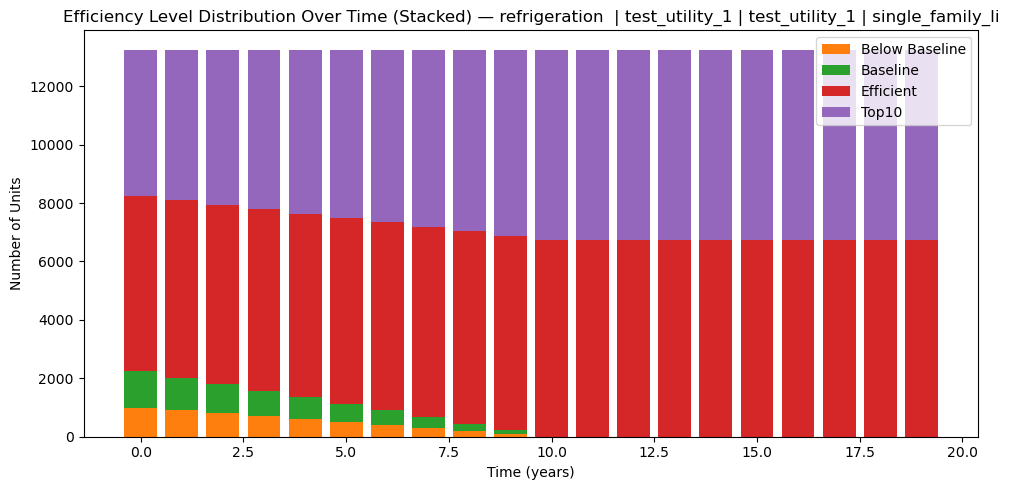

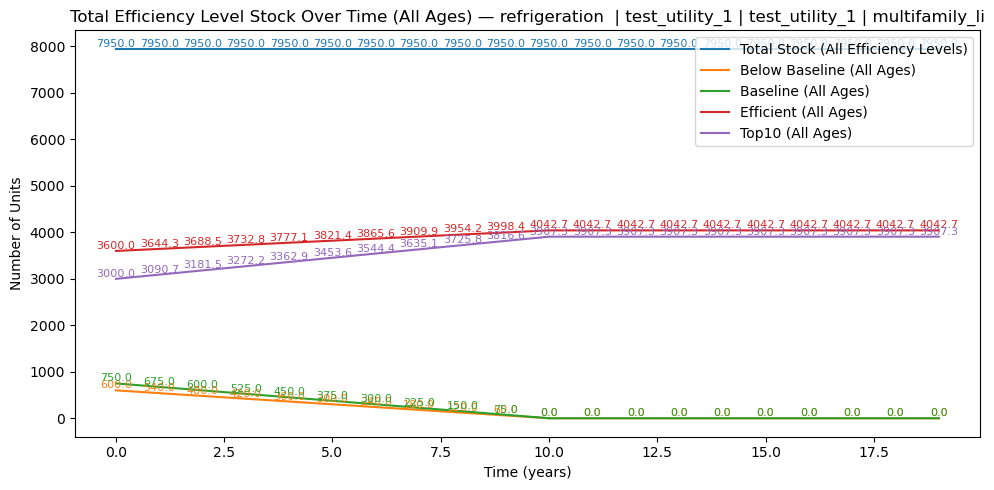

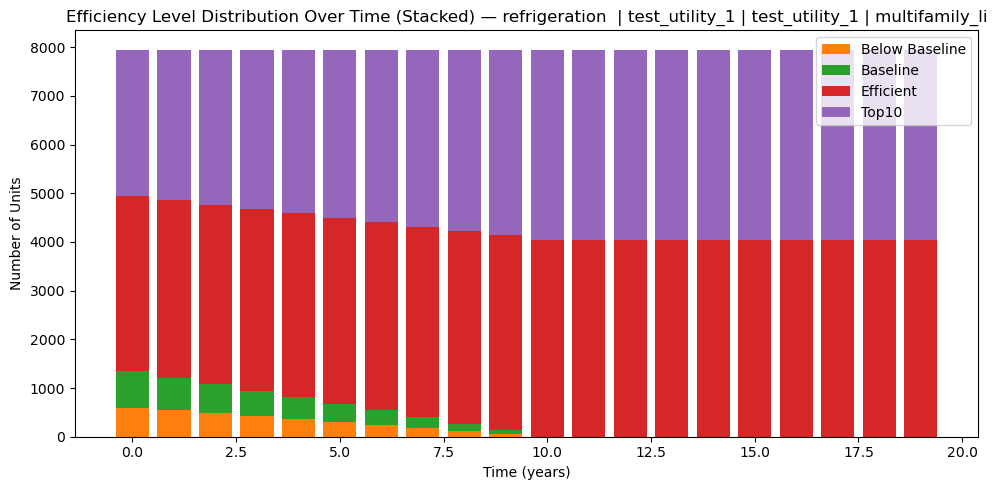

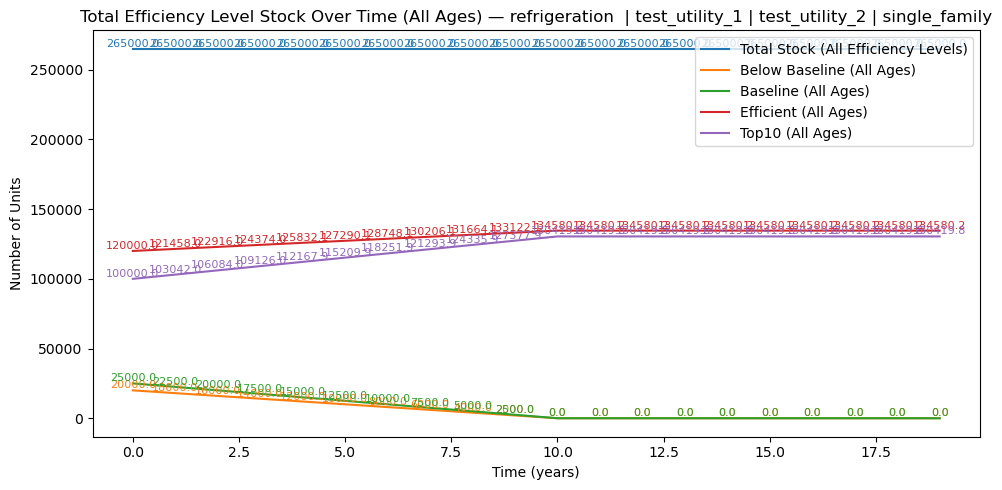

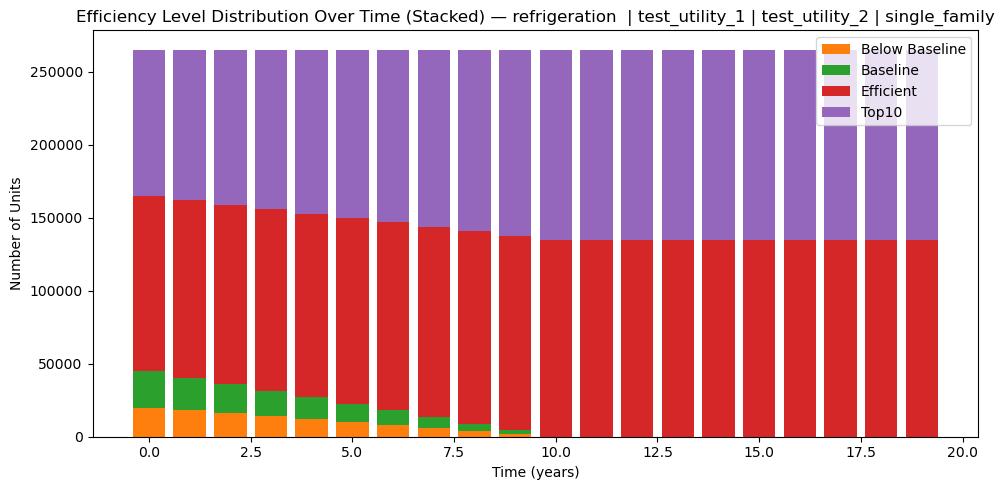

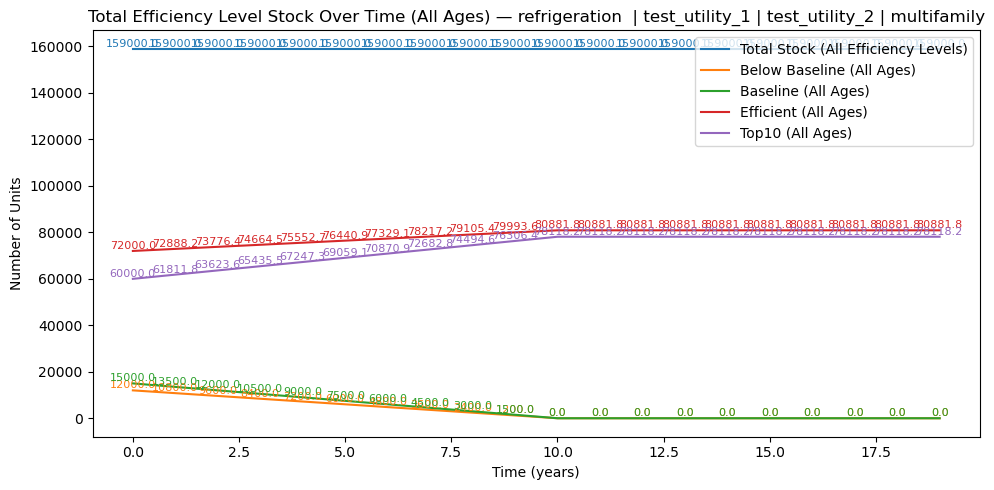

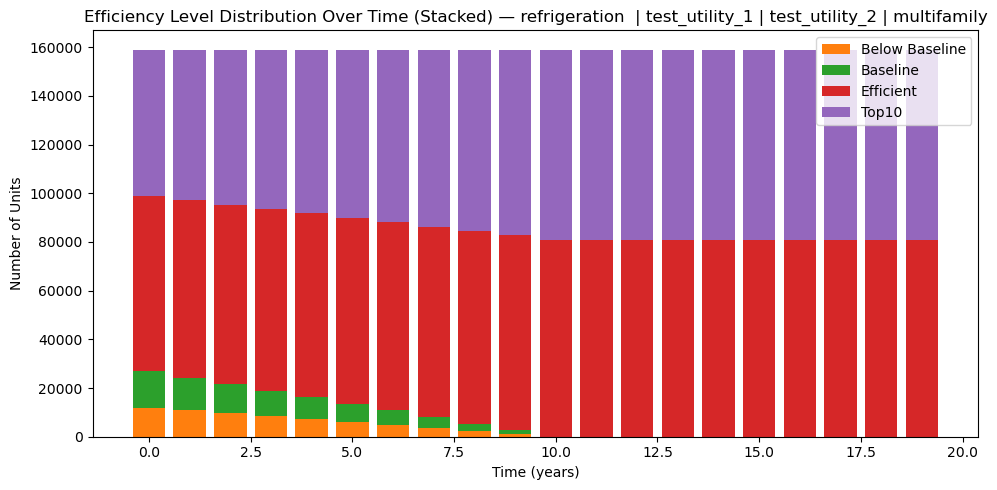

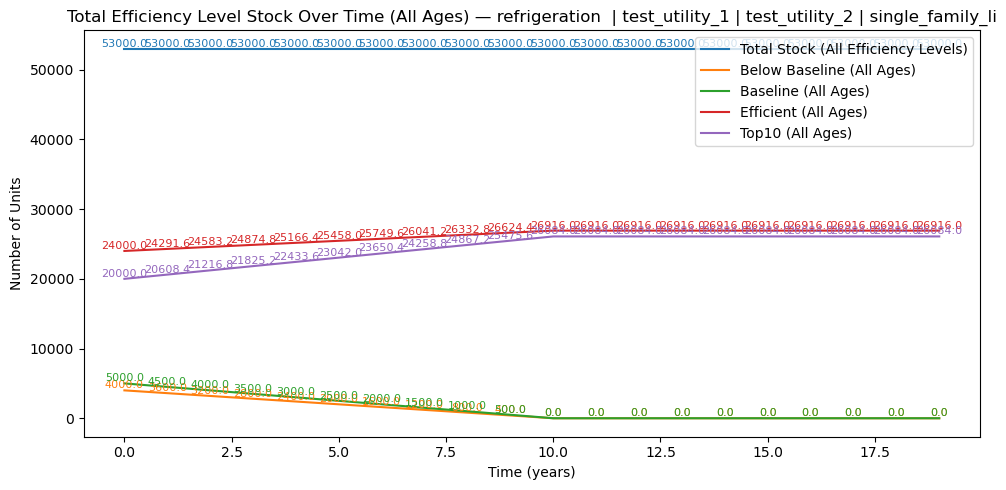

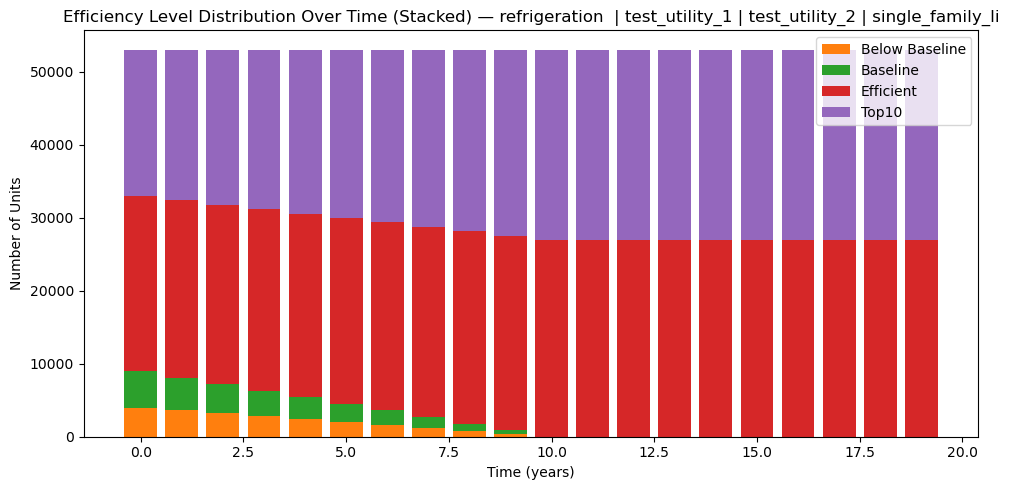

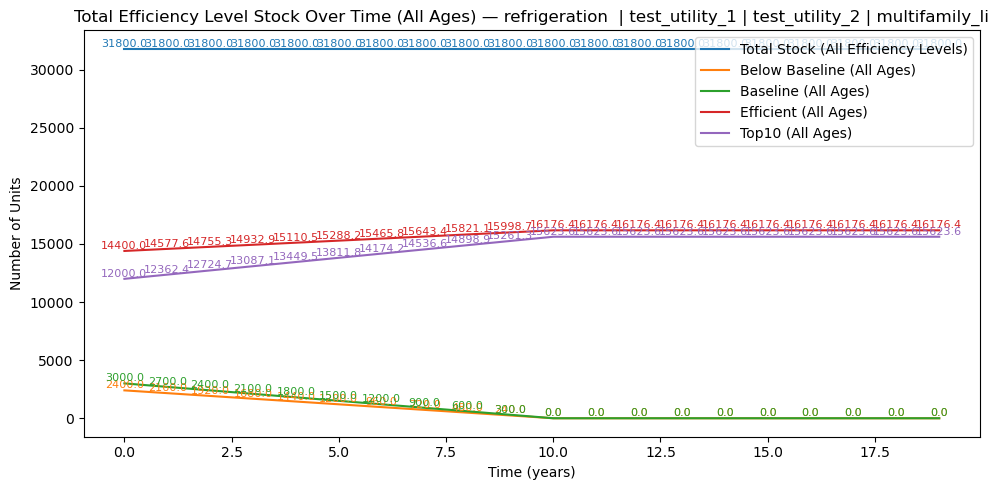

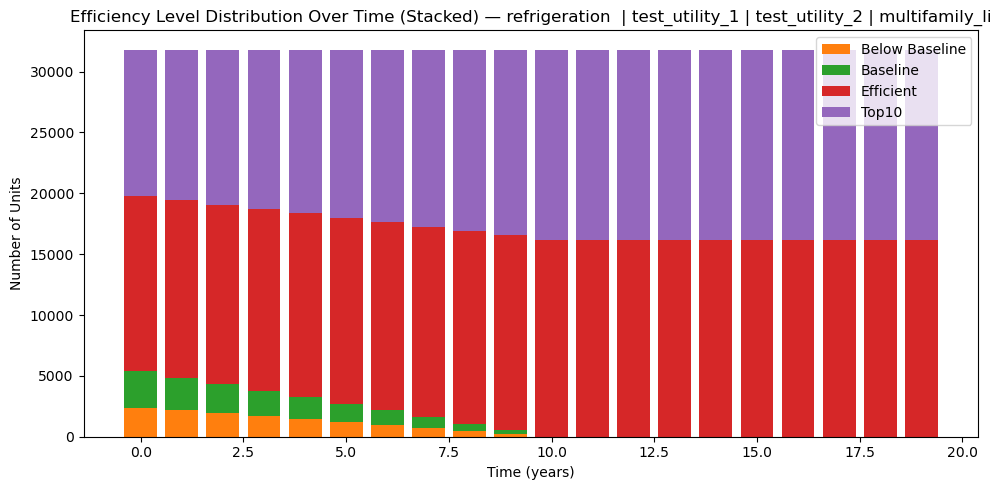

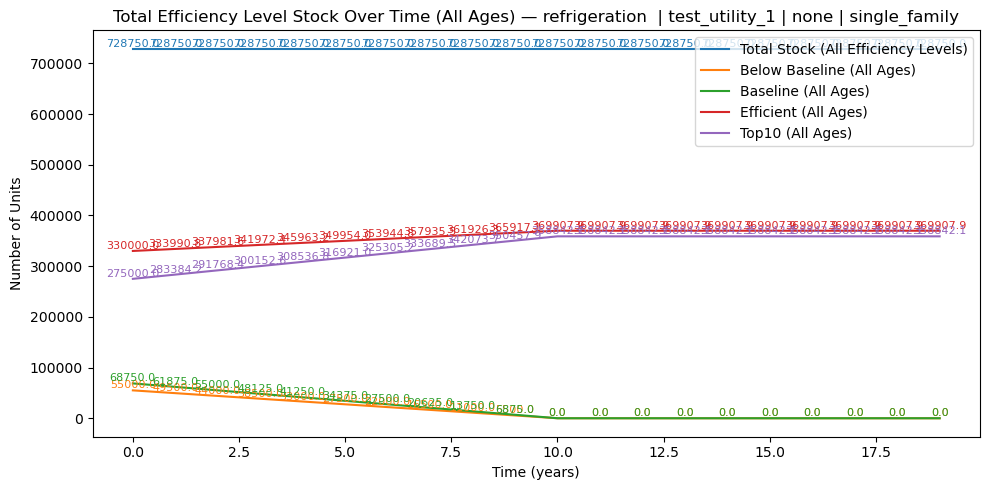

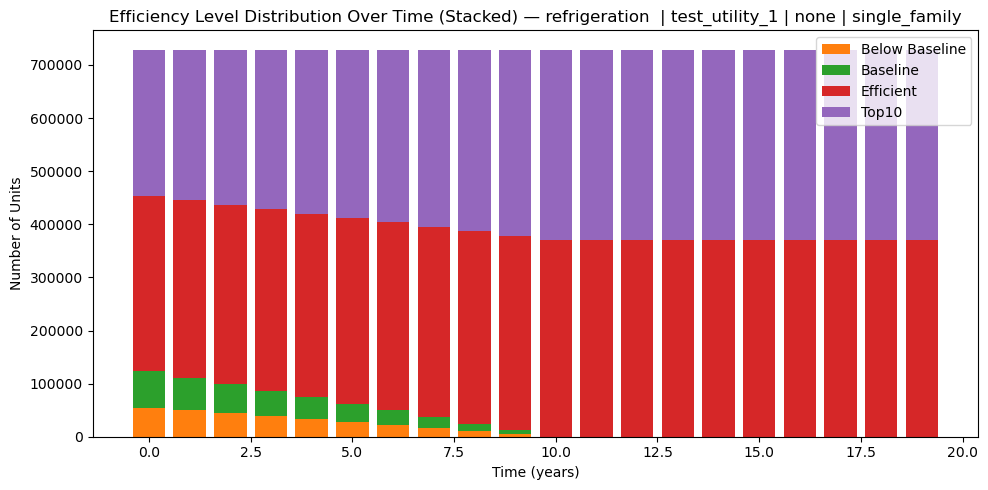

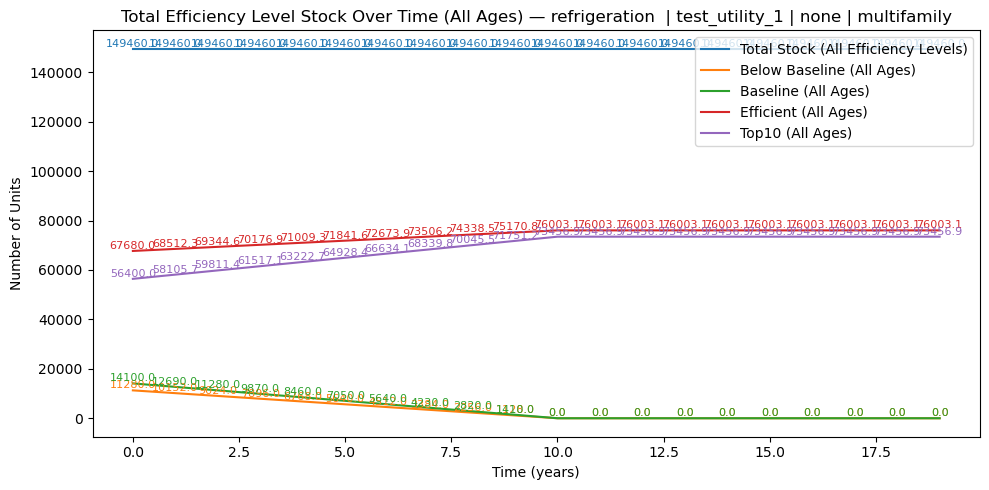

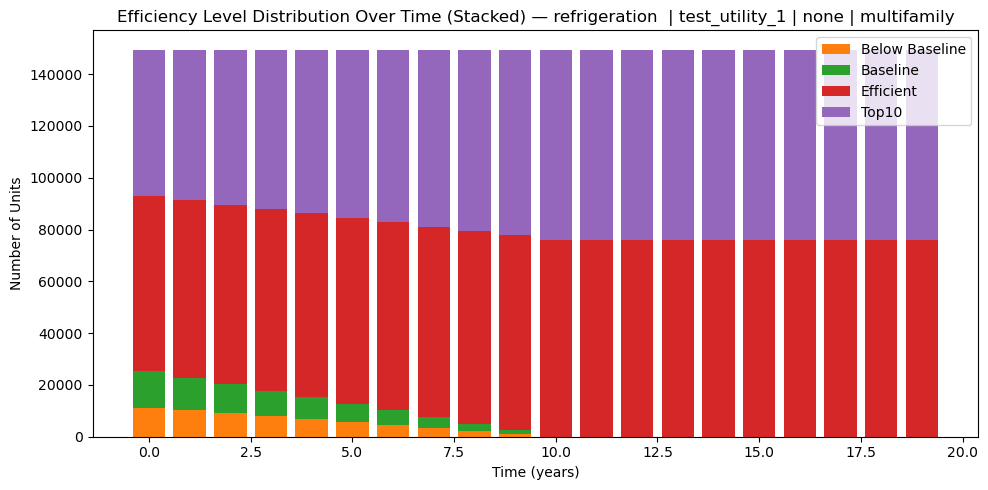

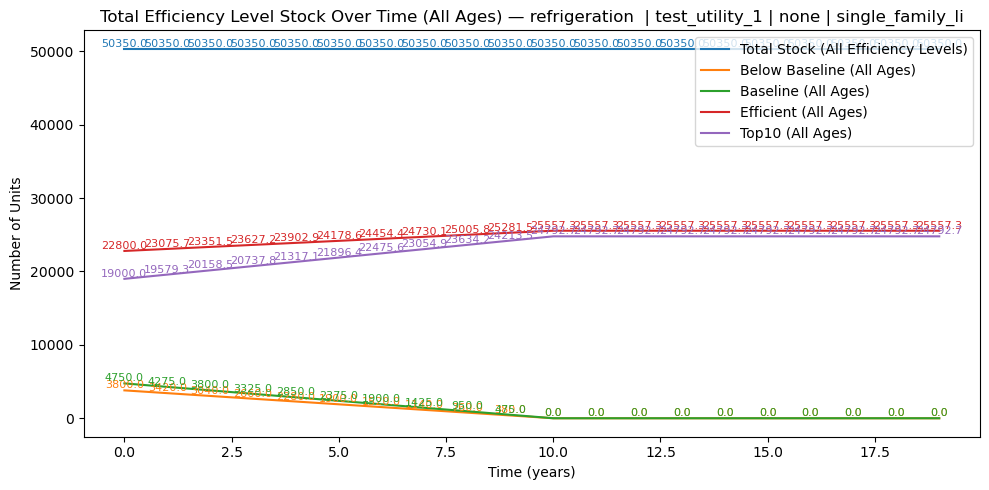

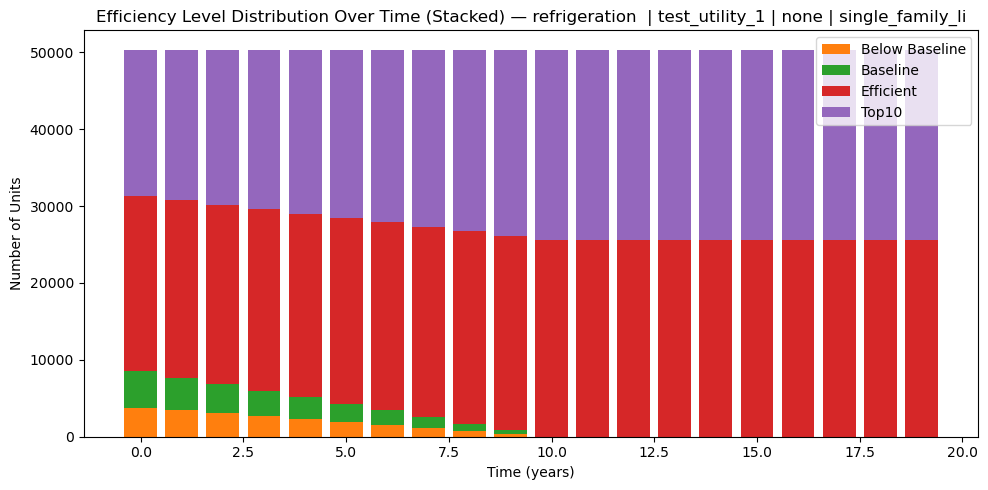

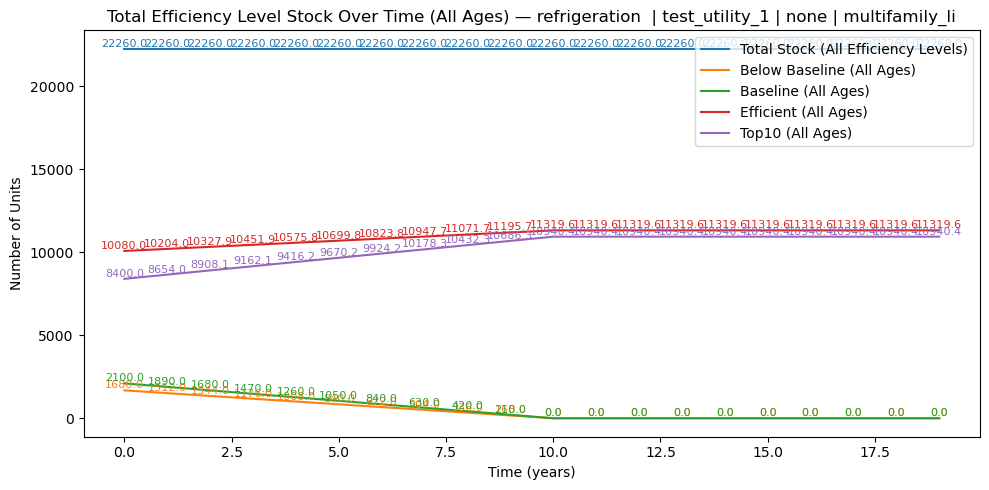

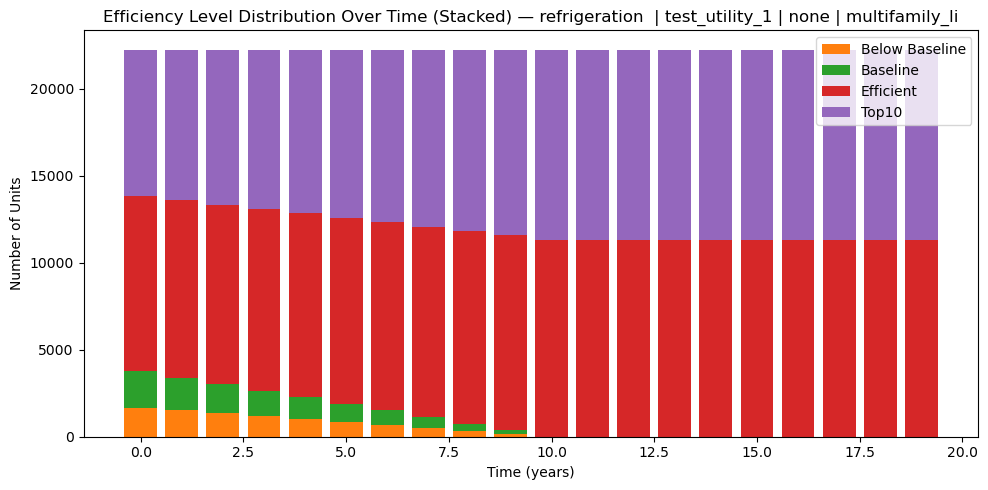

Plotted 12 group combinations.


In [396]:
# Plot results for each group combination
# import matplotlib.pyplot as plt

results_df = competition_results_df  # Change to tech_results_df to plot tech scenario

# Columns that define a group
group_cols = ['competition_group','electric_utility','gas_utility','building_type'] #'subgroup',
unique_groups = results_df[group_cols].drop_duplicates()

for _, g in unique_groups.iterrows():
    # Build mask for this group
    mask = (
        (results_df['competition_group'] == g['competition_group']) &
       # (results_df['subgroup'] == g['subgroup']) &
        (results_df['electric_utility'] == g['electric_utility']) &
        (results_df['gas_utility'] == g['gas_utility']) &
        (results_df['building_type'] == g['building_type'])
    )
    dfg = results_df[mask].sort_values('time')
    if dfg.empty:
        continue
    t = dfg['time'].values

    # Figure title suffix describing the group
    title_suffix = f"{g['competition_group']}  | {g['electric_utility']} | {g['gas_utility']} | {g['building_type']}" # | {g['subgroup']}

    # --- Plot: Total Efficiency Level breakdown (summed across all markets) ---
    plt.figure(figsize=(10, 5))
    total_below_baseline = dfg['total_below_baseline_stock'].values
    total_baseline = dfg['total_baseline_stock'].values
    total_efficient = dfg['total_efficient_stock'].values
    total_top10 = dfg['total_top10_stock'].values
    total_all_efficiency = total_below_baseline + total_baseline + total_efficient + total_top10

    plt.plot(t, total_all_efficiency, label="Total Stock (All Efficiency Levels)")
    plt.plot(t, total_below_baseline, label="Below Baseline (All Ages)")
    plt.plot(t, total_baseline, label="Baseline (All Ages)")
    plt.plot(t, total_efficient, label="Efficient (All Ages)")
    plt.plot(t, total_top10, label="Top10 (All Ages)")
    for i in range(0, len(t), 1):
        plt.text(t[i], total_all_efficiency[i], f"{total_all_efficiency[i]:.1f}", fontsize=8, ha='center', va='bottom', color='tab:blue')
        plt.text(t[i], total_below_baseline[i], f"{total_below_baseline[i]:.1f}", fontsize=8, ha='center', va='bottom', color='tab:orange')
        plt.text(t[i], total_baseline[i], f"{total_baseline[i]:.1f}", fontsize=8, ha='center', va='bottom', color='tab:green')
        plt.text(t[i], total_efficient[i], f"{total_efficient[i]:.1f}", fontsize=8, ha='center', va='bottom', color='tab:red')
        plt.text(t[i], total_top10[i], f"{total_top10[i]:.1f}", fontsize=8, ha='center', va='bottom', color='tab:purple')
    plt.xlabel("Time (years)")
    plt.ylabel("Number of Units")
    plt.title("Total Efficiency Level Stock Over Time (All Ages) — " + title_suffix)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Stacked Bar Chart: Efficiency Level Distribution Over Time ---
    plt.figure(figsize=(10, 5))
    
    # Create stacked bar chart
    bar_width = 0.8
    plt.bar(t, total_below_baseline, bar_width, label='Below Baseline', color='tab:orange')
    plt.bar(t, total_baseline, bar_width, bottom=total_below_baseline, label='Baseline', color='tab:green')
    plt.bar(t, total_efficient, bar_width, bottom=total_below_baseline + total_baseline, label='Efficient', color='tab:red')
    plt.bar(t, total_top10, bar_width, bottom=total_below_baseline + total_baseline + total_efficient, label='Top10', color='tab:purple')
    
    plt.xlabel("Time (years)")
    plt.ylabel("Number of Units")
    plt.title("Efficiency Level Distribution Over Time (Stacked) — " + title_suffix)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Done plotting all groups
print(f"Plotted {len(unique_groups)} group combinations.")

Generating age cohort visualizations from stored data...


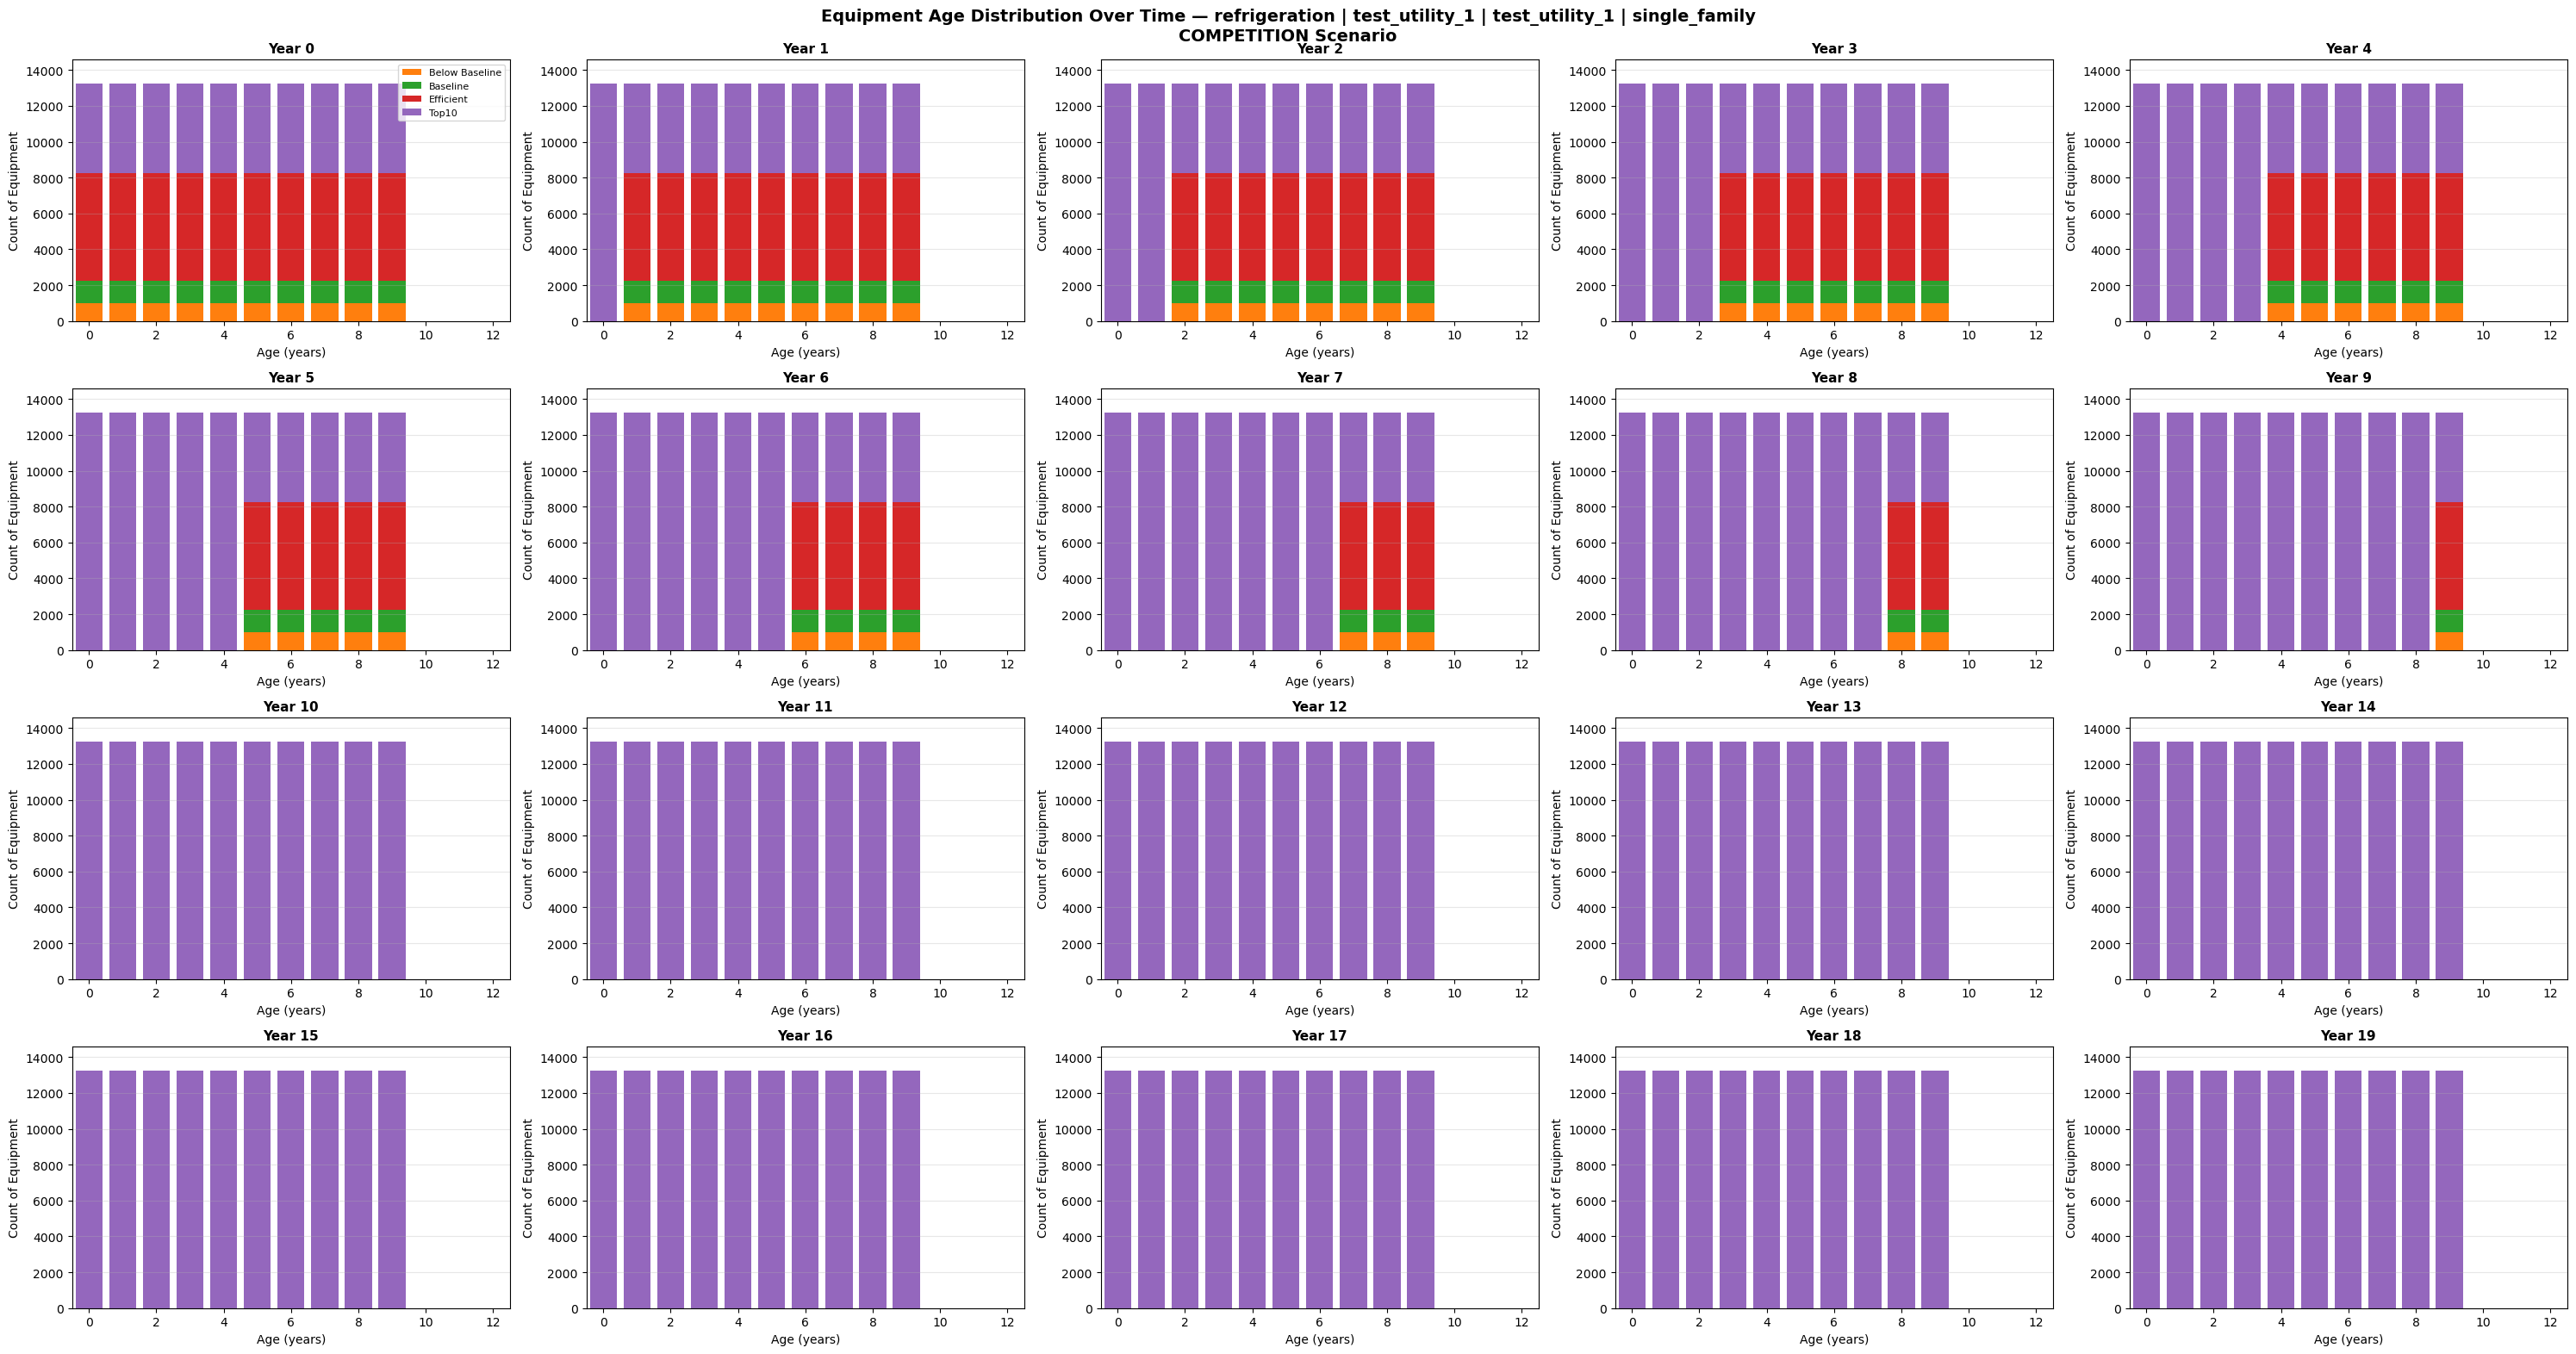

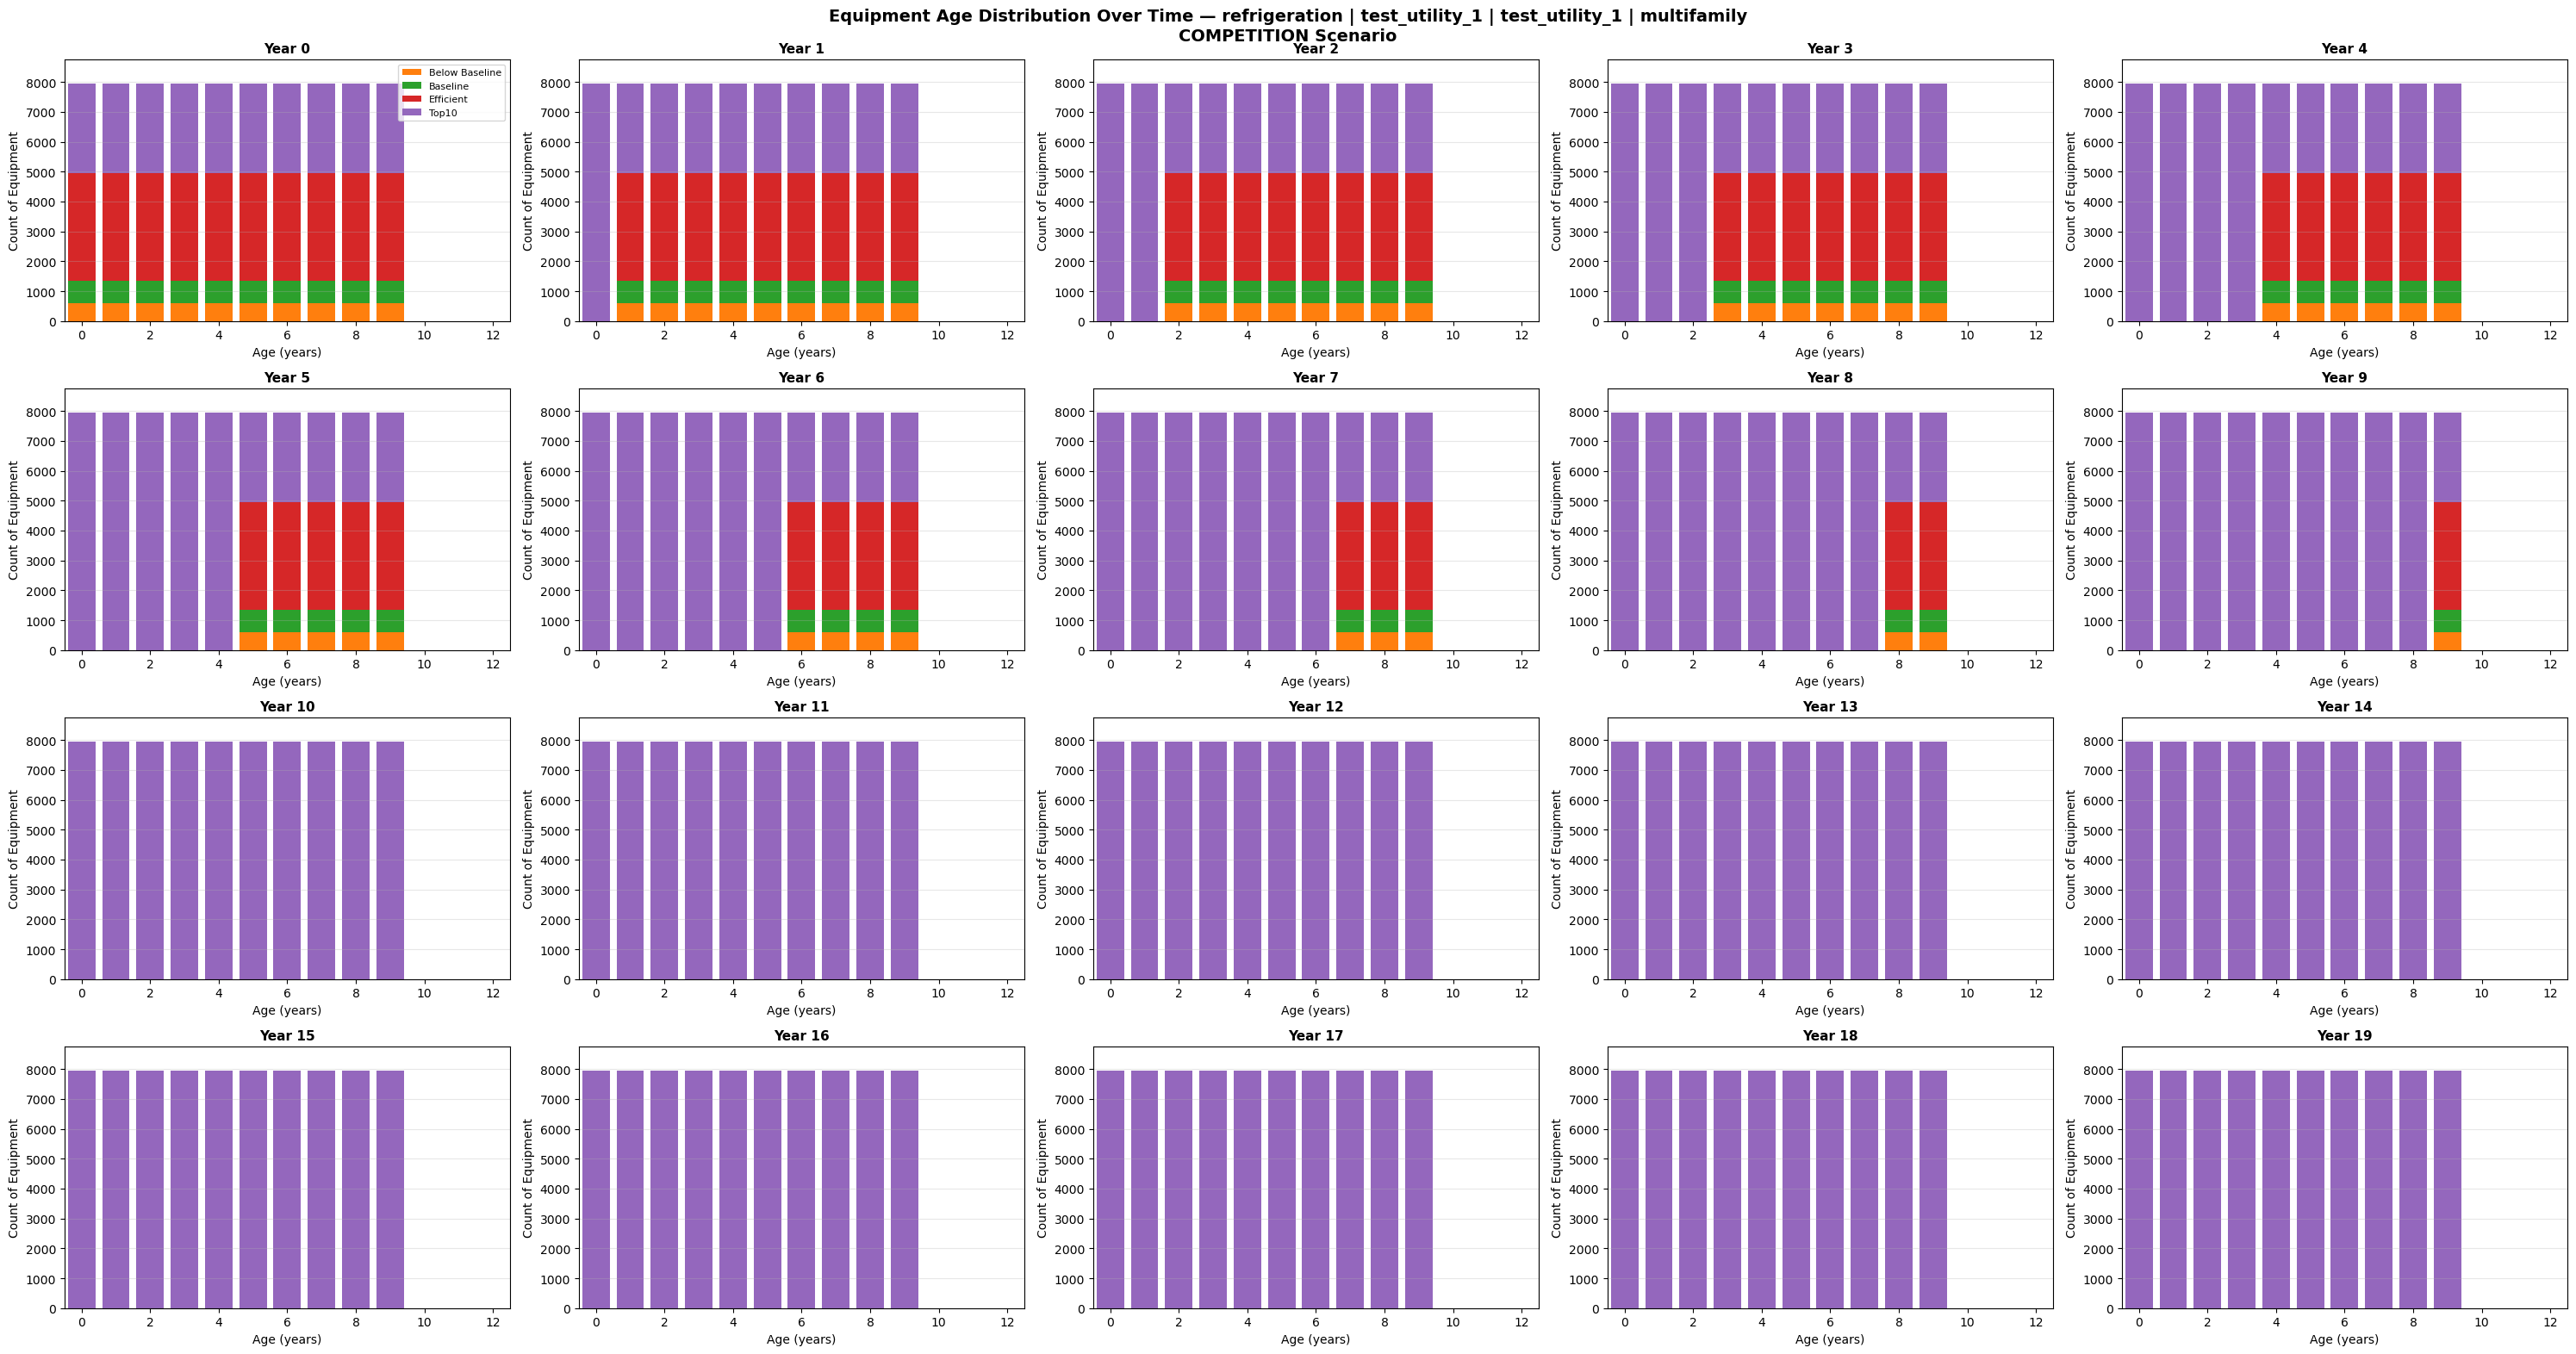

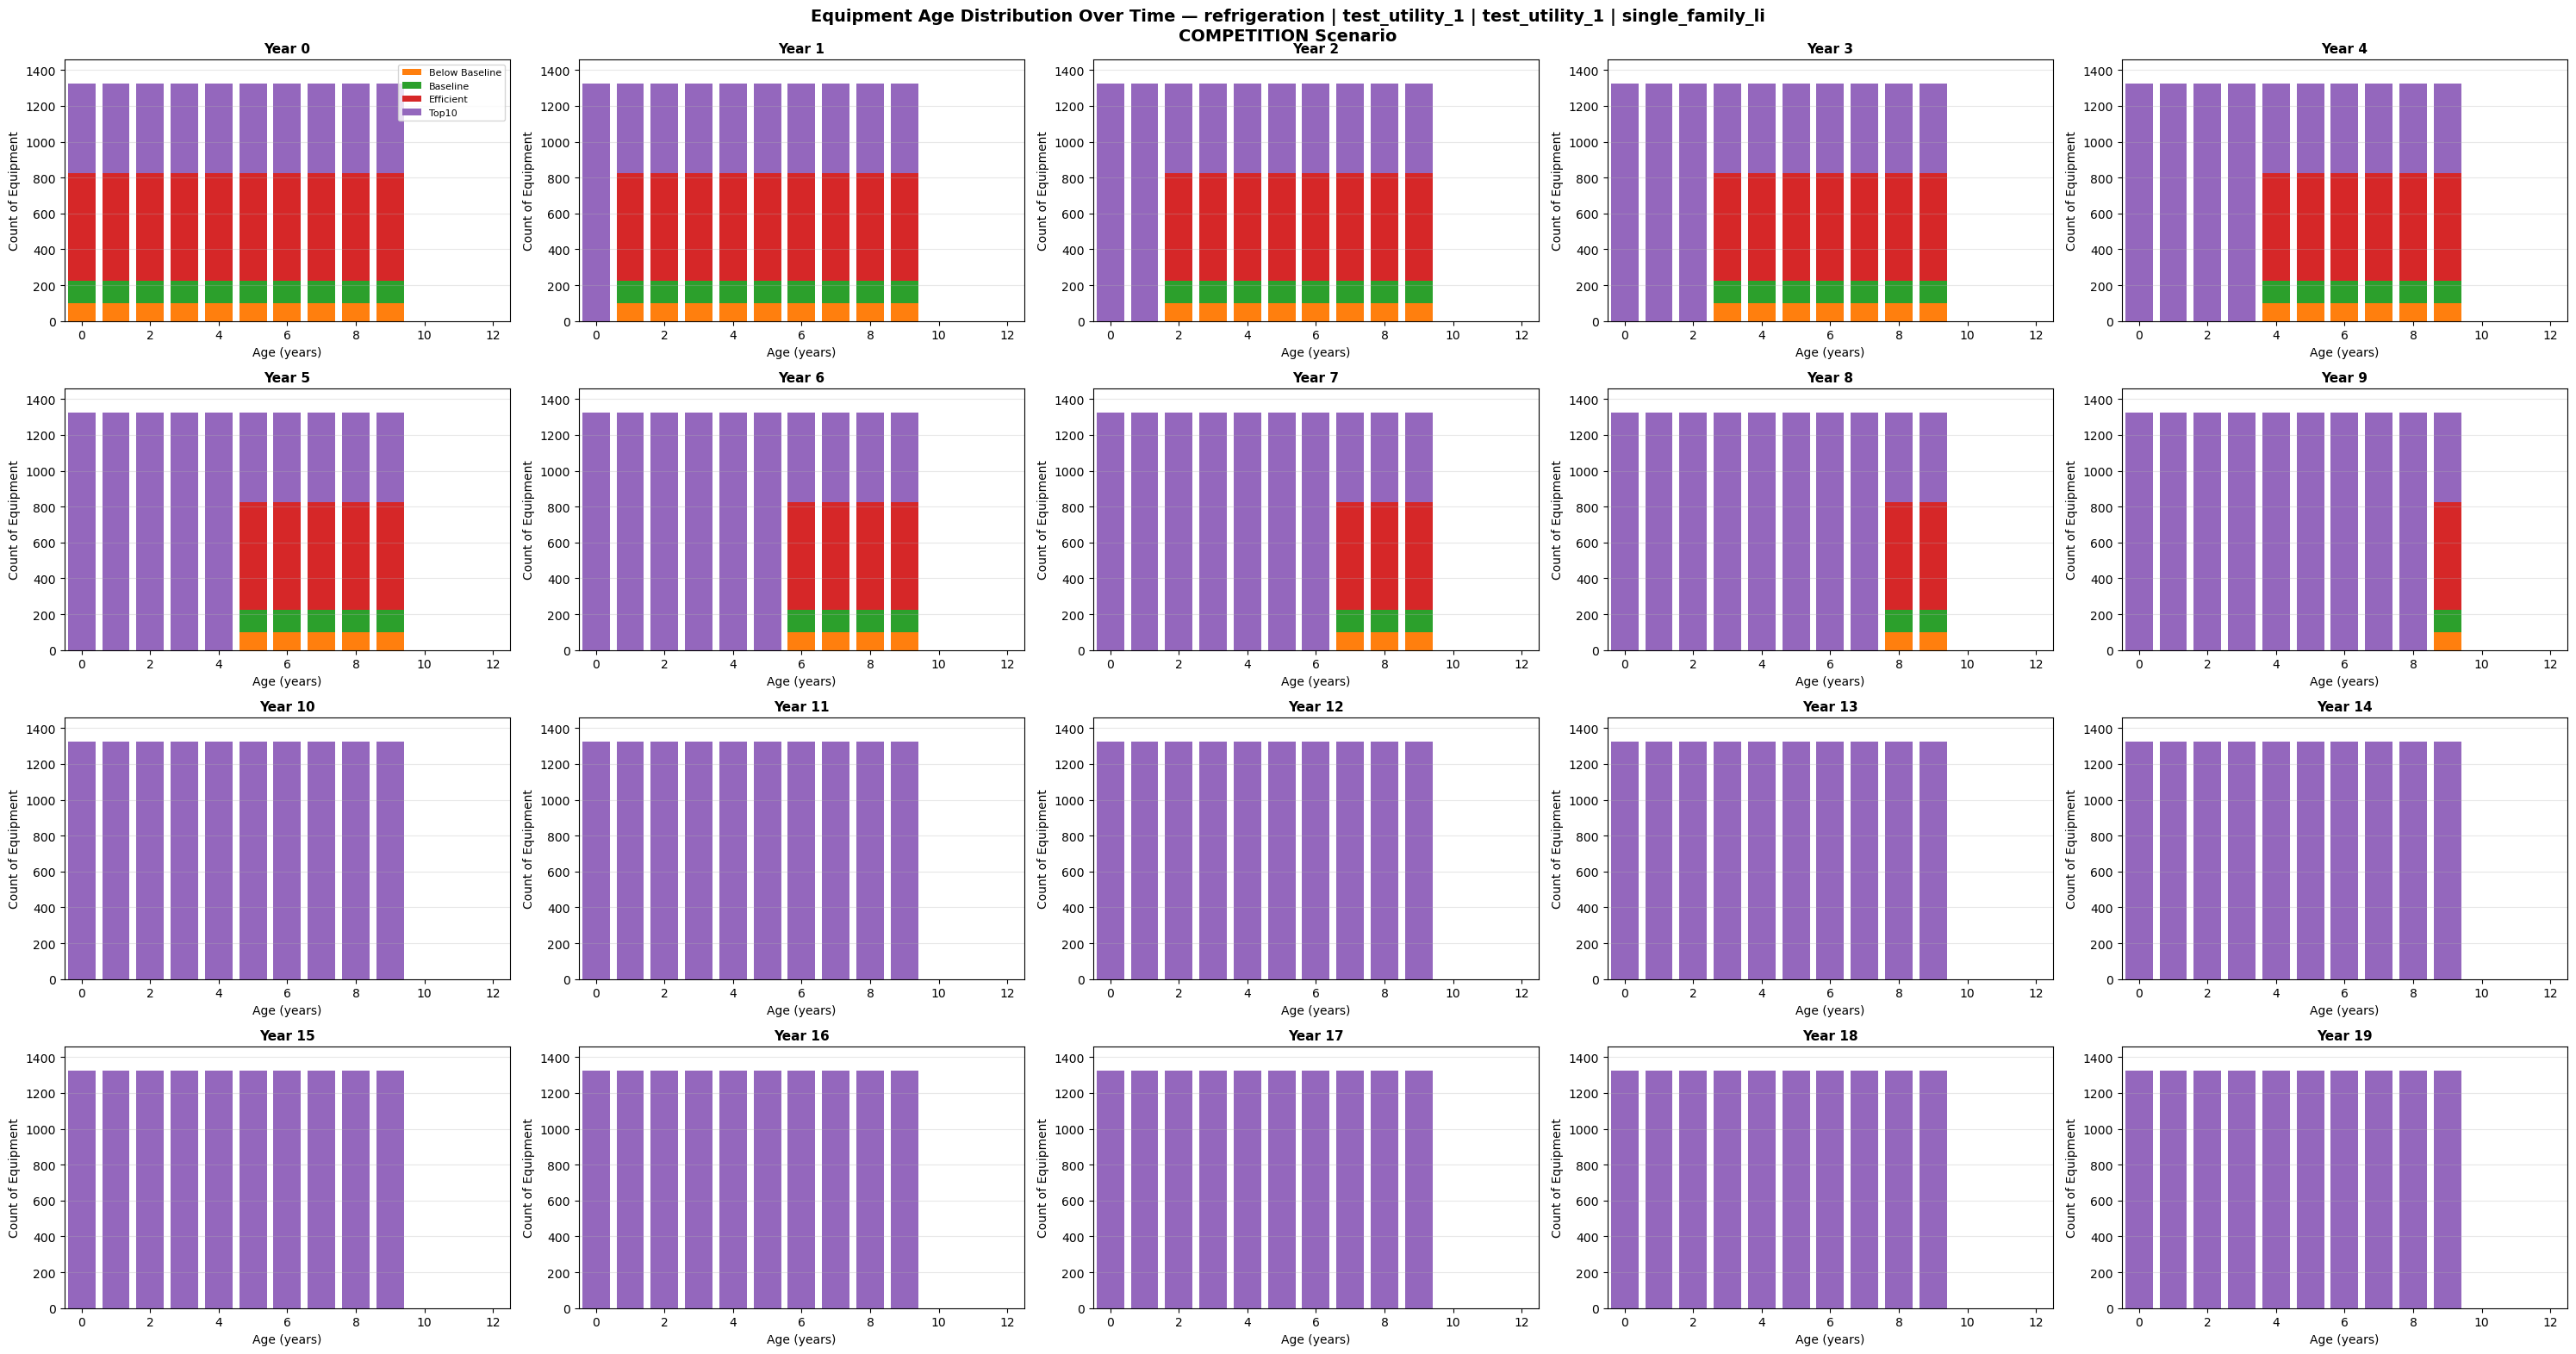

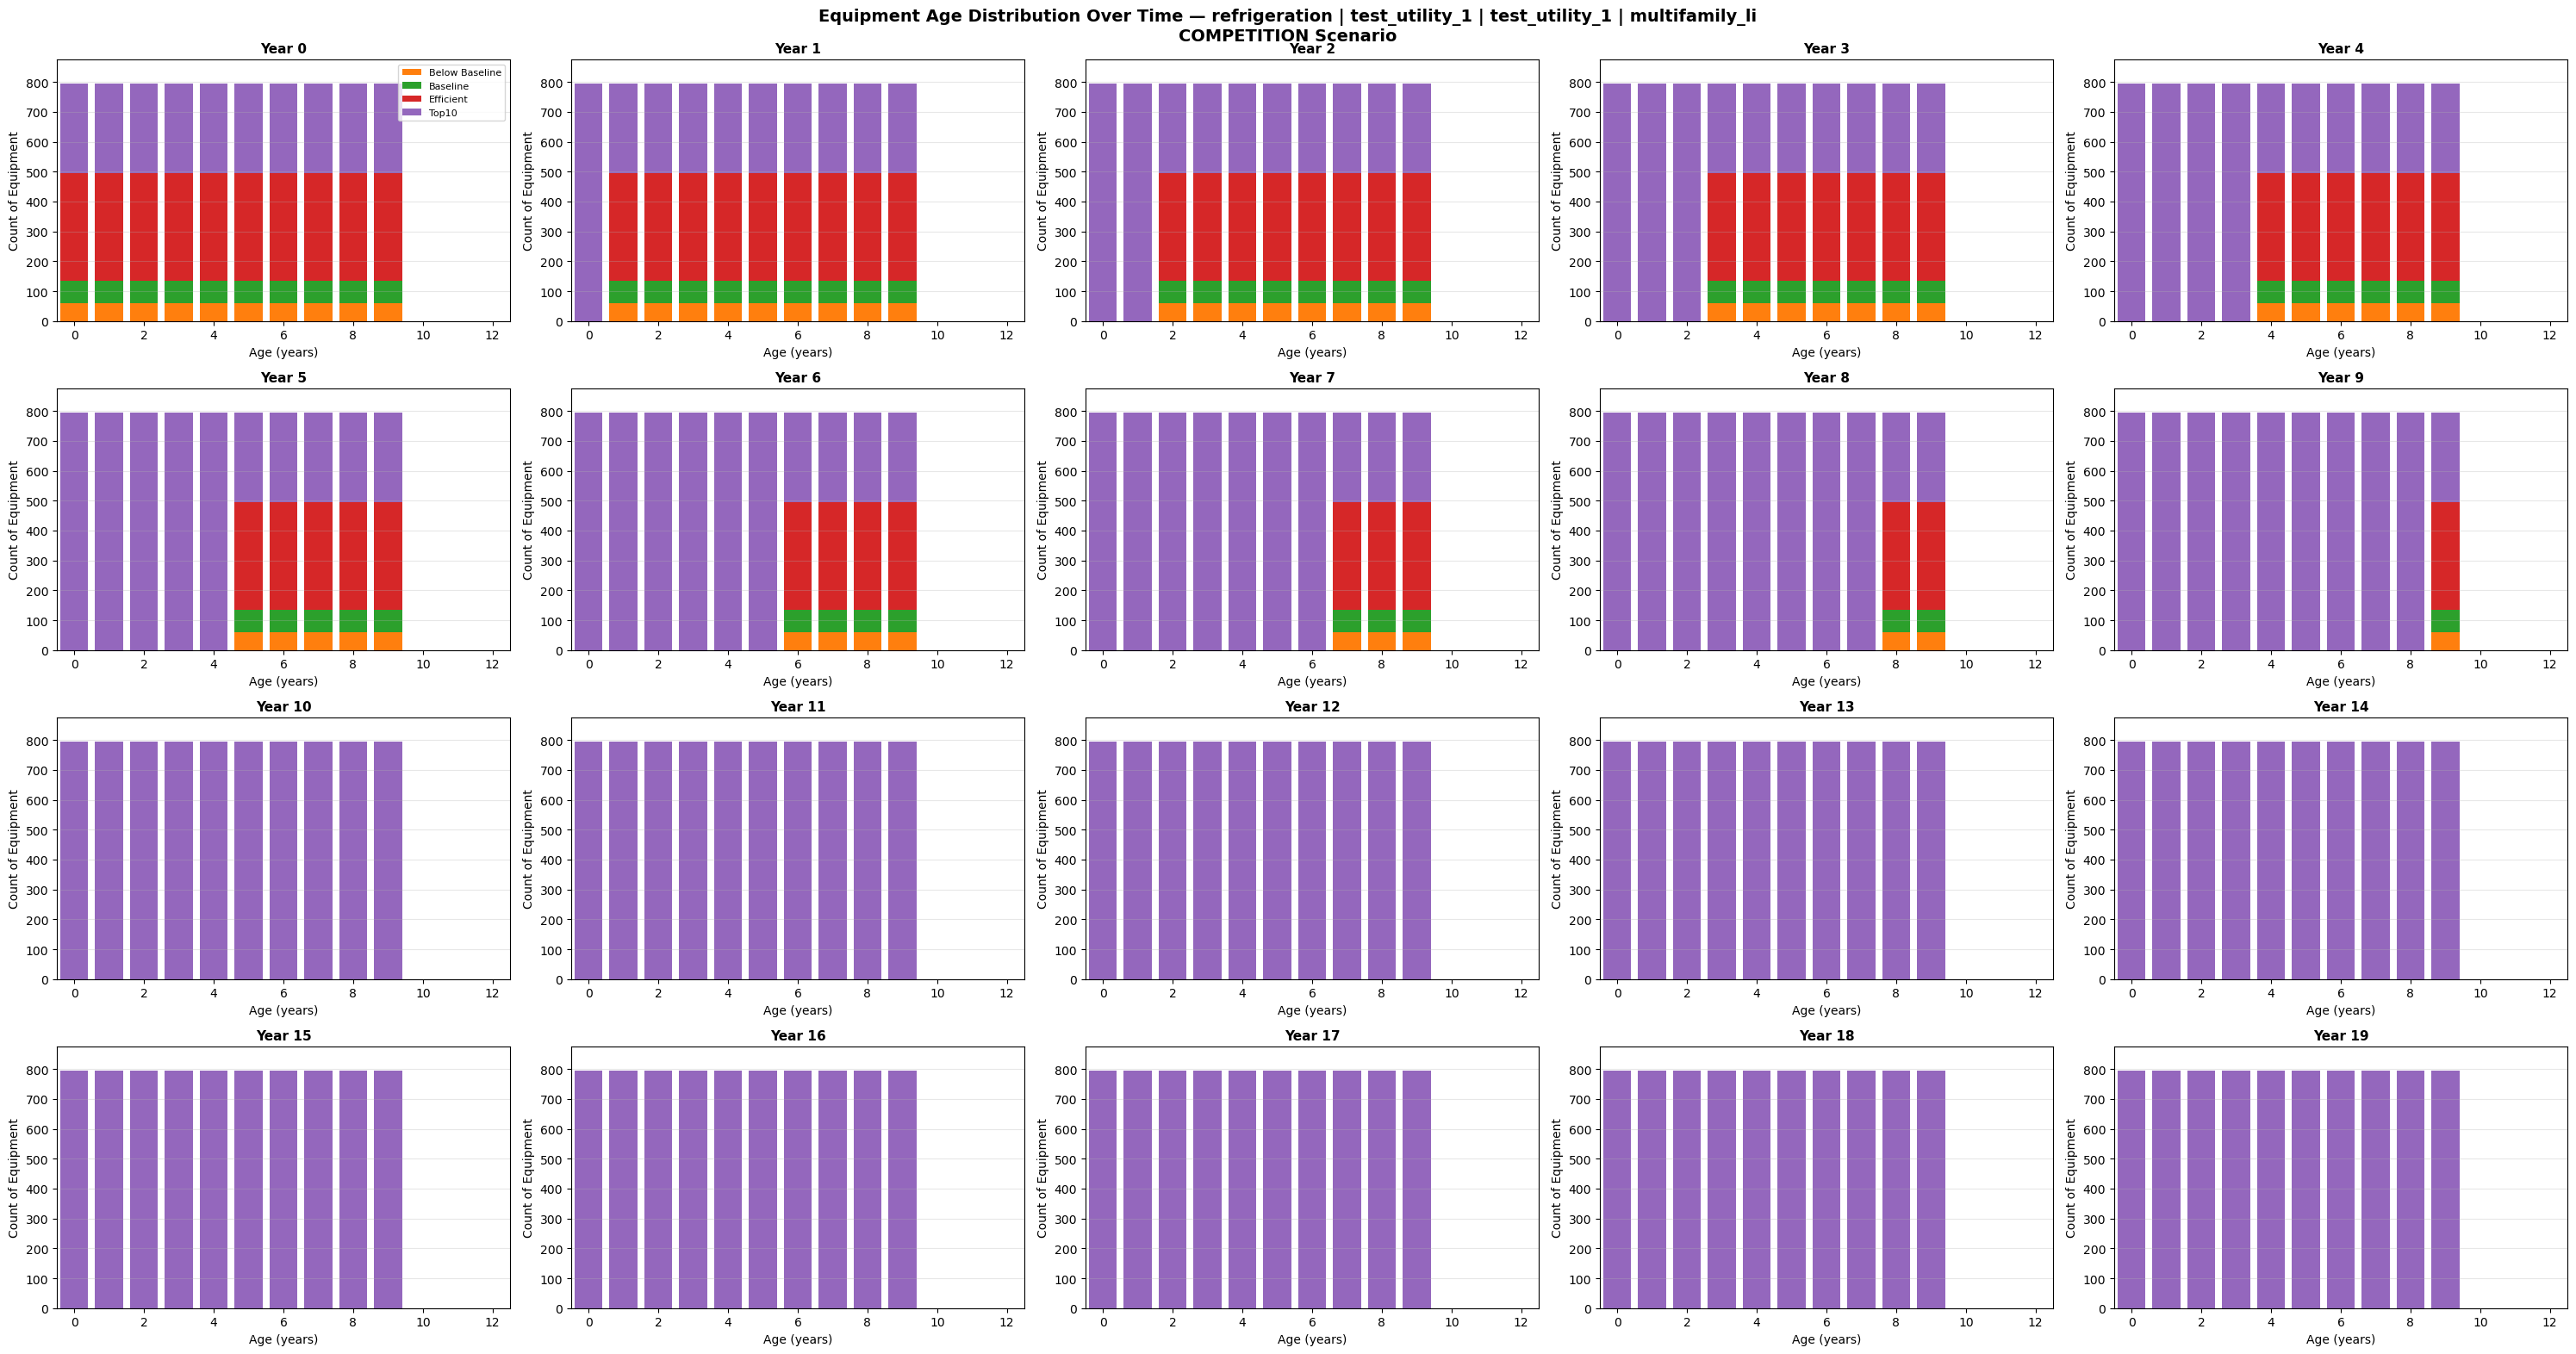

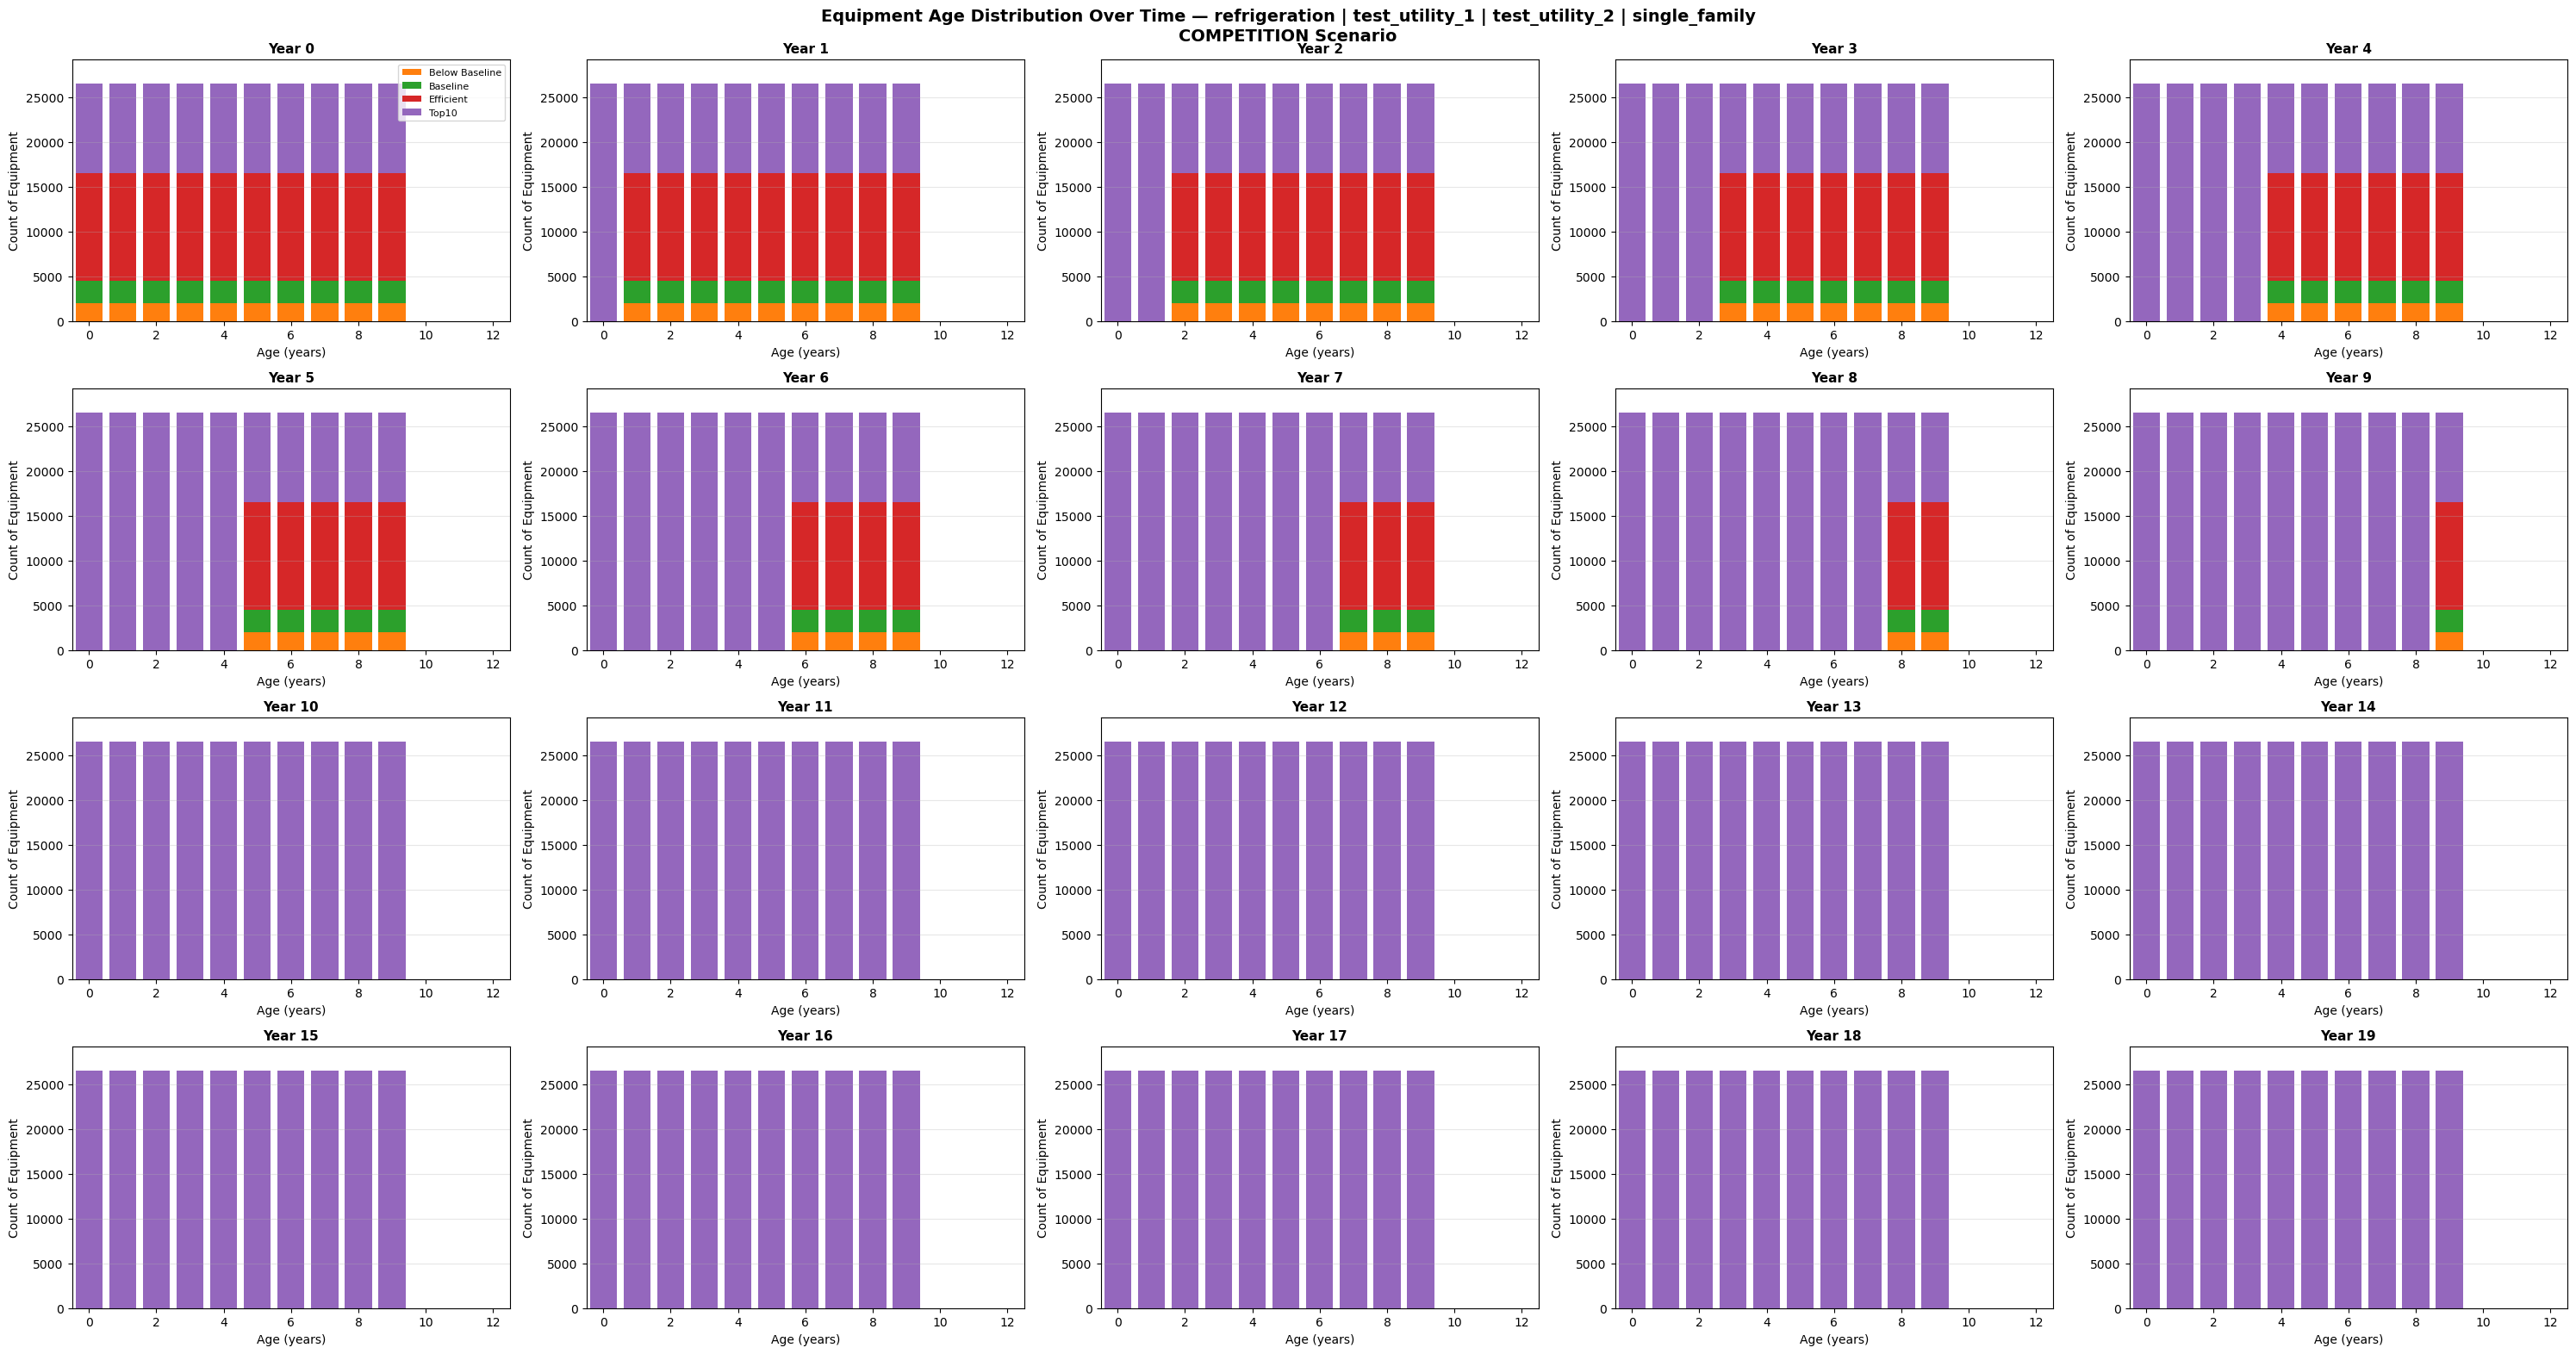

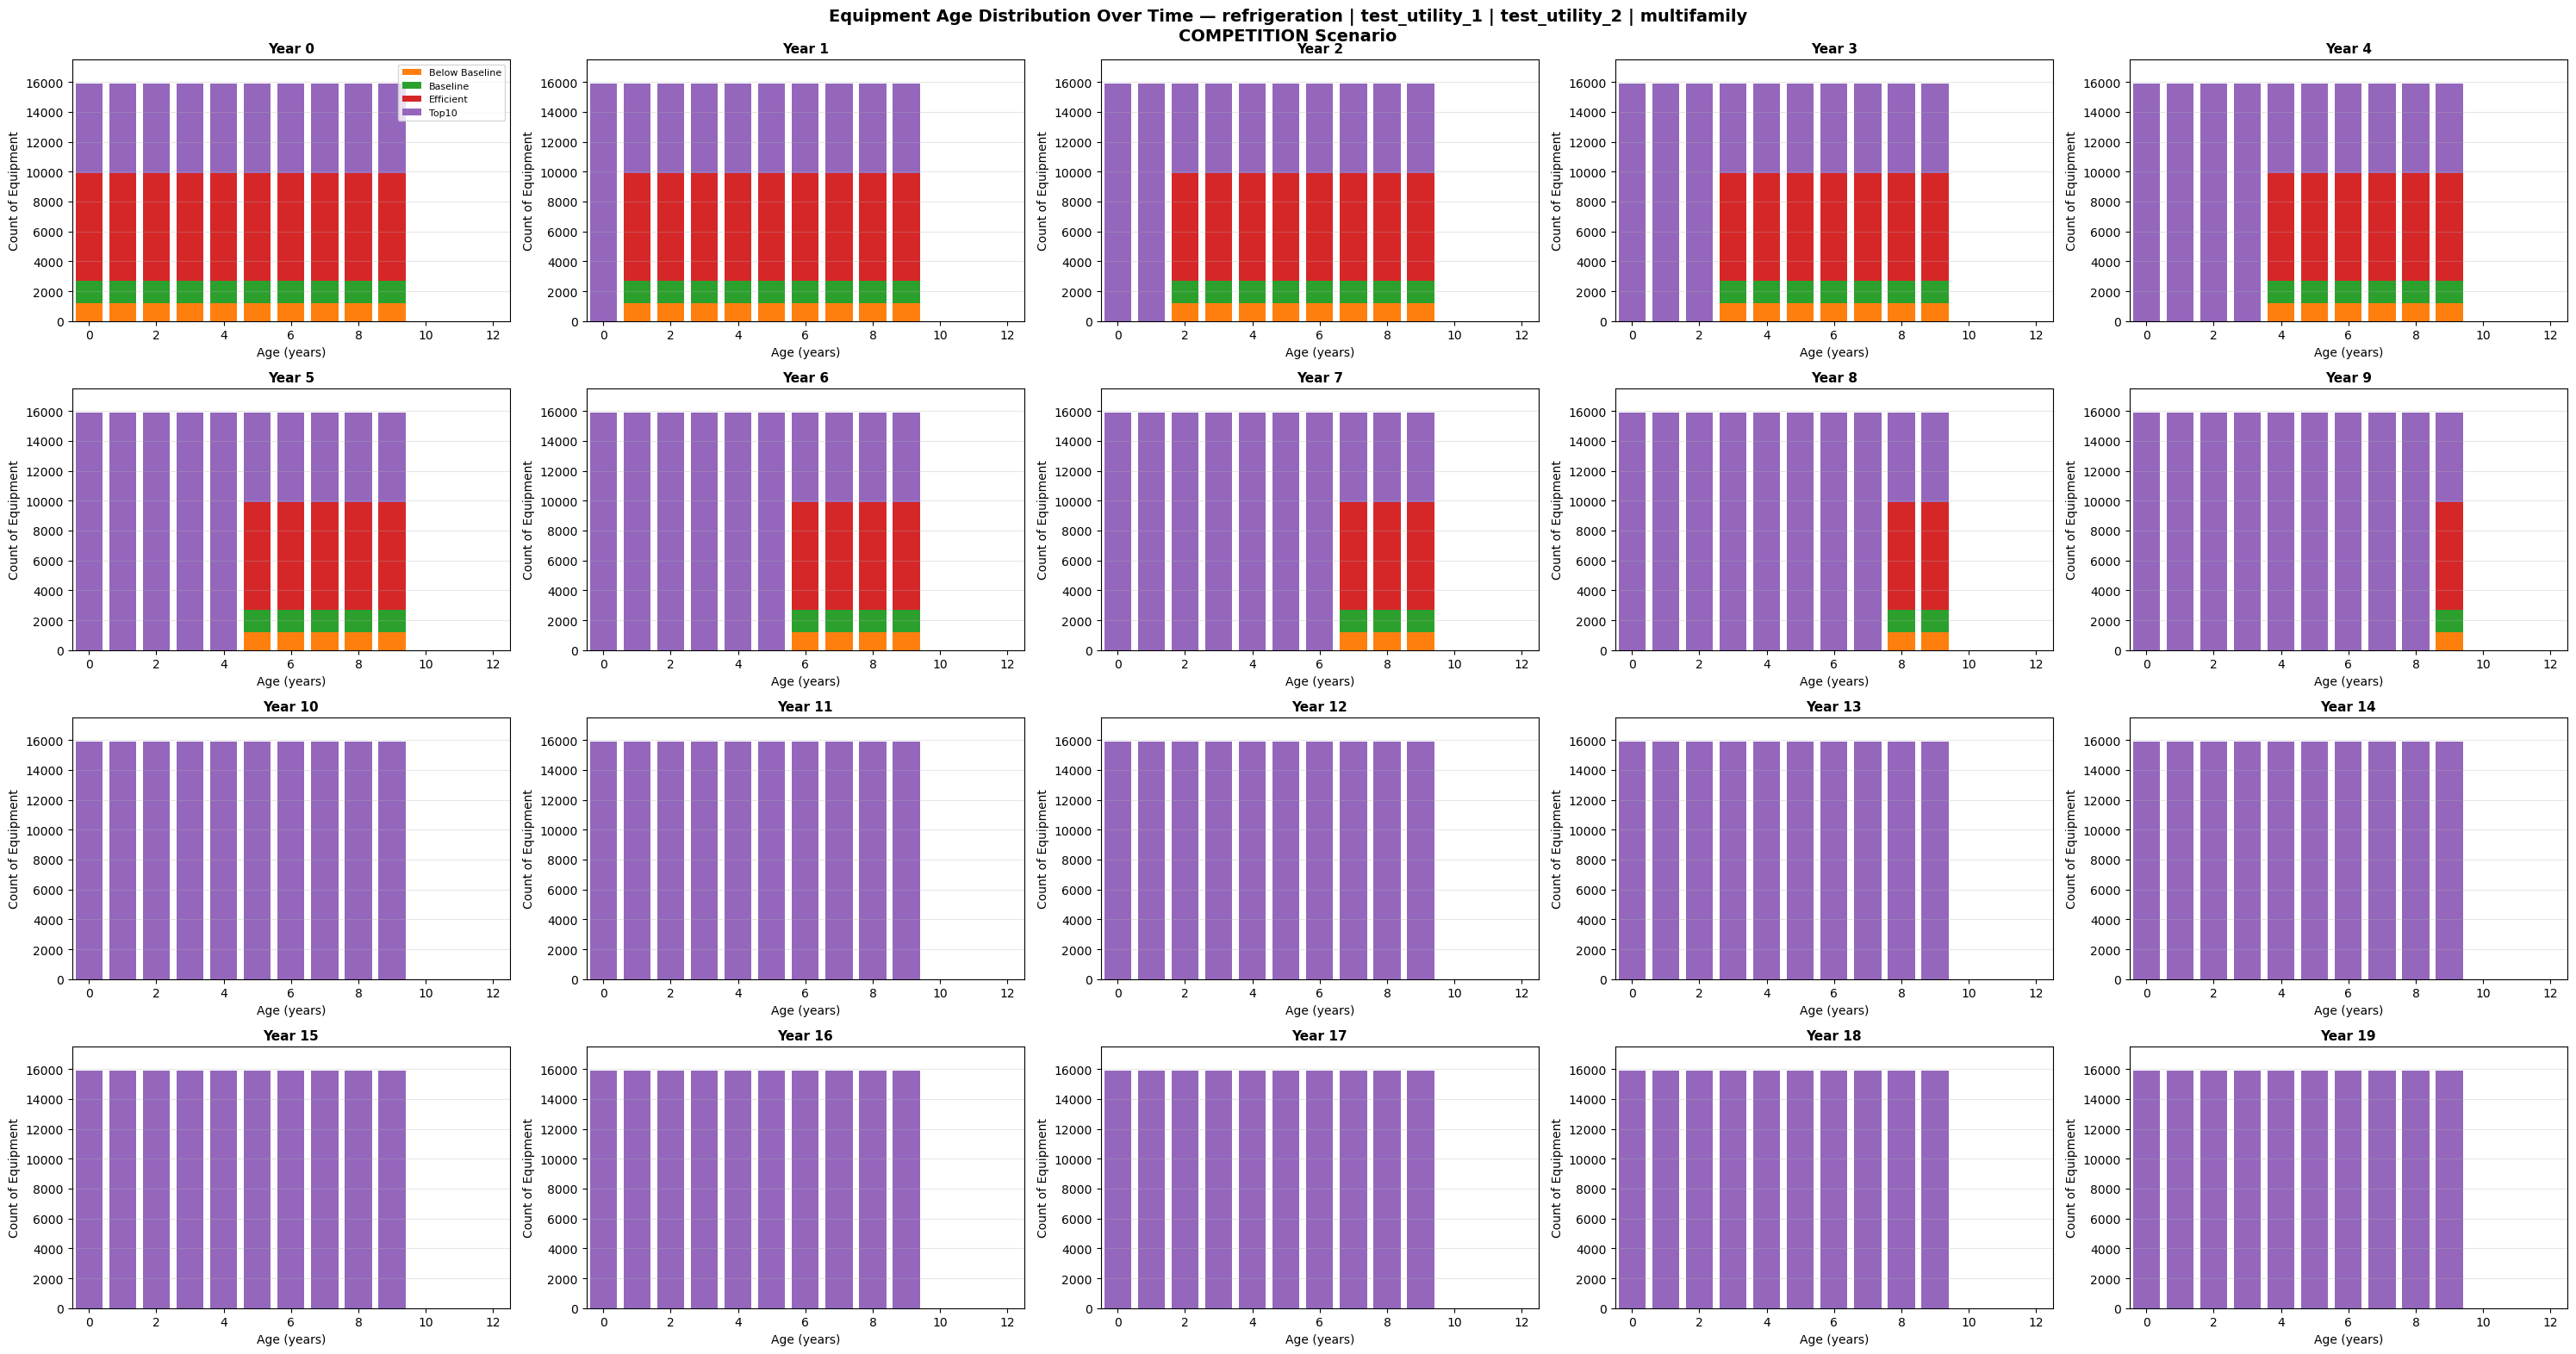

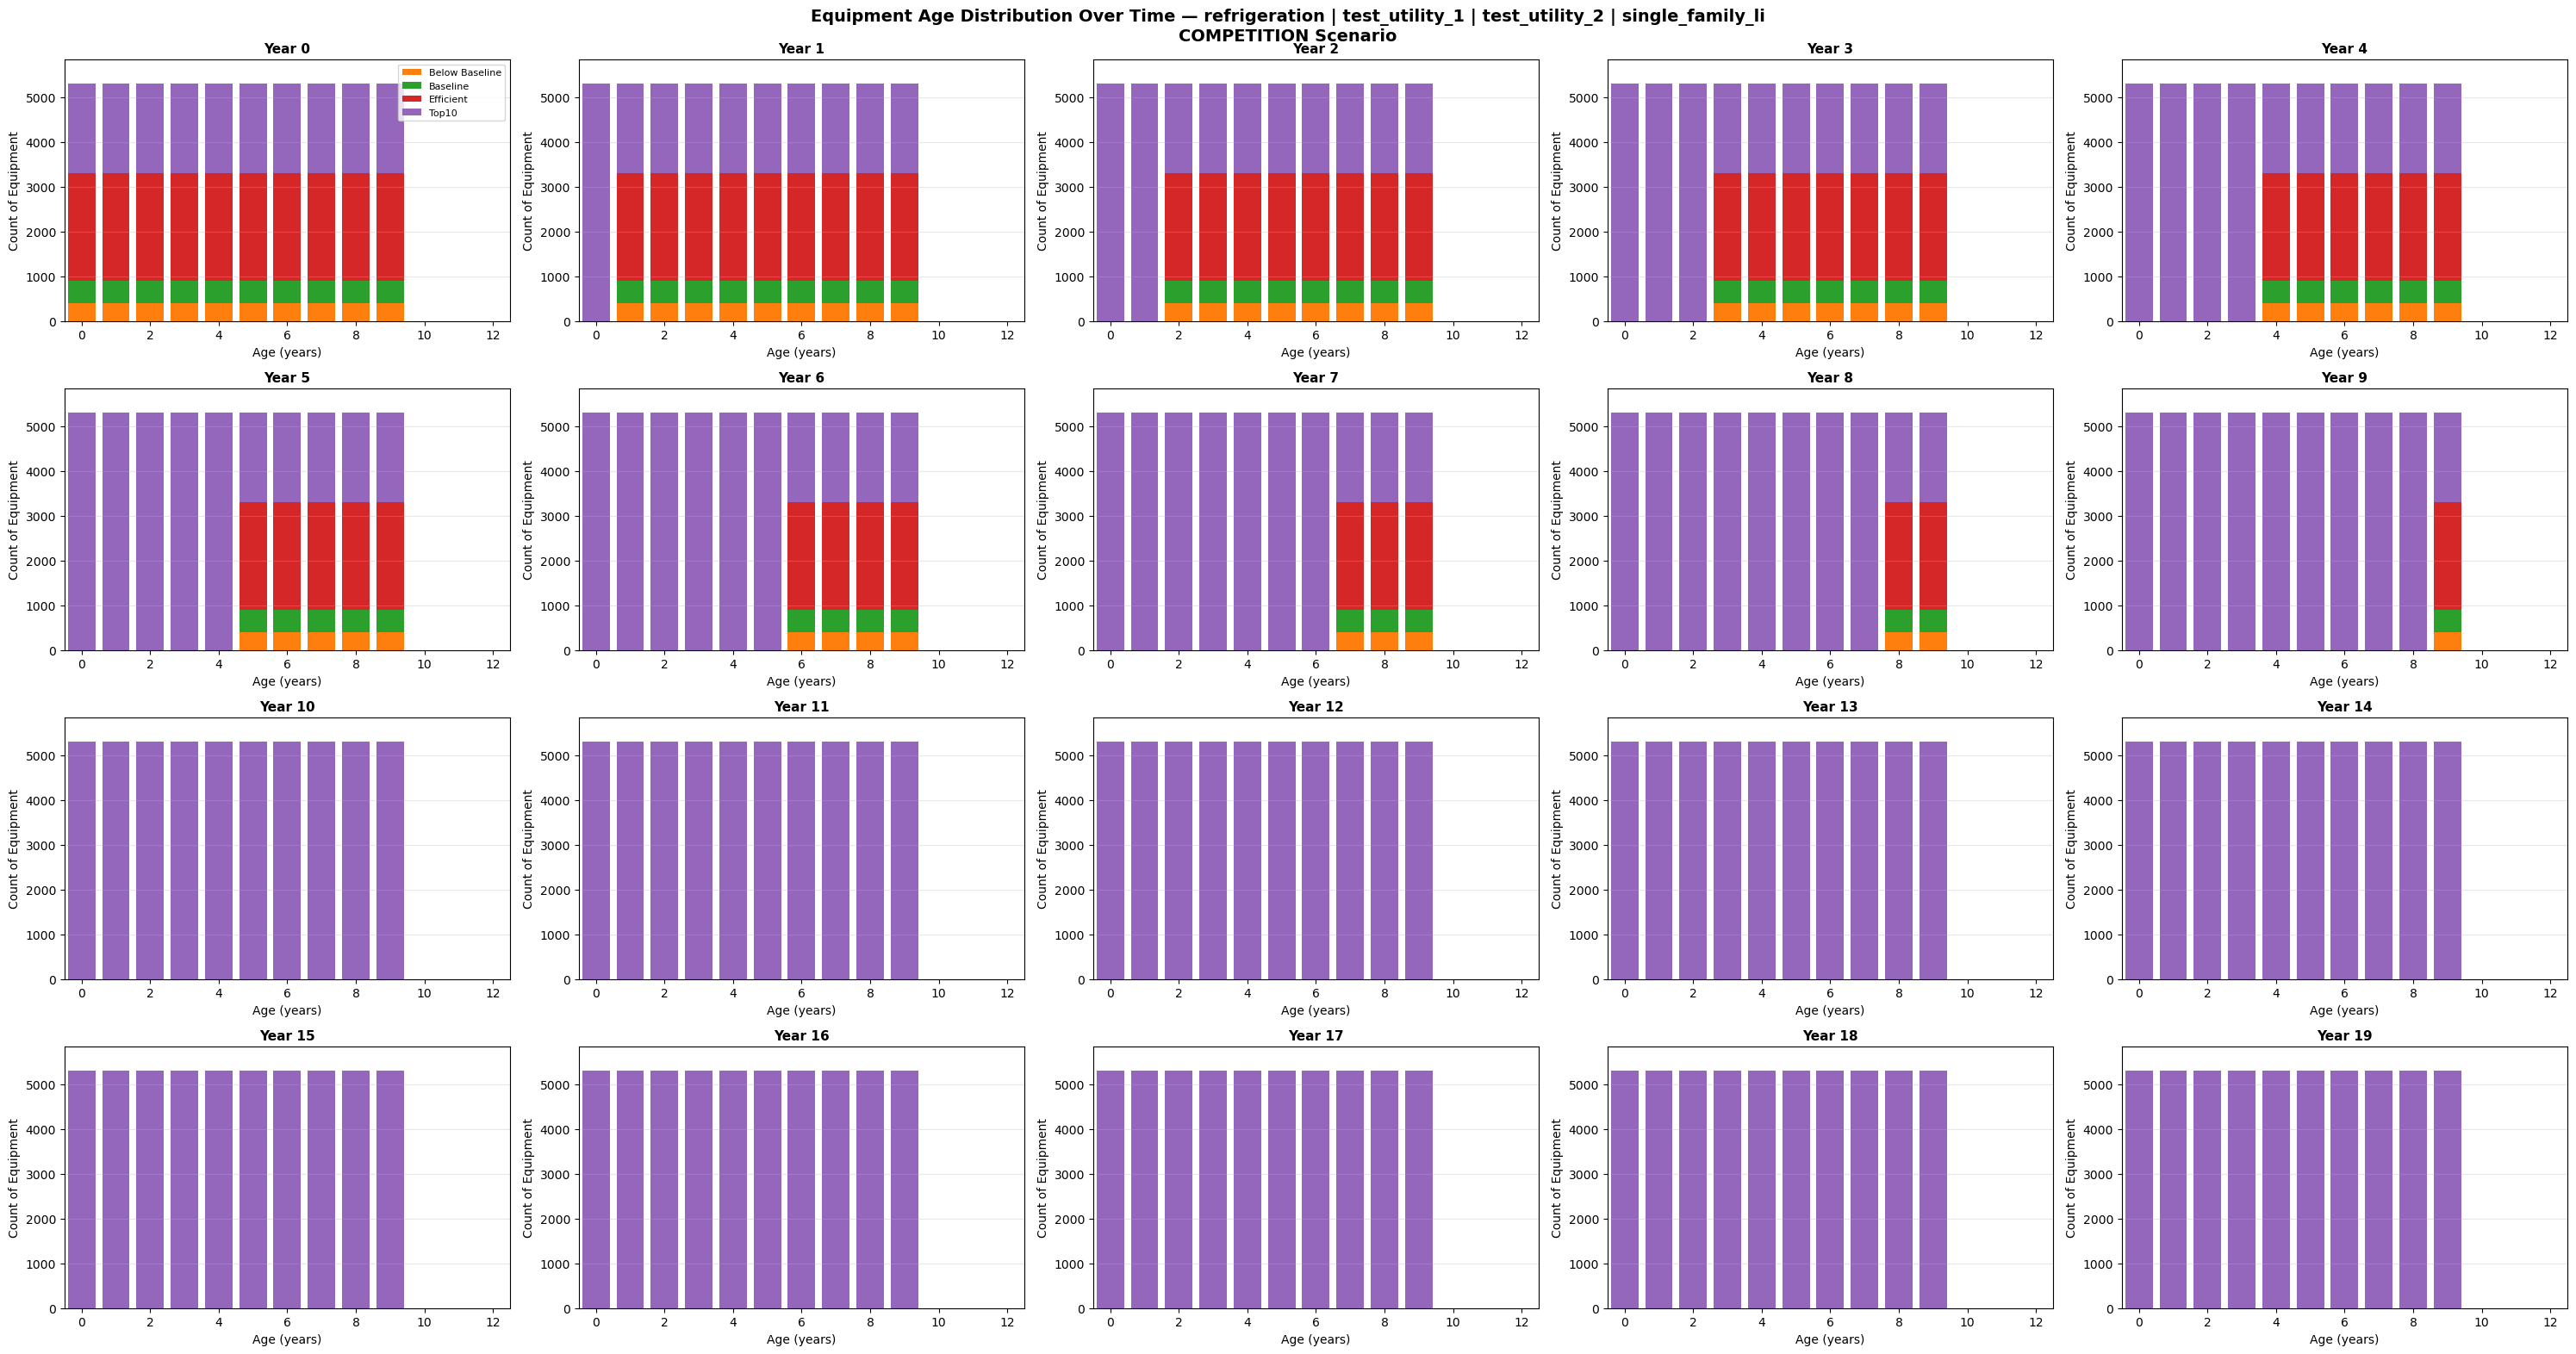

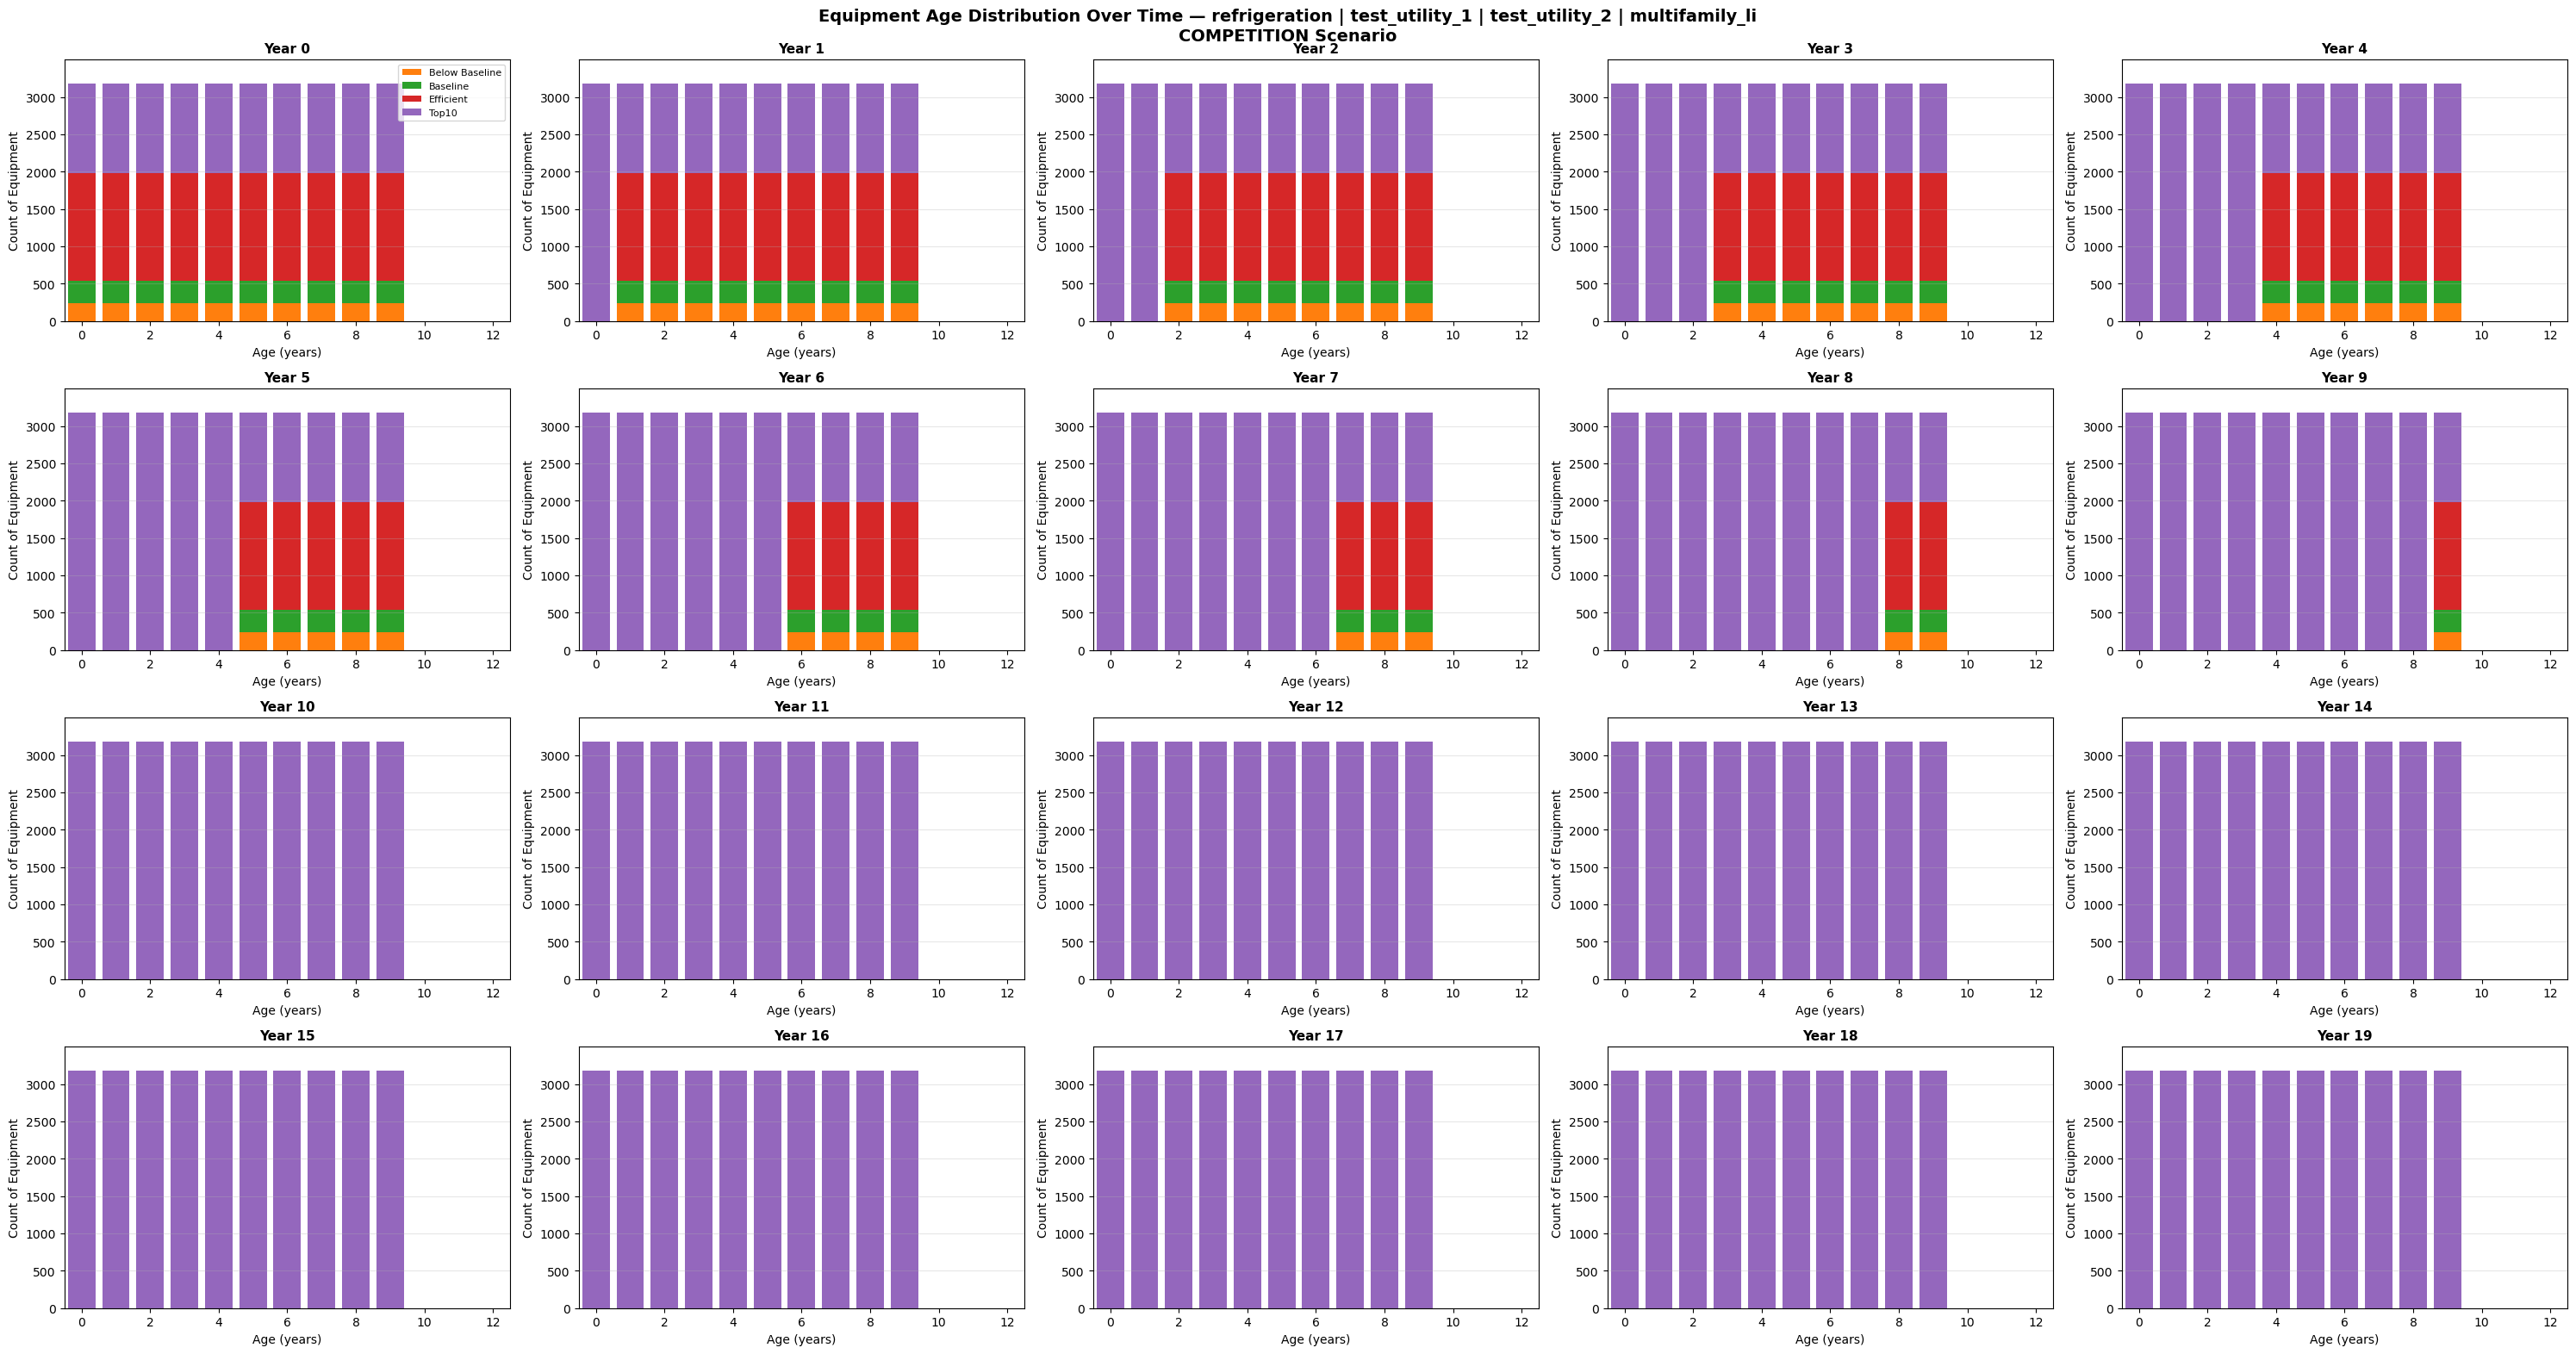

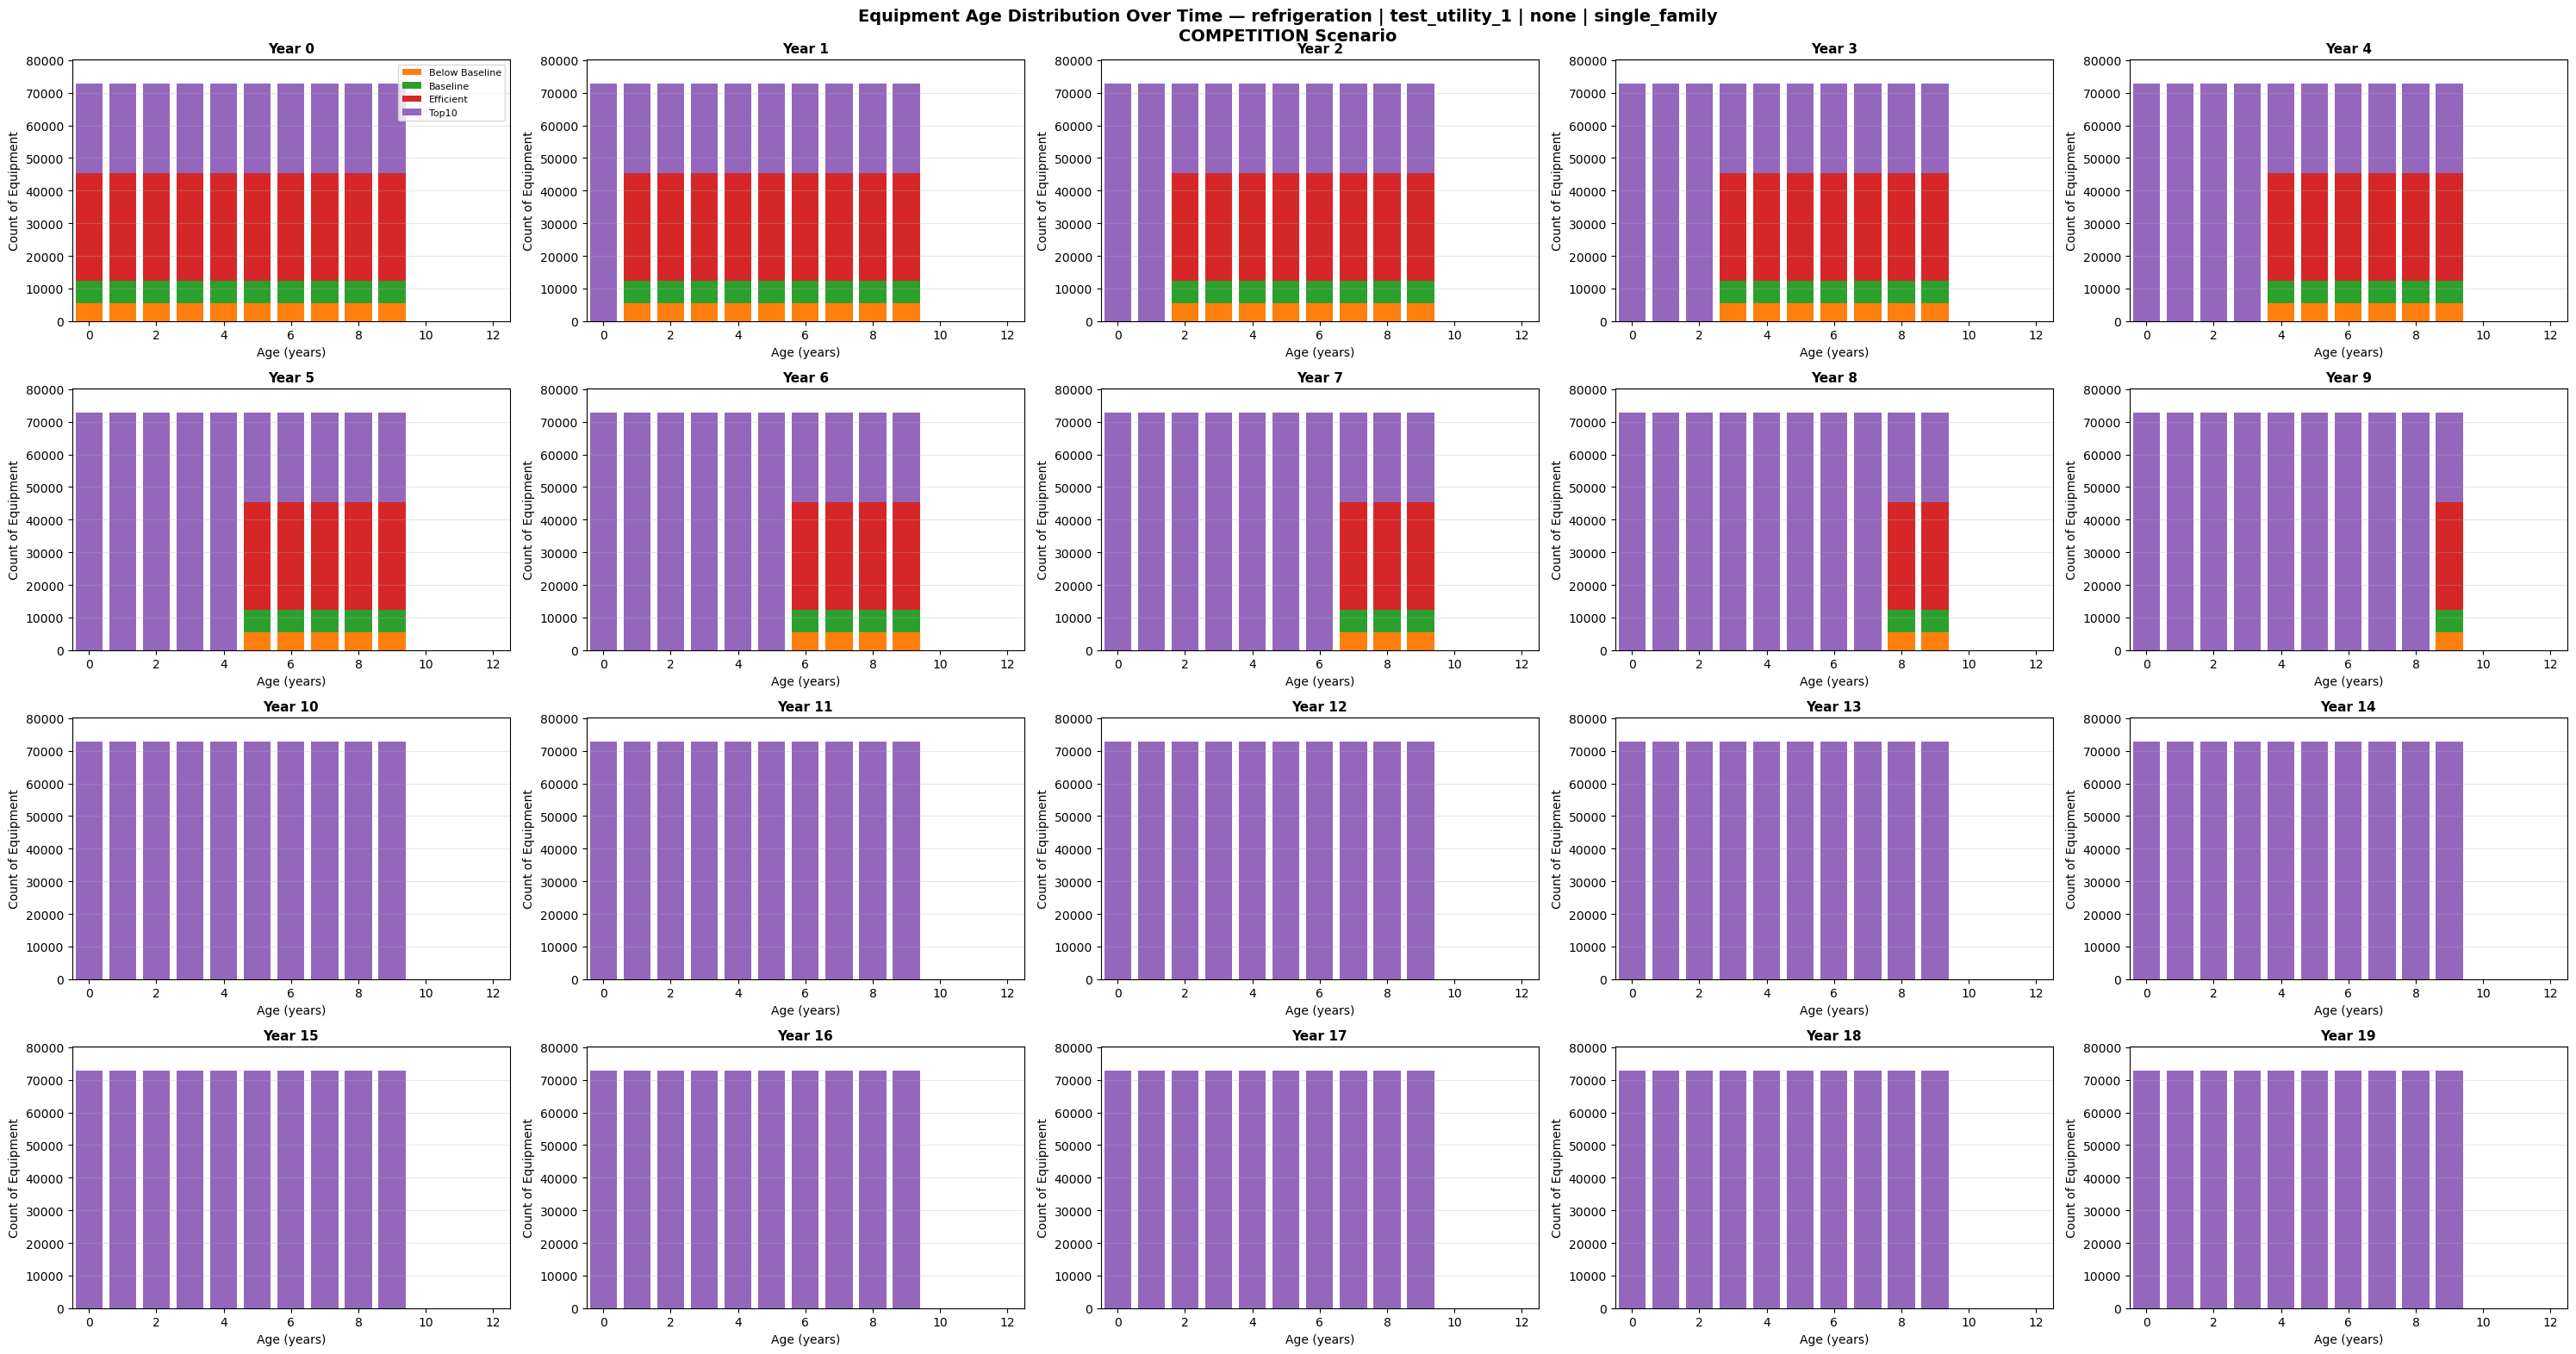

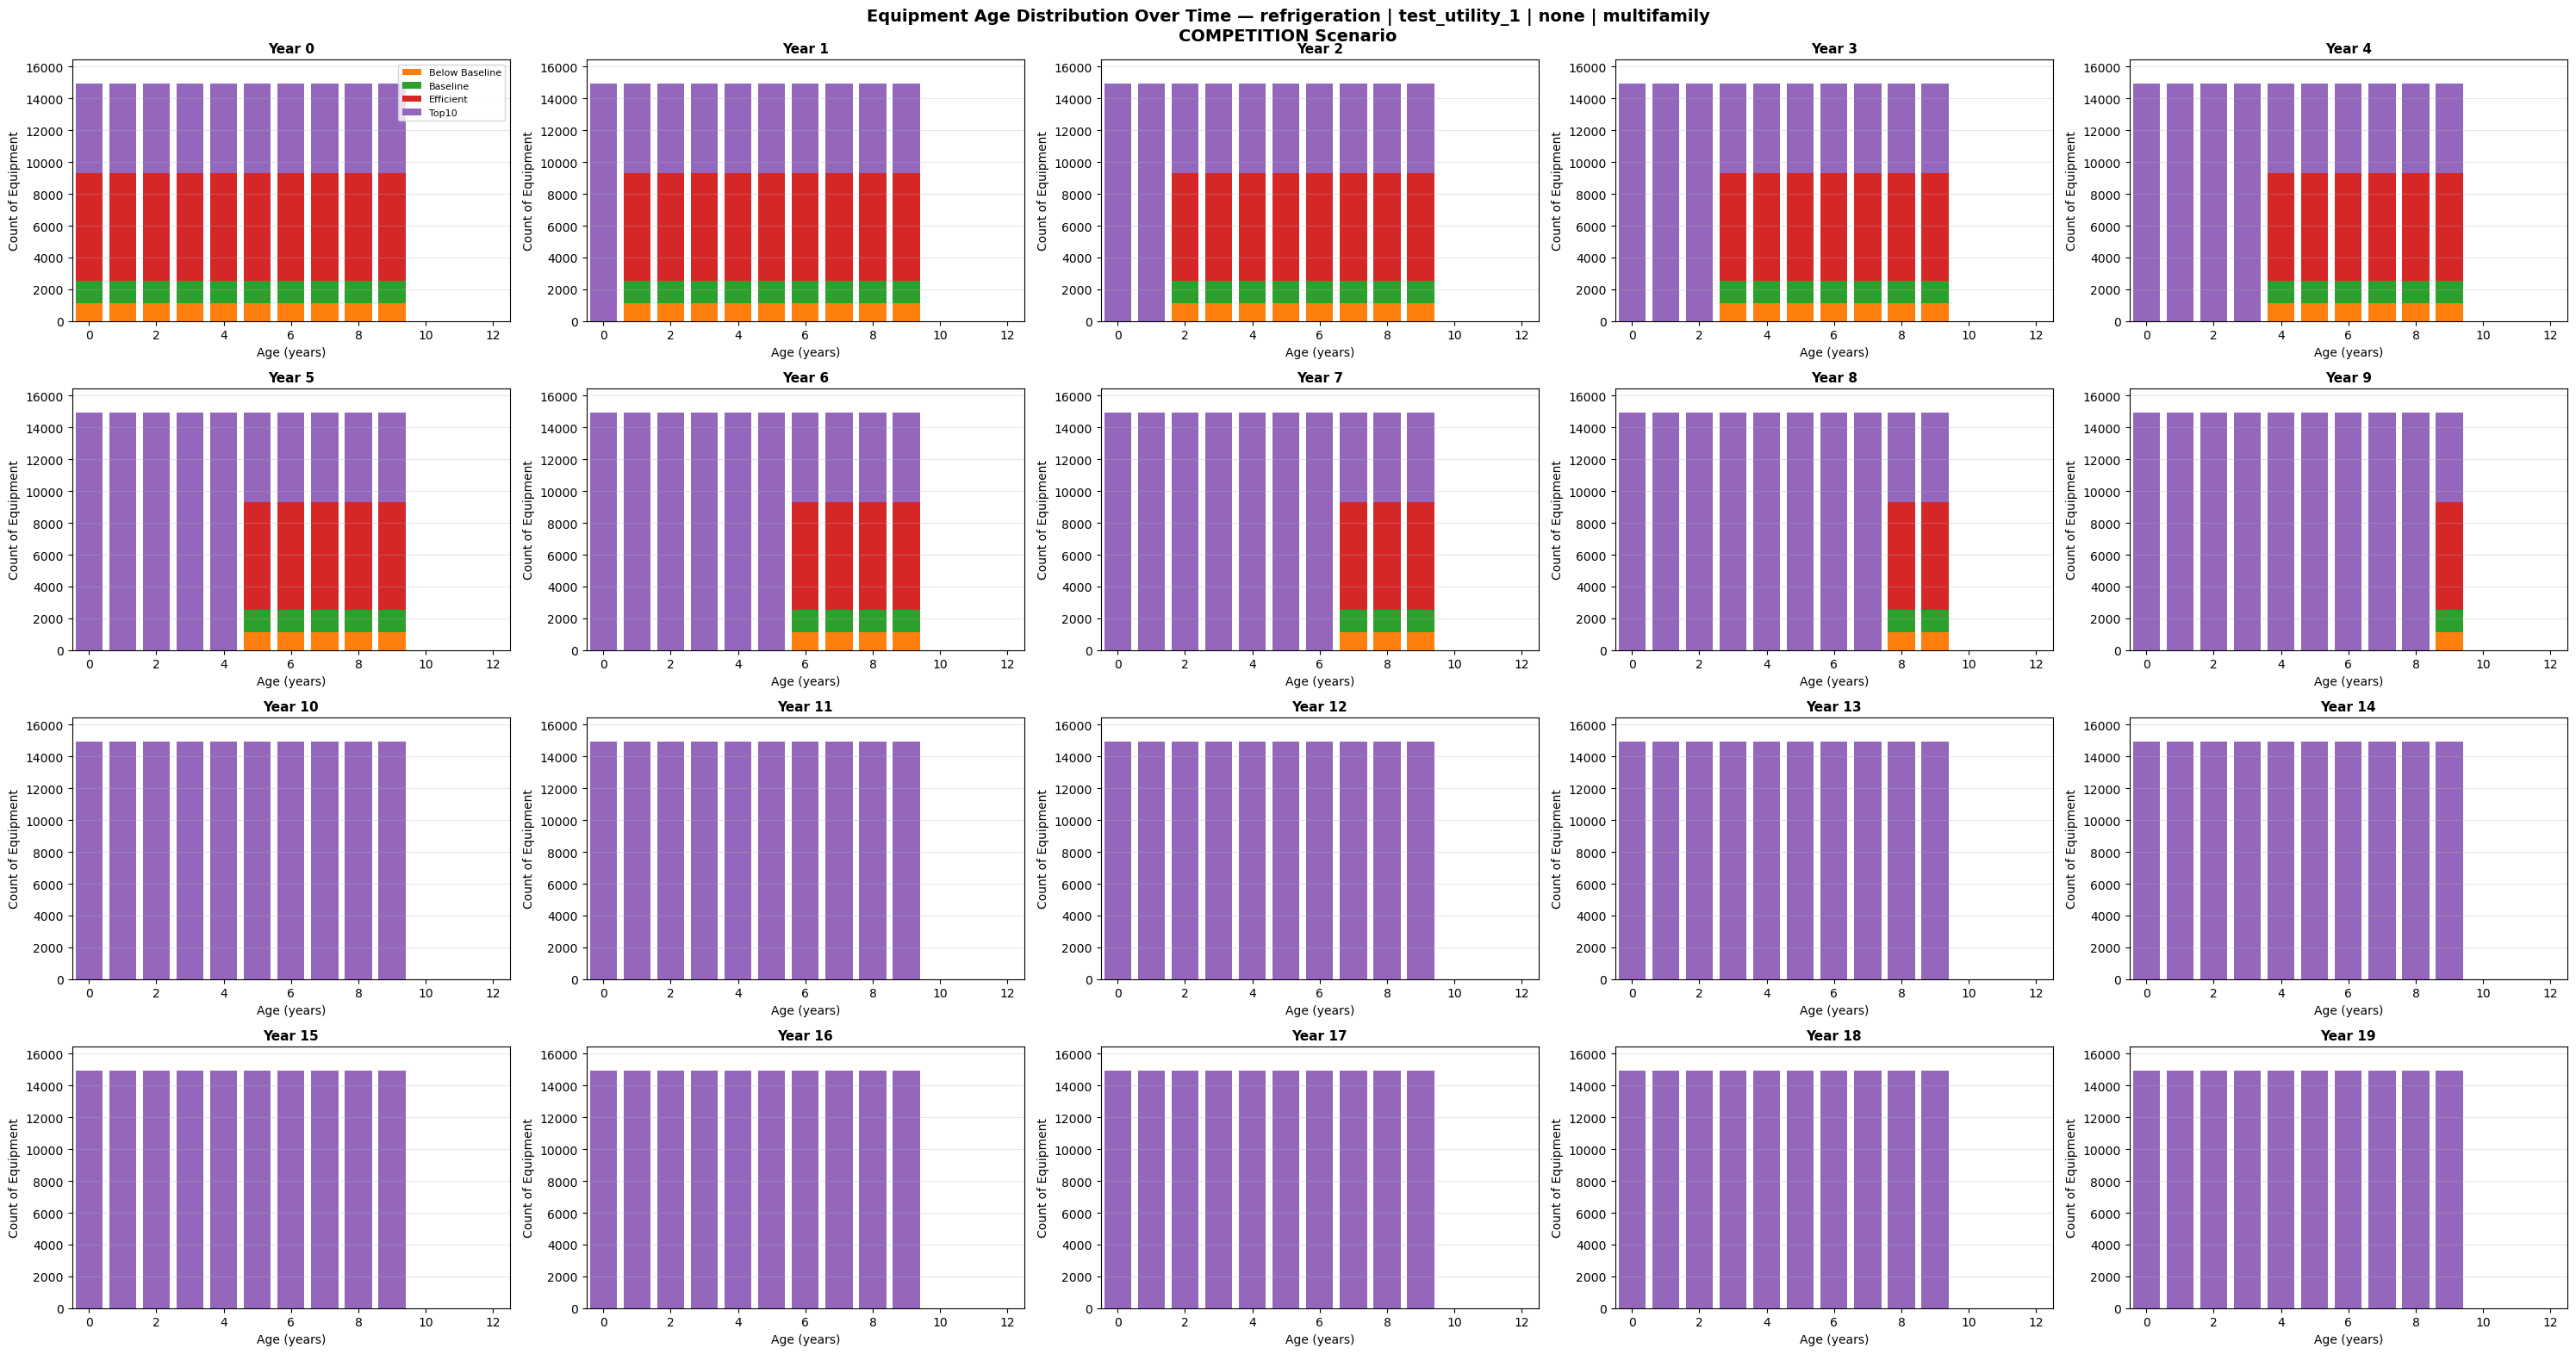

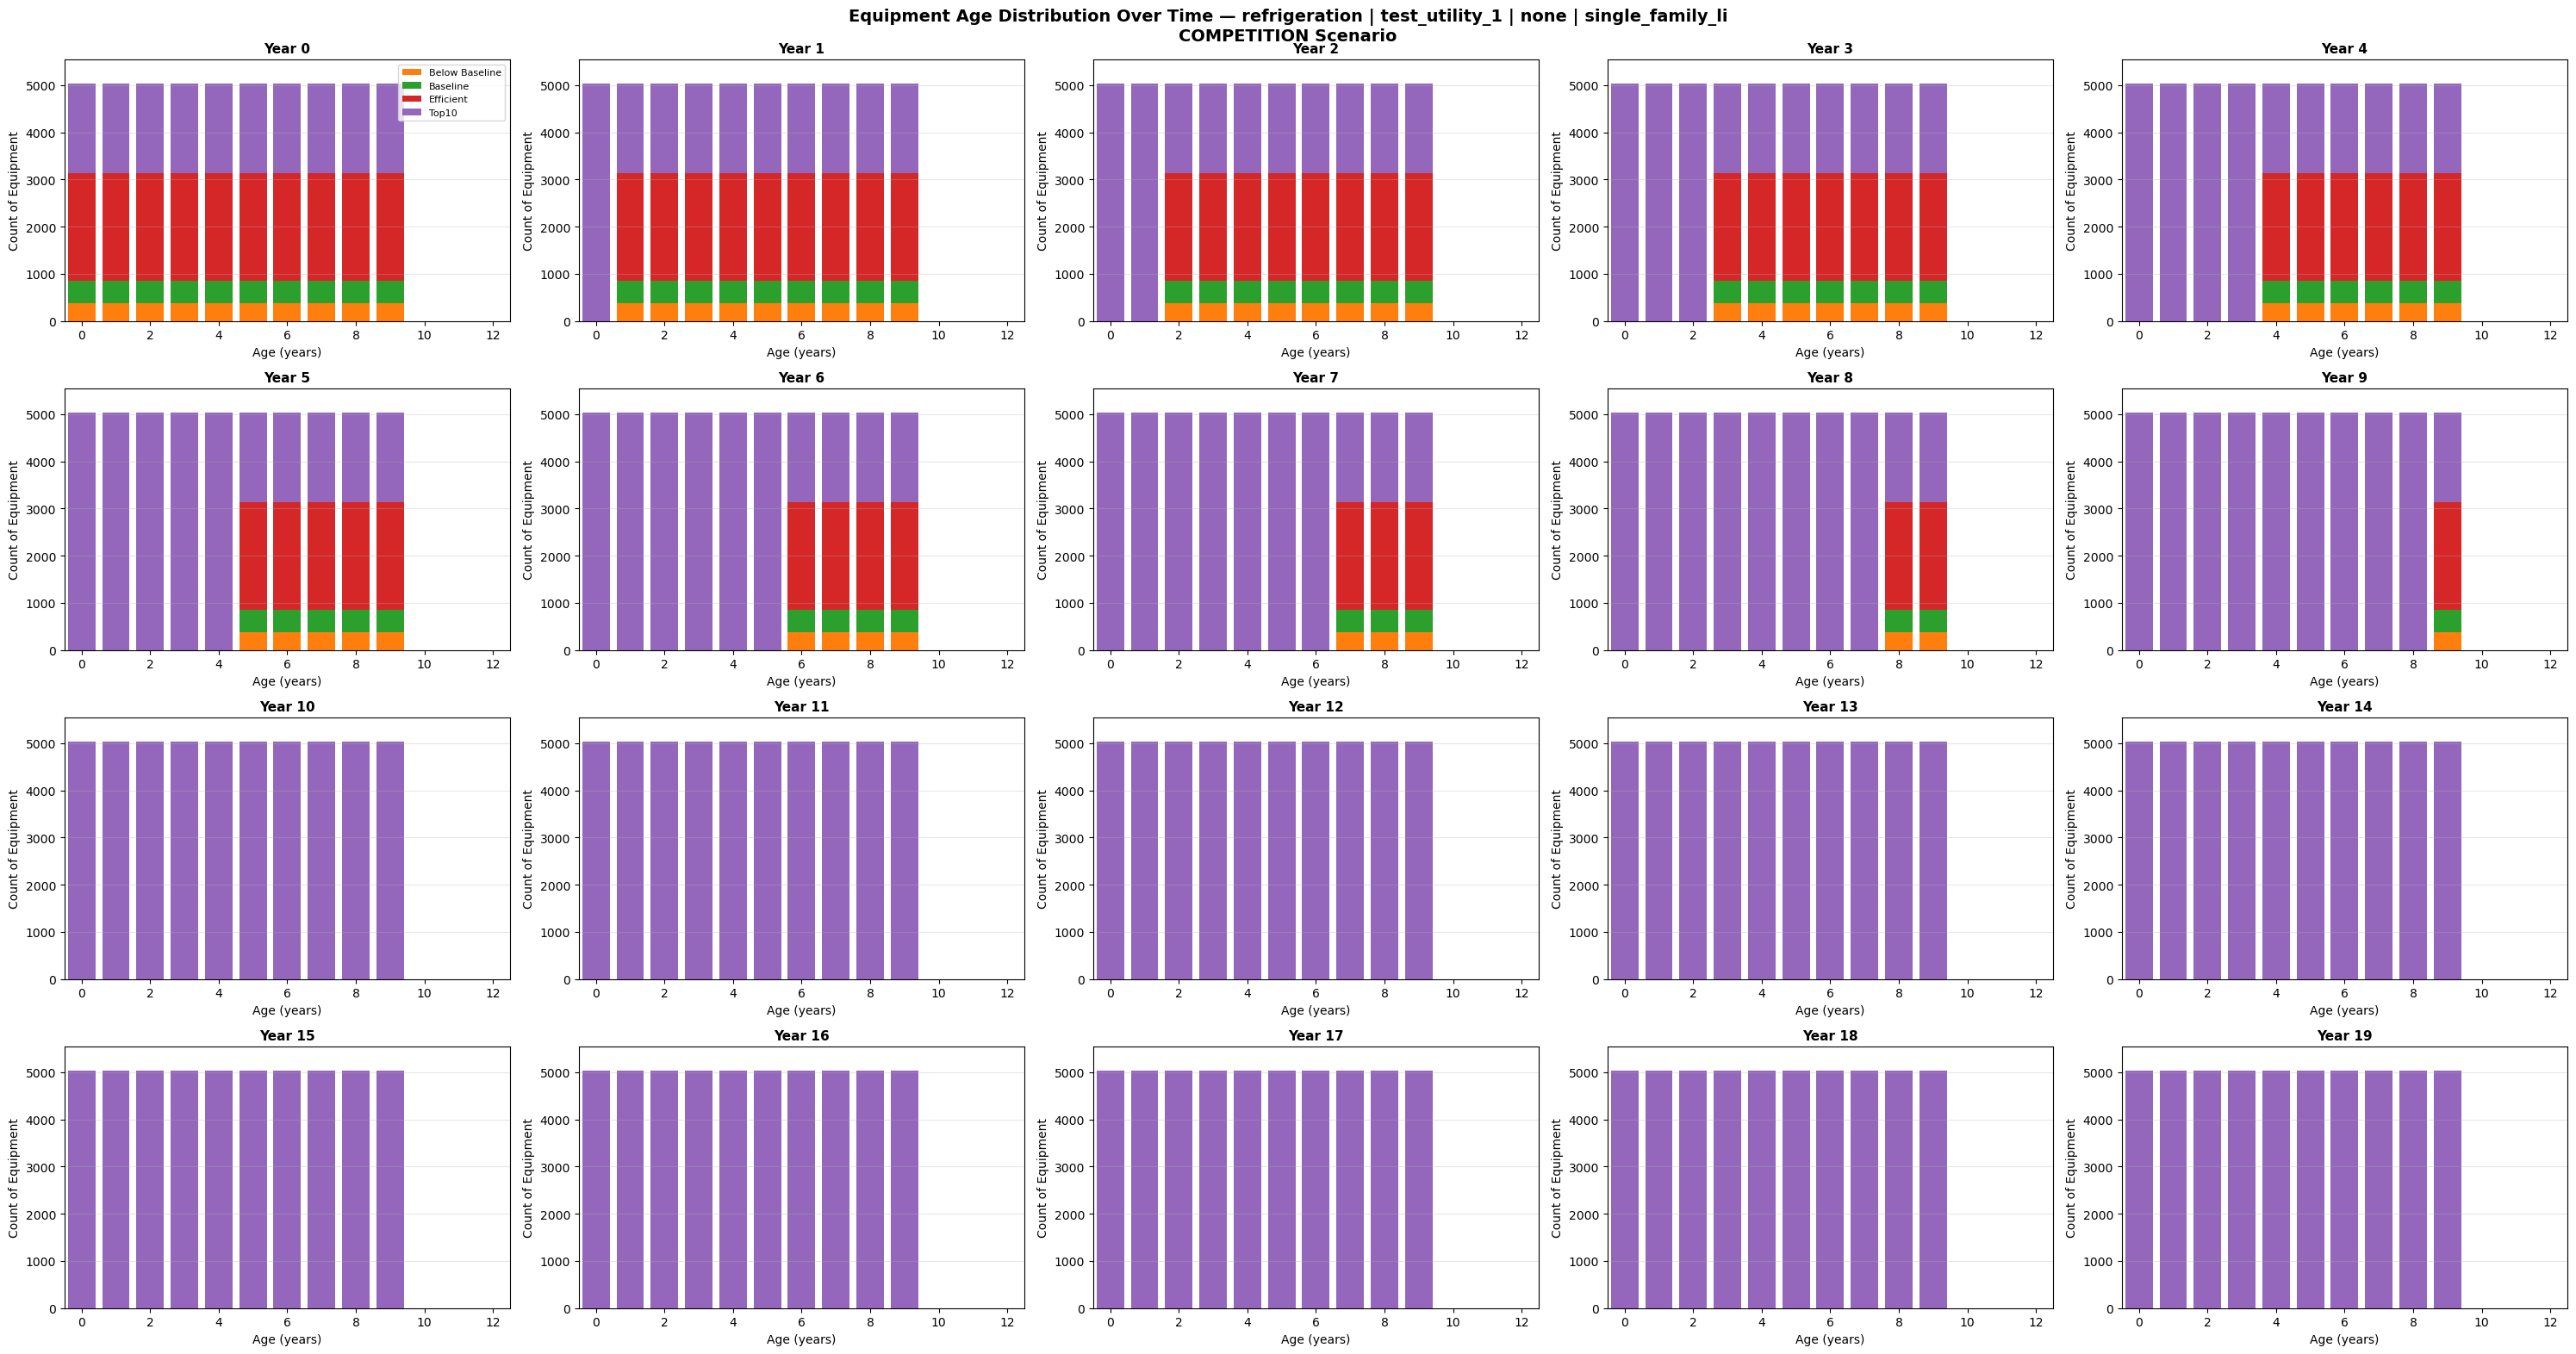

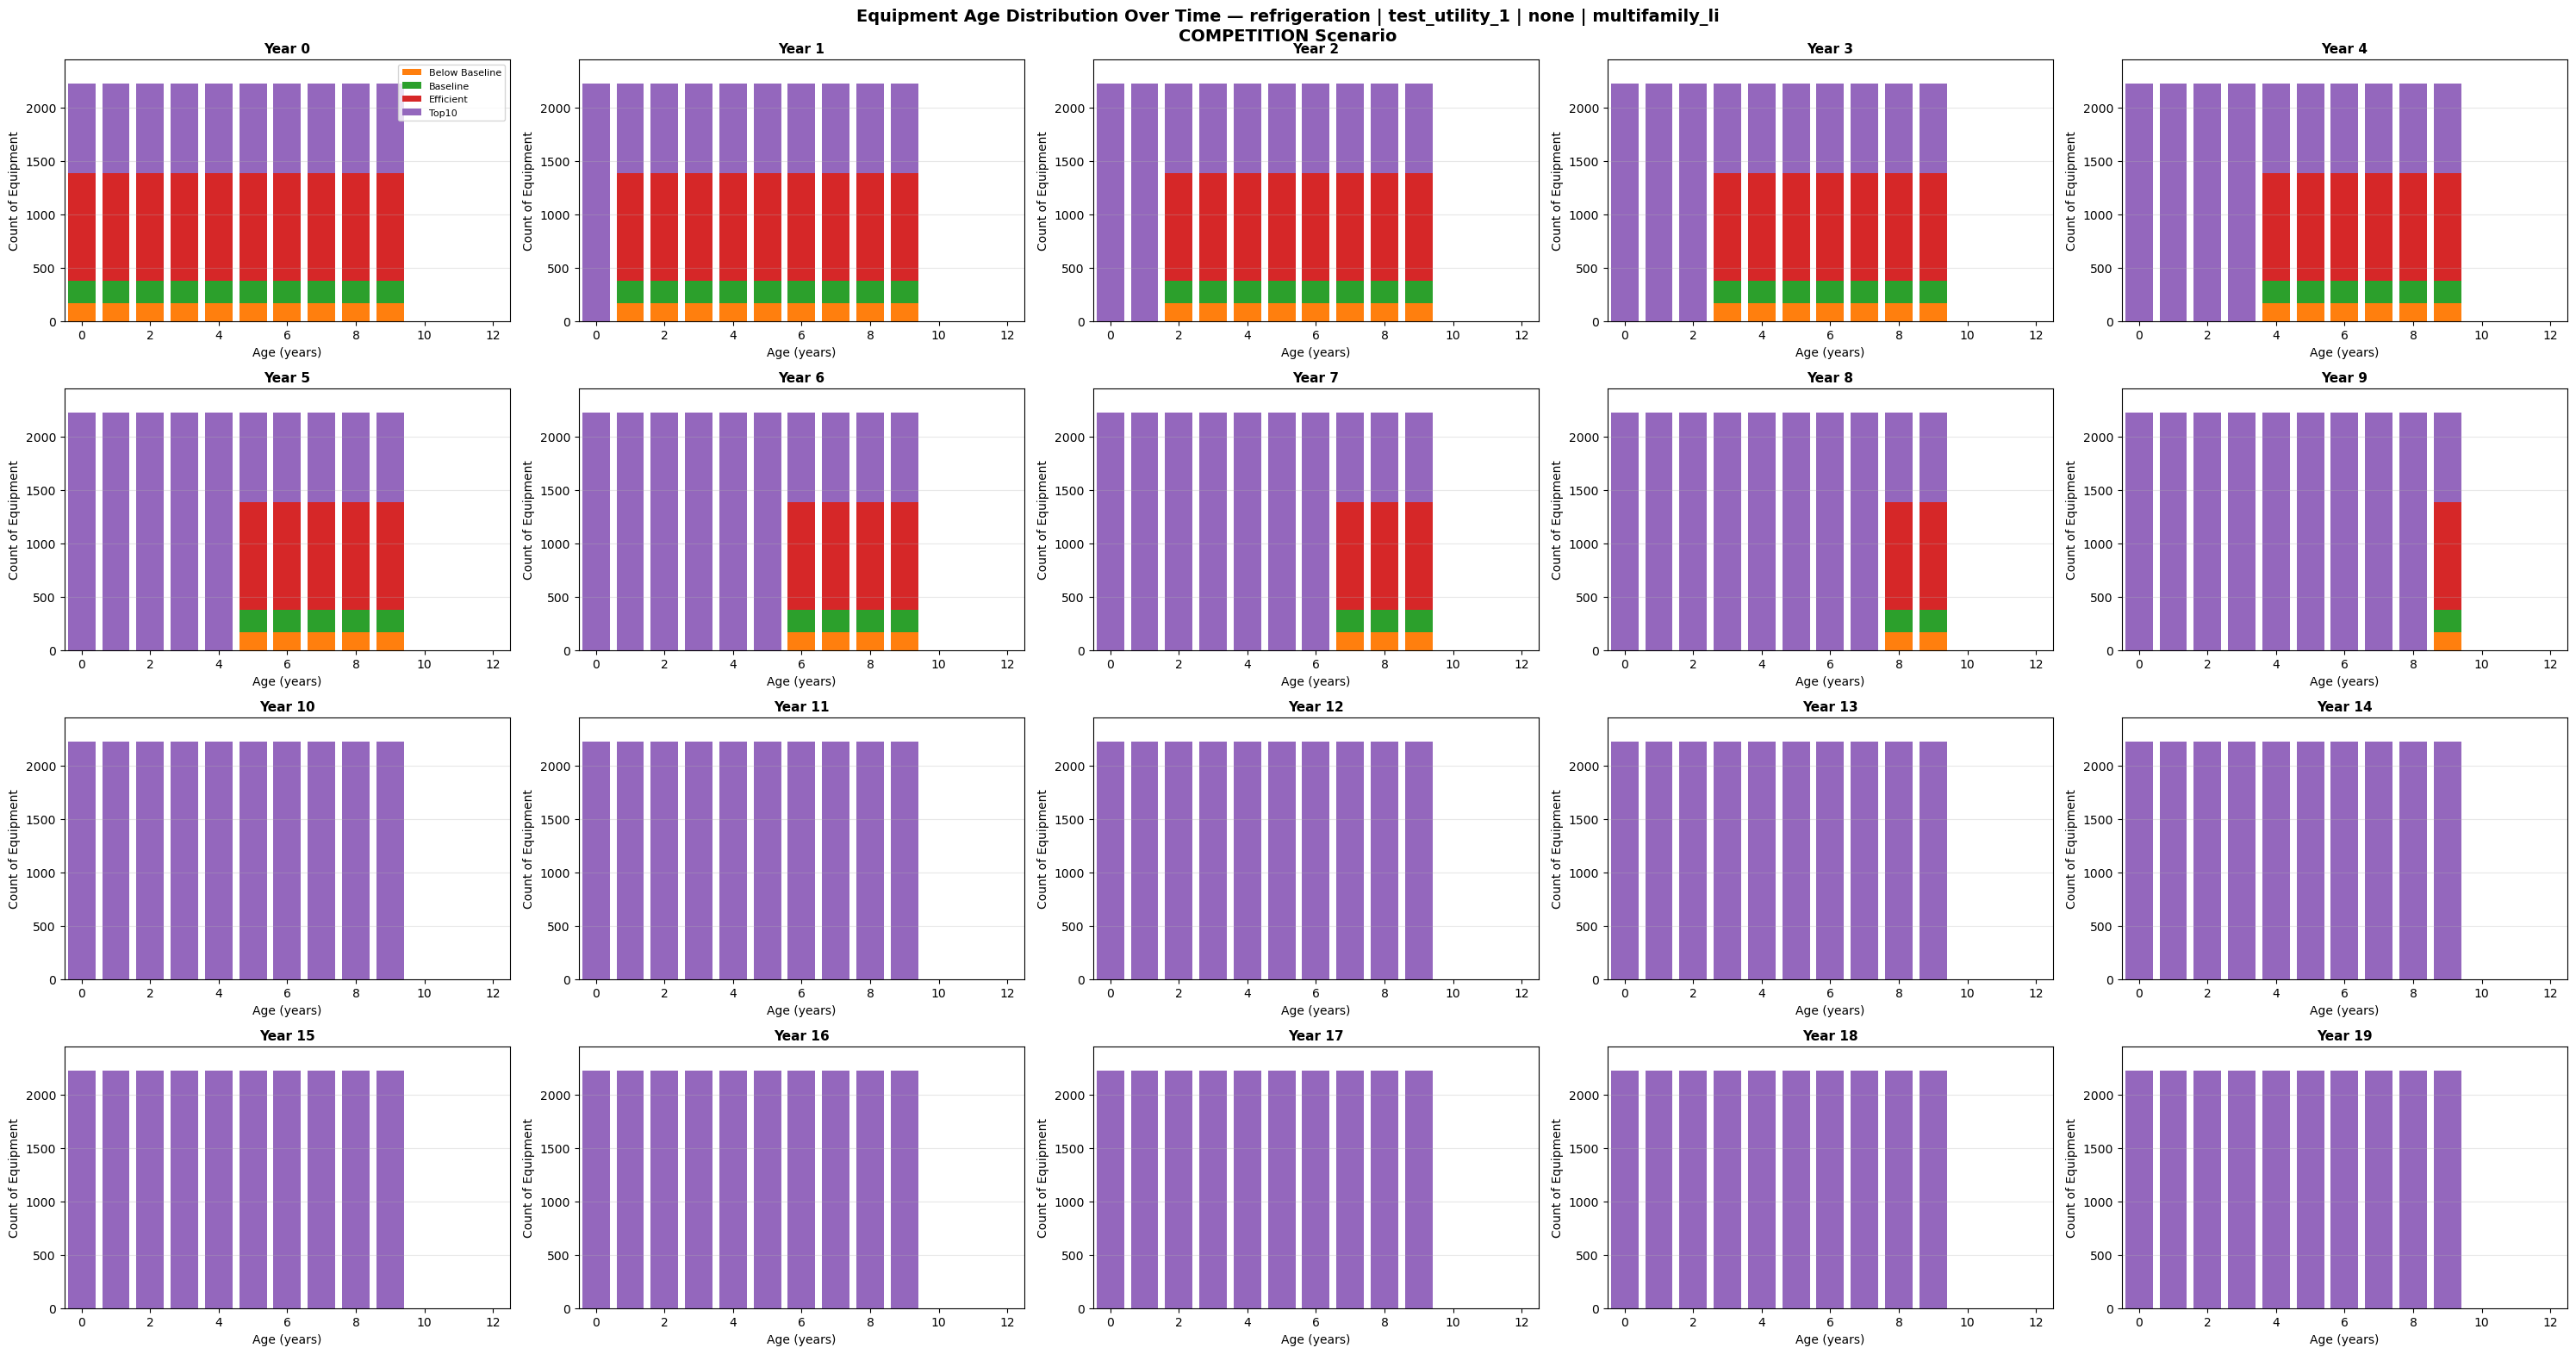

In [397]:
# Age Cohort Visualization by Time
# This function creates visualizations showing equipment distribution by age and efficiency level over time

def plot_age_cohorts_from_stored(scenario_name='tech', max_age_display=30, timesteps_to_plot=None):
    """
    Create stacked bar charts showing equipment age distribution over time using stored data.
    
    Parameters:
    -----------
    scenario_name : str
        Name for the scenario (for titles)
    max_age_display : int
        Maximum age to display on x-axis (default 30)
    timesteps_to_plot : list or None
        List of timesteps (years) to plot. If None, plots all available years (default None)
    """
    
    # Check if age distributions have been stored
    if 'age_distributions_storage' not in globals() or not age_distributions_storage:
        print("Error: No age distributions stored. Run run_adoption_model with store_age_distributions=True first.")
        return
    
    # Iterate through all stored groups
    for group_key, age_distributions in age_distributions_storage.items():
        cg, eu, gu, bt = group_key
        
        # Create visualization
        title_suffix = f"{cg} | {eu} | {gu} | {bt}"
        
        # If no timesteps specified, plot all available years
        if timesteps_to_plot is None:
            timesteps_to_plot = sorted(age_distributions.keys())
        
        num_plots = len(timesteps_to_plot)
        
        # Calculate grid dimensions (prefer roughly square layout)
        ncols = int(np.ceil(np.sqrt(num_plots)))
        nrows = int(np.ceil(num_plots / ncols))
        
        # First pass: calculate y-axis limit based on year 1 (timestep 1)
        max_y_limit = 0
        if 1 in age_distributions:
            year_1_snapshot = age_distributions[1]
            age_data_y1 = {}
            for age in range(max_age_display + 1):
                age_data_y1[age] = {
                    'existing': 0.0,
                    'baseline': 0.0,
                    'efficient': 0.0,
                    'top10': 0.0
                }
            
            for _, row in year_1_snapshot.iterrows():
                age = int(row['current_age'])
                if age <= max_age_display:
                    eff_level = row['efficiency_level']
                    age_data_y1[age][eff_level] += row['count']
            
            # Calculate maximum stacked height for year 1
            for age in range(max_age_display + 1):
                total_at_age = (age_data_y1[age]['existing'] + 
                               age_data_y1[age]['baseline'] + 
                               age_data_y1[age]['efficient'] + 
                               age_data_y1[age]['top10'])
                max_y_limit = max(max_y_limit, total_at_age)
            
            # Add 10% padding to the y-limit
            max_y_limit *= 1.1
        
        # Plot selected timesteps in a grid
        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 4))
        fig.suptitle(f"Equipment Age Distribution Over Time — {title_suffix}\n{scenario_name.upper()} Scenario", 
                     fontsize=14, fontweight='bold')
        
        # Flatten axes array for easier indexing
        if num_plots == 1:
            axes = [axes]
        else:
            axes = axes.flatten()
        
        for plot_idx, year in enumerate(timesteps_to_plot):
            ax = axes[plot_idx]
            snapshot = age_distributions[year]
            
            # Prepare data: group by age and efficiency level
            age_data = {}
            for age in range(max_age_display + 1):
                age_data[age] = {
                    'existing': 0.0,
                    'baseline': 0.0,
                    'efficient': 0.0,
                    'top10': 0.0
                }
            
            for _, row in snapshot.iterrows():
                age = int(row['current_age'])
                if age <= max_age_display:
                    eff_level = row['efficiency_level']
                    age_data[age][eff_level] += row['count']
            
            # Convert to arrays for plotting
            ages = list(range(max_age_display + 1))
            existing_counts = [age_data[age]['existing'] for age in ages]
            baseline_counts = [age_data[age]['baseline'] for age in ages]
            efficient_counts = [age_data[age]['efficient'] for age in ages]
            top10_counts = [age_data[age]['top10'] for age in ages]
            
            # Create stacked bar chart
            bar_width = 0.8
            ax.bar(ages, existing_counts, bar_width, label='Below Baseline', color='tab:orange')
            ax.bar(ages, baseline_counts, bar_width, bottom=existing_counts, label='Baseline', color='tab:green')
            ax.bar(ages, efficient_counts, bar_width, 
                   bottom=[e+b for e, b in zip(existing_counts, baseline_counts)], 
                   label='Efficient', color='tab:red')
            ax.bar(ages, top10_counts, bar_width,
                   bottom=[e+b+ef for e, b, ef in zip(existing_counts, baseline_counts, efficient_counts)],
                   label='Top10', color='tab:purple')
            
            ax.set_xlabel("Age (years)", fontsize=10)
            ax.set_ylabel("Count of Equipment", fontsize=10)
            ax.set_title(f"Year {year}", fontsize=11, fontweight='bold')
            ax.set_xlim(-0.5, max_age_display + 0.5)
            
            # Set consistent y-axis limit based on year 1
            if max_y_limit > 0:
                ax.set_ylim(0, max_y_limit)
            
            if plot_idx == 0:
                ax.legend(loc='upper right', fontsize=8)
            ax.grid(axis='y', alpha=0.3)
        
        # Hide unused subplots
        for idx in range(num_plots, len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()

# Run the age cohort visualization using stored data
# Plot all years with consistent y-axis based on year 1
print("Generating age cohort visualizations from stored data...")
plot_age_cohorts_from_stored('competition', max_age_display=12, timesteps_to_plot=None)

In [398]:
# #Archive
# def run_adoption_model(adoption_function, scenario_name='baseline'):
#     """
#     Run the adoption model with age-based tracking.
    
#     Each equipment type is tracked by its actual age. When it reaches its EUL (measure_life_yrs),
#     it goes through the adoption function to determine what replaces it.
    
#     Parameters:
#     -----------
#     adoption_function : callable
#         The function to use for adoption calculations (e.g., baseline_eq, tech_eq, competition_eq)
#     scenario_name : str
#         Name of the scenario for labeling results (default: 'baseline')
    
#     Returns:
#     --------
#     pd.DataFrame
#         Results dataframe with all stock calculations over time
#     """

#     ############## these need to be parameterized based on what is in the Provided Excel file
#     competition_groups = df['competition_group'].unique().tolist()
#     electric_utility = df['electric_utility'].unique().tolist()
#     gas_utility = df['gas_utility'].unique().tolist()
#     building_type = df['building_type'].unique().tolist()
#     #subgroup = df['subgroup'].unique().tolist()  # Uncomment if subgroup is needed

#     results = []

#     for cg in competition_groups:
#         #for sg in subgroup:
#             for eu in electric_utility:
#                 for gu in gas_utility:
#                     for bt in building_type:
#                         # Get dynamic nc, demo, and reno values based on competition group and building type
#                         nc_per_year = get_construction_value(new_construction_inputs_df, cg, bt)
#                         demo_per_year = get_construction_value(demolition_inputs_df, cg, bt)
#                         reno_per_year = get_construction_value(renovation_inputs_df, cg, bt)
                        
#                         # Calculate per-timestep values
#                         nc = nc_per_year * dt
#                         demo = demo_per_year * dt
#                         reno = reno_per_year * dt
                        
#                         df_filtered = df[
#                             (df['competition_group'] == cg) &
#                             #df['subgroup'] == sg) &
#                             (df['electric_utility'] == eu) &
#                             (df['gas_utility'] == gu) &
#                             (df['building_type'] == bt)
#                         ]
                        
#                         if df_filtered.empty:
#                             continue
                        
#                         # --- AGE-BASED TRACKING INITIALIZATION ---
#                         # Create age cohorts for each condition (measure)
#                         # Each row in df_filtered represents a unique measure/condition
#                         # We split the initial count evenly across all years of its EUL
                        
#                         age_cohorts = []
                        
#                         for idx, row in df_filtered.iterrows():
#                             measure_eul = int(row['measure_life_(yrs)'])
#                             initial_count = row['count']
#                             efficiency_level = row['efficiency_level']
#                             condition_name = row['condition_name']
                            
#                             ######## Change here if want different split ############
#                             # Split initial count evenly across all age years (0 to EUL-1)
#                             count_per_age_year = initial_count / measure_eul
                            
#                             # Create a cohort for each age
#                             for age in range(measure_eul):
#                                 age_cohorts.append({
#                                     'condition_name': condition_name,
#                                     'efficiency_level': efficiency_level,
#                                     'eul': measure_eul,
#                                     'current_age': age,
#                                     'count': count_per_age_year,
#                                     'idx_in_df': idx  # Track original row for BCR lookup
#                                 })
                        
#                         # Convert to DataFrame for easier manipulation
#                         age_df = pd.DataFrame(age_cohorts)
                        
#                         # Initialize tracking arrays for aggregated results
#                         total_stock = np.zeros(n)
#                         total_below_baseline_stock = np.zeros(n)
#                         total_baseline_stock = np.zeros(n)
#                         total_efficient_stock = np.zeros(n)
#                         total_top10_stock = np.zeros(n)
                        
#                         # Track flows (adoptions at EUL)
#                         adoption_flow_below_baseline = np.zeros(n)
#                         adoption_flow_baseline = np.zeros(n)
#                         adoption_flow_efficient = np.zeros(n)
#                         adoption_flow_top10 = np.zeros(n)
                        
#                         # Set initial conditions for t=0
#                         total_below_baseline_stock[0] = age_df[age_df['efficiency_level'] == 'existing']['count'].sum()
#                         total_baseline_stock[0] = age_df[age_df['efficiency_level'] == 'baseline']['count'].sum()
#                         total_efficient_stock[0] = age_df[age_df['efficiency_level'] == 'efficient']['count'].sum()
#                         total_top10_stock[0] = age_df[age_df['efficiency_level'] == 'top10']['count'].sum()
#                         total_stock[0] = total_below_baseline_stock[0] + total_baseline_stock[0] + total_efficient_stock[0] + total_top10_stock[0]
                        
#                         # --- TIME LOOP: AGE-BASED EVOLUTION ---
#                         for t in range(1, n):
#                             # Step 1: Age all existing cohorts by dt (1 year)
#                             age_df['current_age'] = age_df['current_age'] + dt
                            
#                             # Step 2: Identify cohorts that have reached or exceeded their EUL
#                             retired_cohorts = age_df[age_df['current_age'] >= age_df['eul']].copy()
#                             active_cohorts = age_df[age_df['current_age'] < age_df['eul']].copy()
                            
#                             # Step 3: Apply adoption function to retired cohorts
#                             # Group retired cohorts by efficiency level to calculate total retiring stock
#                             retiring_below_baseline = retired_cohorts[retired_cohorts['efficiency_level'] == 'existing']['count'].sum()
#                             retiring_baseline = retired_cohorts[retired_cohorts['efficiency_level'] == 'baseline']['count'].sum()
#                             retiring_efficient = retired_cohorts[retired_cohorts['efficiency_level'] == 'efficient']['count'].sum()
#                             retiring_top10 = retired_cohorts[retired_cohorts['efficiency_level'] == 'top10']['count'].sum()
#                             total_retiring = retiring_below_baseline + retiring_baseline + retiring_efficient + retiring_top10
                            
#                             # Apply adoption function to determine replacement distribution
#                             if total_retiring > 0:
#                                 # Note: Using retirement_rate = 1.0 since equipment at EUL fully retires
#                                 dBB, dB, dE, dT = adoption_function(
#                                     retiring_below_baseline,
#                                     retiring_baseline,
#                                     retiring_efficient,
#                                     retiring_top10,
#                                     total_retiring,
#                                     1.0,  # Full retirement at EUL
#                                     df_filtered
#                                 )
                                
#                                 # Calculate new equipment distribution after adoption
#                                 # The adoption function returns rates of change, so we integrate over dt
#                                 new_below_baseline = max(retiring_below_baseline + dBB * dt, 0.0)
#                                 new_baseline = max(retiring_baseline + dB * dt, 0.0)
#                                 new_efficient = max(retiring_efficient + dE * dt, 0.0)
#                                 new_top10 = max(retiring_top10 + dT * dt, 0.0)
                                
#                                 # Track adoption flows
#                                 adoption_flow_below_baseline[t] = new_below_baseline
#                                 adoption_flow_baseline[t] = new_baseline
#                                 adoption_flow_efficient[t] = new_efficient
#                                 adoption_flow_top10[t] = new_top10
                                
#                                 # Create new cohorts for each efficiency level with age = 0
#                                 new_cohorts = []
                                
#                                 # For each efficiency level, create new cohorts based on df_filtered measures
#                                 for eff_level, new_count in [('existing', new_below_baseline), 
#                                                                ('baseline', new_baseline), 
#                                                                ('efficient', new_efficient), 
#                                                                ('top10', new_top10)]:
#                                     if new_count > 0:
#                                         # Get measures of this efficiency level from df_filtered
#                                         eff_measures = df_filtered[df_filtered['efficiency_level'] == eff_level]
#                                         if not eff_measures.empty:
#                                             # Distribute new count proportionally to existing measures
#                                             # (or evenly if no proportional data available)
#                                             num_measures = len(eff_measures)
#                                             count_per_measure = new_count / num_measures
                                            
#                                             for idx, row in eff_measures.iterrows():
#                                                 new_cohorts.append({
#                                                     'condition_name': row['condition_name'],
#                                                     'efficiency_level': eff_level,
#                                                     'eul': int(row['measure_life_(yrs)']),
#                                                     'current_age': 0,
#                                                     'count': count_per_measure,
#                                                     'idx_in_df': idx
#                                                 })
                                
#                                 # Add new cohorts to active cohorts
#                                 if new_cohorts:
#                                     new_cohorts_df = pd.DataFrame(new_cohorts)
#                                     active_cohorts = pd.concat([active_cohorts, new_cohorts_df], ignore_index=True)
                            
#                             # Step 4: Handle new construction, demolition, and renovation
#                             if nc > 0:
#                                 # Distribute new construction across efficiency levels
#                                 # Assume 1/3 baseline, 1/3 efficient, 1/3 top10 for new construction
#                                 nc_cohorts = []
#                                 for eff_level, proportion in [('baseline', 1/3), ('efficient', 1/3), ('top10', 1/3)]:
#                                     eff_measures = df_filtered[df_filtered['efficiency_level'] == eff_level]
#                                     if not eff_measures.empty:
#                                         num_measures = len(eff_measures)
#                                         count_per_measure = (nc * proportion) / num_measures
#                                         for idx, row in eff_measures.iterrows():
#                                             nc_cohorts.append({
#                                                 'condition_name': row['condition_name'],
#                                                 'efficiency_level': eff_level,
#                                                 'eul': int(row['measure_life_(yrs)']),
#                                                 'current_age': 0,
#                                                 'count': count_per_measure,
#                                                 'idx_in_df': idx
#                                             })
#                                 if nc_cohorts:
#                                     nc_df = pd.DataFrame(nc_cohorts)
#                                     active_cohorts = pd.concat([active_cohorts, nc_df], ignore_index=True)
                            
#                             # Handle demolition (remove proportionally from all cohorts)
#                             if demo > 0 and not active_cohorts.empty:
#                                 total_active = active_cohorts['count'].sum()
#                                 if total_active > 0:
#                                     demo_fraction = min(demo / total_active, 1.0)
#                                     active_cohorts['count'] = active_cohorts['count'] * (1 - demo_fraction)
                            
#                             # Handle renovation (upgrade equipment to top10, reset age)
#                             if reno > 0 and not active_cohorts.empty:
#                                 total_active = active_cohorts['count'].sum()
#                                 if total_active > 0:
#                                     reno_fraction = min(reno / total_active, 1.0)
#                                     # Remove reno_fraction from all cohorts and add to top10
#                                     reno_count = active_cohorts['count'].sum() * reno_fraction
#                                     active_cohorts['count'] = active_cohorts['count'] * (1 - reno_fraction)
                                    
#                                     # Add renovated equipment as new top10 cohorts
#                                     top10_measures = df_filtered[df_filtered['efficiency_level'] == 'top10']
#                                     if not top10_measures.empty:
#                                         num_measures = len(top10_measures)
#                                         count_per_measure = reno_count / num_measures
#                                         reno_cohorts = []
#                                         for idx, row in top10_measures.iterrows():
#                                             reno_cohorts.append({
#                                                 'condition_name': row['condition_name'],
#                                                 'efficiency_level': 'top10',
#                                                 'eul': int(row['measure_life_(yrs)']),
#                                                 'current_age': 0,
#                                                 'count': count_per_measure,
#                                                 'idx_in_df': idx
#                                             })
#                                         if reno_cohorts:
#                                             reno_df = pd.DataFrame(reno_cohorts)
#                                             active_cohorts = pd.concat([active_cohorts, reno_df], ignore_index=True)
                            
#                             # Step 5: Update age_df for next iteration
#                             age_df = active_cohorts.copy()
                            
#                             # Step 6: Calculate aggregate stocks for this timestep
#                             total_below_baseline_stock[t] = age_df[age_df['efficiency_level'] == 'existing']['count'].sum()
#                             total_baseline_stock[t] = age_df[age_df['efficiency_level'] == 'baseline']['count'].sum()
#                             total_efficient_stock[t] = age_df[age_df['efficiency_level'] == 'efficient']['count'].sum()
#                             total_top10_stock[t] = age_df[age_df['efficiency_level'] == 'top10']['count'].sum()
#                             total_stock[t] = total_below_baseline_stock[t] + total_baseline_stock[t] + total_efficient_stock[t] + total_top10_stock[t]
                        
#                         # Append results for each time step
#                         for t in range(n):
#                             results.append({
#                                 'competition_group': cg,
#                                 #'subgroup': sg,
#                                 'electric_utility': eu,
#                                 'gas_utility': gu,
#                                 'building_type': bt,
#                                 'time': t * dt,
#                                 'total_stock': total_stock[t],
#                                 'total_below_baseline_stock': total_below_baseline_stock[t],
#                                 'total_baseline_stock': total_baseline_stock[t],
#                                 'total_efficient_stock': total_efficient_stock[t],
#                                 'total_top10_stock': total_top10_stock[t],
#                                 'adoption_flow_below_baseline': adoption_flow_below_baseline[t],
#                                 'adoption_flow_baseline': adoption_flow_baseline[t],
#                                 'adoption_flow_efficient': adoption_flow_efficient[t],
#                                 'adoption_flow_top10': adoption_flow_top10[t]
#                             })

#     return pd.DataFrame(results)